# Notebook - Find best Drug compound for `Lassa` virus

In this notebook, we demonstrate the use of MACAW embeddings to model binding affinity to a protein receptor of pharmacological interest. MACAW embeddings are then applied to identify promising candidate molecules in a custom virtual library.

In [1]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

[16:30:59] DEPRECATION WARNING: please use AtomPairGenerator
[16:30:59] DEPRECATION WARNING: please use AtomPairGenerator
[16:30:59] DEPRECATION WARNING: please use AtomPairGenerator
[16:30:59] DEPRECATION WARNING: please use AtomPairGenerator
[16:30:59] DEPRECATION WARNING: please use AtomPairGenerator
[16:30:59] DEPRECATION WARNING: please use AtomPairGenerator
[16:30:59] DEPRECATION WARNING: please use AtomPairGenerator
[16:30:59] DEPRECATION WARNING: please use AtomPairGenerator
[16:30:59] DEPRECATION WARNING: please use AtomPairGenerator
[16:30:59] DEPRECATION WARNING: please use AtomPairGenerator
[16:30:59] DEPRECATION WARNING: please use AtomPairGenerator
[16:30:59] DEPRECATION WARNING: please use AtomPairGenerator
[16:30:59] DEPRECATION WARNING: please use AtomPairGenerator
[16:30:59] DEPRECATION WARNING: please use AtomPairGenerator
[16:30:59] DEPRECATION WARNING: please use AtomPairGenerator
[16:30:59] DEPRECATION WARNING: please use AtomPairGenerator
[16:30:59] DEPRECATION W

In [2]:
import os
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score

#Needed to show molecules
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole 
import seaborn as sns
from copy import deepcopy
import pickle

import sys
sys.path.append('../')

import macaw
print(macaw.__version__)
from macaw import *

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['figure.dpi'] = 96
matplotlib.rcParams['savefig.dpi'] = 600

%run "./plotting.py"

1.0.1


In [3]:
%config InlineBackend.figure_format = 'retina'

## 1. Regression Target: pPotency

### 1.1 Data preparation

In [4]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
resultsDir = os.path.join(dataDir, 'Results/')
saveDir = os.path.join(resultsDir, "Lassa_bestMACAW/")
os.makedirs(saveDir, exist_ok=True)

In [5]:
allVirusData_chEMBL_wMACAW = pd.read_csv(modelBuildingDataDir + 'allVirusData_chEMBL_uM_wMACAW.csv')

### Filter columns and keeping only data for Lassa virus

In [6]:
allVirusData_chEMBL_wMACAW =  allVirusData_chEMBL_wMACAW.filter(
    items=["molecule_chembl_id", "smiles", "value_uM", "pPotency", "Virus"]
)
LassaVirusData_chEMBL = allVirusData_chEMBL_wMACAW[allVirusData_chEMBL_wMACAW['Virus'] == 'Lassa']
LassaVirusData_chEMBL

,molecule_chembl_id,smiles,value_uM,pPotency,Virus
13799,CHEMBL2314868,CCOc1ccc(Cn2cnc3cc(NCc4ccc(CC)cc4)cnc32)cc1,1.60000,5.795880,Lassa
13800,CHEMBL2315151,CCOc1ccc(-n2cnc3cc(NCc4ccc(CC)cc4)cnc32)nc1,0.00098,9.008774,Lassa
13801,CHEMBL2315139,CCOc1ccc(-n2ccc3cc(NCc4ccc(CC)cc4)ccc32)cc1,0.06900,7.161151,Lassa
13802,CHEMBL2314867,CCOc1ccc(-n2cnc3cc(/N=C/c4ccc(CC)cc4)cnc32)cc1,4.30000,5.366532,Lassa
13803,CHEMBL2322815,COc1ccc(-n2cnc3cc(NCc4ccccc4OC)ccc32)cc1,0.46000,6.337242,Lassa
...,...,...,...,...,...
14011,CHEMBL4871373,Cc1cc2ncn(-c3ccc(OC(C)C)cc3)c2cc1-c1ccc(OC(C)C...,0.00330,NaN,Lassa
14012,CHEMBL4862268,CC(C)Oc1ccc(-c2cnc3ccc(-c4ccc(F)cc4)cn23)cc1,0.02500,NaN,Lassa
14013,CHEMBL4864023,CC(C)Oc1ccc(-c2cnc3ccc(-c4ccc(C5(N)CC5)cc4)cn2...,0.00797,8.098542,Lassa
14014,CHEMBL4851799,Cc1c(-c2ccc(OC(C)C)cc2)ccc2ncc(-c3ccc(OC(C)C)c...,0.00032,9.494850,Lassa


### Remove `Remdesivir` from training set

In [7]:
Remdesivir_SMILES = 'CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1'

# Canonicalize the Remdesivir SMILES
remMol = Chem.MolFromSmiles(Remdesivir_SMILES)
remCan = Chem.MolToSmiles(remMol, canonical=True)

# Canonicalize all SMILES in your dataframe
LassaVirusData_chEMBL["canonical_smiles"] = (
    LassaVirusData_chEMBL["smiles"]
    .apply(lambda s: Chem.MolToSmiles(Chem.MolFromSmiles(s), canonical=True)
          if Chem.MolFromSmiles(s) else None)
)

# Remove rows matching Remdesivir
mask = LassaVirusData_chEMBL["canonical_smiles"] != remCan
LassaVirusData_chEMBL_clean = LassaVirusData_chEMBL[mask].copy()

print("Original shape of data frame:", len(LassaVirusData_chEMBL))
print("After removing Remdesivir:", len(LassaVirusData_chEMBL_clean))
LassaVirusData_chEMBL = LassaVirusData_chEMBL_clean.copy()

Original shape of data frame: 217
After removing Remdesivir: 215


### Rename columns

In [8]:
LassaVirusData_chEMBL = LassaVirusData_chEMBL.rename(columns={
    "molecule_chembl_id": "compound_id",
    "smiles": "Smiles",
    "Virus" : "VirusClassifier",
})

### Compound Distribution Across Viruses

In [9]:
virus_counts = LassaVirusData_chEMBL['VirusClassifier'].value_counts().sort_values(ascending=False)
total_compounds = len(LassaVirusData_chEMBL)

print(f"\n{'Virus':<30} {'Count':>10} {'Percentage':>12}")
print("-"*70)

for virus, count in virus_counts.items():
    percentage = (count / total_compounds) * 100
    print(f"{virus:<30} {count:>10} {percentage:>11.2f}%")

print("-"*70)
print(f"{'TOTAL':<30} {total_compounds:>10} {100.0:>11.2f}%")
print(f"\nNumber of unique viruses: {len(virus_counts)}")


Virus                               Count   Percentage
----------------------------------------------------------------------
Lassa                                 215      100.00%
----------------------------------------------------------------------
TOTAL                                 215      100.00%

Number of unique viruses: 1


### Add `ID` column to left

In [10]:
LassaVirusData_chEMBL.insert(0, 'ID', range(1, len(LassaVirusData_chEMBL) + 1))
LassaVirusData_chEMBL.head()

,ID,compound_id,Smiles,value_uM,pPotency,VirusClassifier,canonical_smiles
13799,1,CHEMBL2314868,CCOc1ccc(Cn2cnc3cc(NCc4ccc(CC)cc4)cnc32)cc1,1.60000,5.795880,Lassa,CCOc1ccc(Cn2cnc3cc(NCc4ccc(CC)cc4)cnc32)cc1
13800,2,CHEMBL2315151,CCOc1ccc(-n2cnc3cc(NCc4ccc(CC)cc4)cnc32)nc1,0.00098,9.008774,Lassa,CCOc1ccc(-n2cnc3cc(NCc4ccc(CC)cc4)cnc32)nc1
13801,3,CHEMBL2315139,CCOc1ccc(-n2ccc3cc(NCc4ccc(CC)cc4)ccc32)cc1,0.06900,7.161151,Lassa,CCOc1ccc(-n2ccc3cc(NCc4ccc(CC)cc4)ccc32)cc1
13802,4,CHEMBL2314867,CCOc1ccc(-n2cnc3cc(/N=C/c4ccc(CC)cc4)cnc32)cc1,4.30000,5.366532,Lassa,CCOc1ccc(-n2cnc3cc(/N=C/c4ccc(CC)cc4)cnc32)cc1
13803,5,CHEMBL2322815,COc1ccc(-n2cnc3cc(NCc4ccccc4OC)ccc32)cc1,0.46000,6.337242,Lassa,COc1ccc(-n2cnc3cc(NCc4ccccc4OC)ccc32)cc1


### Add another filer to keep only these four columns: `ID`, `compound_id`,	`Smiles`, `pPotency`, `VirusClassifier`

In [11]:
LassaVirusData_chEMBL = LassaVirusData_chEMBL.filter(
    items=["ID", "compound_id", "Smiles", "pPotency", "VirusClassifier"]
)
LassaVirusData_chEMBL.head()

,ID,compound_id,Smiles,pPotency,VirusClassifier
13799,1,CHEMBL2314868,CCOc1ccc(Cn2cnc3cc(NCc4ccc(CC)cc4)cnc32)cc1,5.795880,Lassa
13800,2,CHEMBL2315151,CCOc1ccc(-n2cnc3cc(NCc4ccc(CC)cc4)cnc32)nc1,9.008774,Lassa
13801,3,CHEMBL2315139,CCOc1ccc(-n2ccc3cc(NCc4ccc(CC)cc4)ccc32)cc1,7.161151,Lassa
13802,4,CHEMBL2314867,CCOc1ccc(-n2cnc3cc(/N=C/c4ccc(CC)cc4)cnc32)cc1,5.366532,Lassa
13803,5,CHEMBL2322815,COc1ccc(-n2cnc3cc(NCc4ccccc4OC)ccc32)cc1,6.337242,Lassa


### Remove NaN, -ve and unphysical (>12) values in `pPotency` before cross-validation

| Range (pPotency) | IC₅₀/EC₅₀ (in M)          | Interpretation                                | Action              |
| ---------------- | -------------------- | --------------------------------------------- | ------------------- |
| **0–3**   | > 1×10⁻³ M (millimolar)     | Very weak or inactive compounds               | Drop         |
| **3–10**  | 1×10⁻³ – 1×10⁻¹⁰ M          | Normal drug-like activity range               | **Keep**                |
| **10–12** | 1×10⁻¹⁰ – 1×10⁻¹² M         | Extremely potent but still physically possible | **Keep (with caution)** |
| **>12**   | < 1×10⁻¹² M (picomolar–femto) | Physically unrealistic / likely data error     | Drop                |



In [199]:
print("Original shape:", LassaVirusData_chEMBL.shape)

LassaVirusData_chEMBL = LassaVirusData_chEMBL[LassaVirusData_chEMBL['pPotency'].notna() 
    & (LassaVirusData_chEMBL['pPotency'] > 0) ]   # & (LassaVirusData_chEMBL['pPotency'] < 12)

print("Shape after cleaning 'pPotency' value:", LassaVirusData_chEMBL.shape)

Original shape: (215, 5)
Shape after cleaning 'pPotency' value: (189, 5)


In [200]:
LassaVirusData_chEMBL

,ID,compound_id,Smiles,pPotency,VirusClassifier
13799,1,CHEMBL2314868,CCOc1ccc(Cn2cnc3cc(NCc4ccc(CC)cc4)cnc32)cc1,5.795880,Lassa
13800,2,CHEMBL2315151,CCOc1ccc(-n2cnc3cc(NCc4ccc(CC)cc4)cnc32)nc1,9.008774,Lassa
13801,3,CHEMBL2315139,CCOc1ccc(-n2ccc3cc(NCc4ccc(CC)cc4)ccc32)cc1,7.161151,Lassa
13802,4,CHEMBL2314867,CCOc1ccc(-n2cnc3cc(/N=C/c4ccc(CC)cc4)cnc32)cc1,5.366532,Lassa
13803,5,CHEMBL2322815,COc1ccc(-n2cnc3cc(NCc4ccccc4OC)ccc32)cc1,6.337242,Lassa
...,...,...,...,...,...
14008,208,CHEMBL4860136,CC(C)Oc1ccc(-c2ccc3ncn(-c4ccc(OC(C)C)cc4)c3c2)cc1,9.086186,Lassa
14009,209,CHEMBL4854274,Cc1cc2nnn(-c3ccc(OC(C)C)cc3)c2cc1-c1ccc(OC(C)C...,8.978811,Lassa
14013,213,CHEMBL4864023,CC(C)Oc1ccc(-c2cnc3ccc(-c4ccc(C5(N)CC5)cc4)cn2...,8.098542,Lassa
14014,214,CHEMBL4851799,Cc1c(-c2ccc(OC(C)C)cc2)ccc2ncc(-c3ccc(OC(C)C)c...,9.494850,Lassa


### Check duplicate SMILES

In [201]:
duplicates = LassaVirusData_chEMBL.duplicated(subset=['Smiles', 'VirusClassifier'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 6


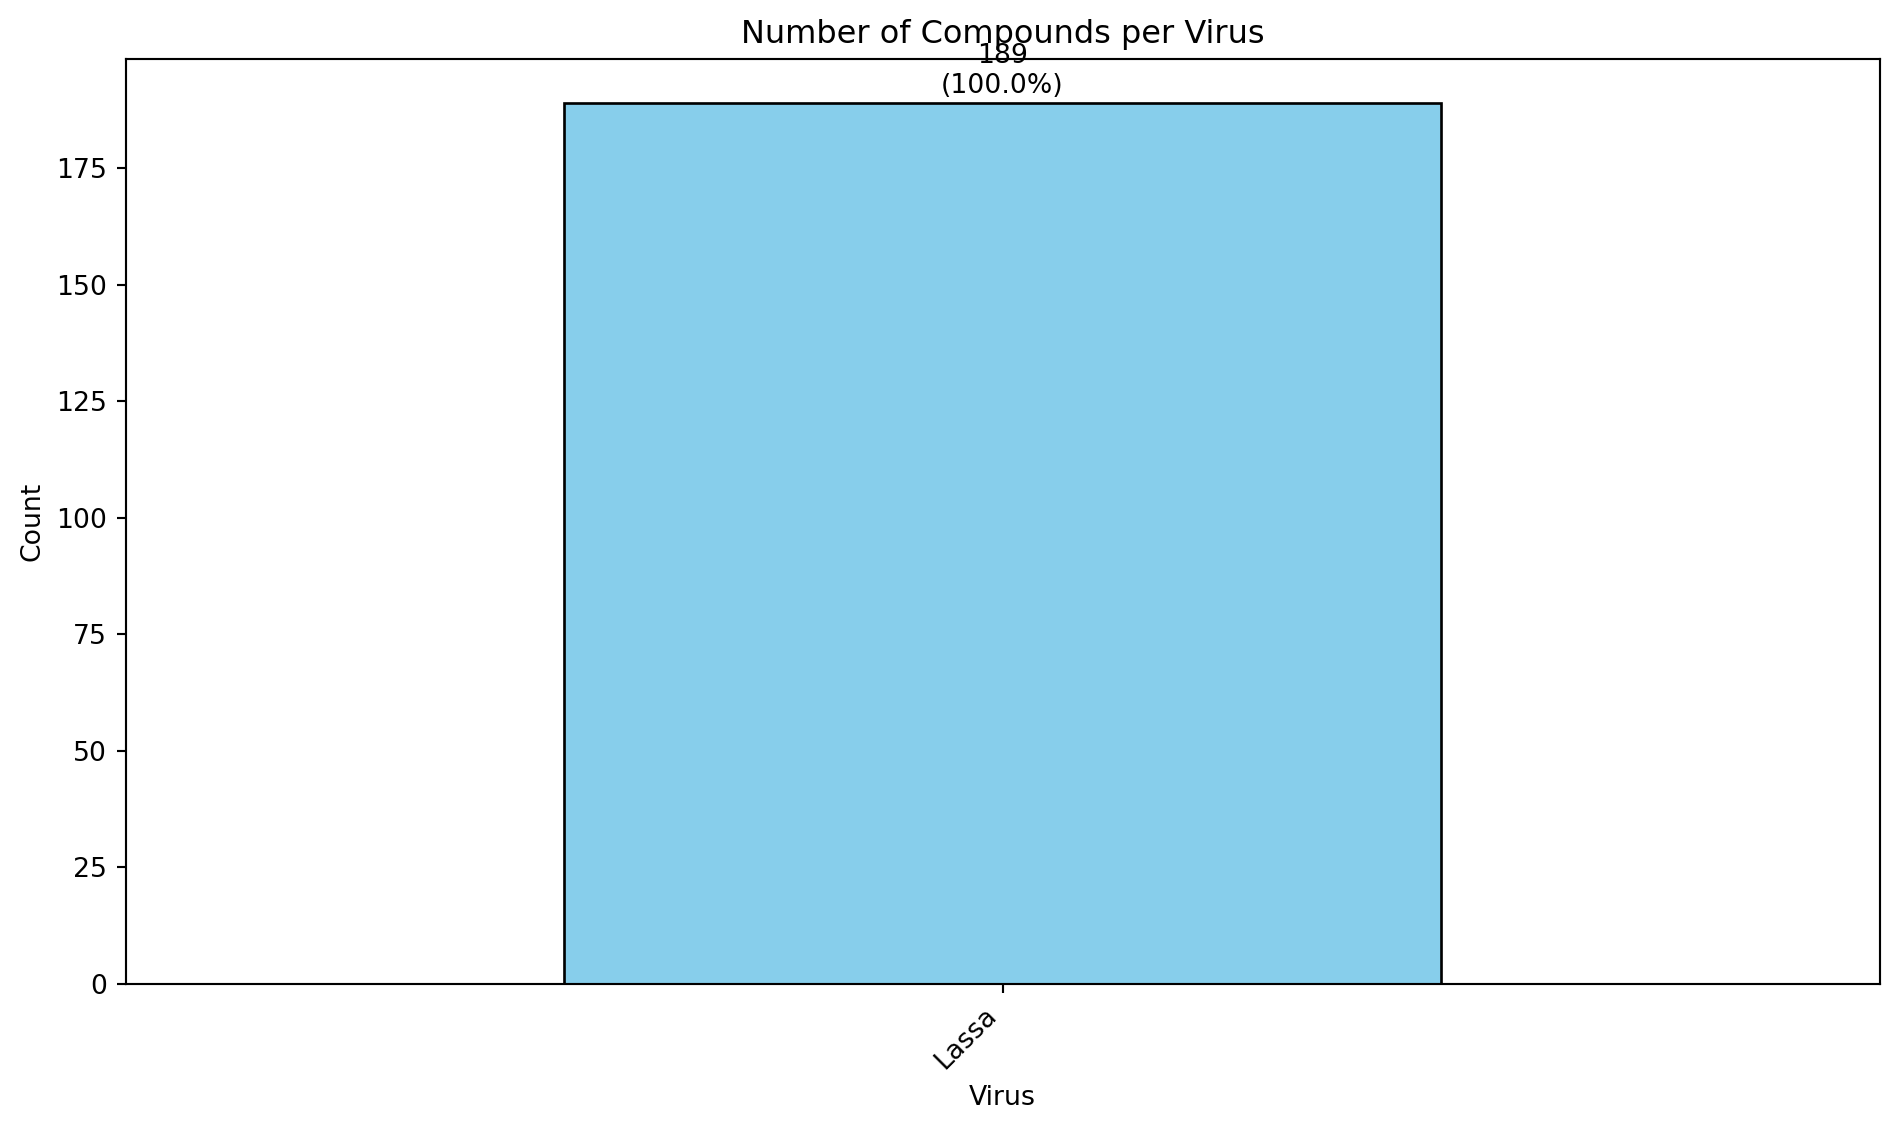

In [202]:
# Get counts and percentages
counts = LassaVirusData_chEMBL['VirusClassifier'].value_counts()
percentages = counts / counts.sum() * 100

# Create bar plot
plt.figure(figsize=(10, 6))
bars = counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Number of Compounds per Virus')
plt.xlabel('Virus')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Annotate each bar with count and %
for i, (count, pct) in enumerate(zip(counts, percentages)):
    plt.text(
        i, count + 1,                 # position (x, y)
        f'{count}\n({pct:.1f}%)',     # label: count + percentage
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

In [203]:
LassaVirusData_chEMBL.to_csv(os.path.join(modelBuildingDataDir, "LassaVirusData_chEMBL_MLready.csv"), index=False)

### Clip first 1000 rows from the data set for fast testing

### Create MACAW embeedings to run ART

In [175]:
# ---------------------------
# 1. FIT MACAW AND GENERATE EMBEDDINGS
# ---------------------------
# Initialize MACAW
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=30, 
    n_landmarks=100, 
    random_state=42
)

# Fit MACAW on SMILES and pPotency
mcw.fit(LassaVirusData_chEMBL['Smiles'], LassaVirusData_chEMBL['pPotency'])

# Save MACAW transformer
macaw_save_path = os.path.join(modelBuildingDataDir, "LassaVirusData_chEMBL_MACAW_transformer.joblib")
with open(macaw_save_path, 'wb') as f:
    pickle.dump(mcw, f)
print(f"MACAW transformer saved to: {macaw_save_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(LassaVirusData_chEMBL['Smiles'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# ---------------------------
# 2. CREATE DATAFRAME WITH EMBEDDINGS
# ---------------------------
# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=LassaVirusData_chEMBL.index)

# ---------------------------
# 3. CONCATENATE WITH ORIGINAL DATAFRAME
# ---------------------------
LassaVirusData_chEMBL_wMACAW = pd.concat([LassaVirusData_chEMBL, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {LassaVirusData_chEMBL.shape}")
print(f"New dataframe shape: {LassaVirusData_chEMBL_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
LassaVirusData_chEMBL_wMACAW.head()

MACAW transformer saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/LassaVirusData_chEMBL_MACAW_transformer.joblib
MACAW embeddings shape: (189, 30)

Original dataframe shape: (189, 5)
New dataframe shape: (189, 35)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30']


,ID,compound_id,Smiles,pPotency,VirusClassifier,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,...,MACAW_21,MACAW_22,MACAW_23,MACAW_24,MACAW_25,MACAW_26,MACAW_27,MACAW_28,MACAW_29,MACAW_30
13799,1,CHEMBL2314868,CCOc1ccc(Cn2cnc3cc(NCc4ccc(CC)cc4)cnc32)cc1,5.795880,Lassa,-0.094909,0.158204,0.006432,0.136206,-0.008794,...,-0.115718,0.151607,-0.036872,0.137210,-0.161769,0.111168,-0.136044,0.084091,-0.024646,-0.168314
13800,2,CHEMBL2315151,CCOc1ccc(-n2cnc3cc(NCc4ccc(CC)cc4)cnc32)nc1,9.008774,Lassa,-0.200112,0.308498,-0.123760,0.090422,-0.101505,...,-0.028331,0.073673,0.016438,0.014063,0.152192,-0.019781,0.046683,-0.166981,-0.030636,-0.027717
13801,3,CHEMBL2315139,CCOc1ccc(-n2ccc3cc(NCc4ccc(CC)cc4)ccc32)cc1,7.161151,Lassa,-0.166052,0.304907,-0.069324,-0.020570,-0.101522,...,-0.006431,0.007151,0.045661,0.019280,0.133590,-0.052697,-0.090095,-0.116069,0.011909,-0.029891
13802,4,CHEMBL2314867,CCOc1ccc(-n2cnc3cc(/N=C/c4ccc(CC)cc4)cnc32)cc1,5.366532,Lassa,-0.191703,0.221532,-0.104047,0.012833,-0.102646,...,-0.087396,0.056418,0.064327,-0.068445,0.228130,0.021497,0.075404,-0.039631,-0.192347,-0.044842
13803,5,CHEMBL2322815,COc1ccc(-n2cnc3cc(NCc4ccccc4OC)ccc32)cc1,6.337242,Lassa,-0.151868,0.098171,-0.056511,-0.094106,-0.036936,...,0.095532,0.065332,-0.029435,0.028224,0.016034,-0.014149,0.119943,-0.073064,-0.022371,-0.084575


In [176]:
LassaVirusData_chEMBL_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "LassaVirusData_chEMBL_wMACAW.csv"), index=False)

### Train ML Model

In [140]:
# df = LassaVirusData_chEMBL
Y = LassaVirusData_chEMBL.pPotency
smiles = LassaVirusData_chEMBL.Smiles

In [141]:
print(len(smiles))

189


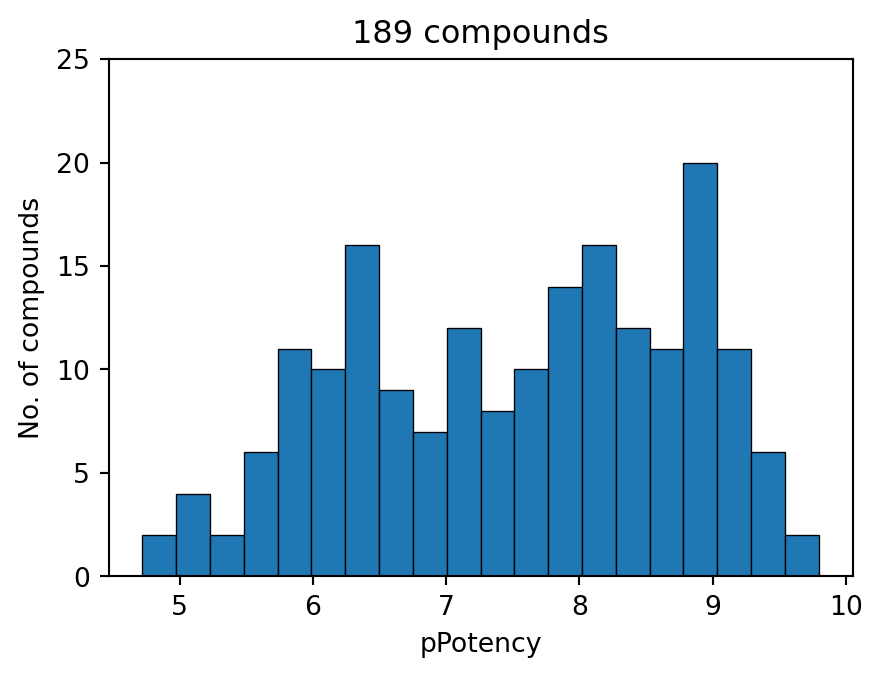

In [142]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [143]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [144]:
param_grid = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500], 
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding:

In [145]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=30, 
    n_landmarks=100, 
    random_state=42
)


After cleaning NaN values, reset the indices

In [146]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True)            

print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

Cleaned data has: 189 samples
Y index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### ML predictions with Train + Test results

In [147]:
%%time
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import Parallel, delayed
from copy import deepcopy

def process_fold(fold_id, train_index, test_index, smiles, Y, mcw, param_grid, num_partitions):
    """Process a single CV fold"""
    print(f"Partition {fold_id}/{num_partitions}")
    
    # Split data
    smi_train = smiles.iloc[train_index]
    smi_test = smiles.iloc[test_index]
    y_train = Y[train_index]
    y_test = Y[test_index]
    
    # Compute MACAW embeddings (clone to avoid conflicts)
    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)
    
    X_train = mcw_fold.transform(smi_train)
    X_test = mcw_fold.transform(smi_test)
    
    # Optimize hyperparameters
    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(X_train, y_train)
    
    best_params = grid.best_params_
    
    # Predict on both train and test
    y_cv_pred_train = grid.predict(X_train)
    y_cv_pred_test = grid.predict(X_test)
    
    # Calculate fold metrics
    train_mae = mean_absolute_error(y_train, y_cv_pred_train)
    test_mae = mean_absolute_error(y_test, y_cv_pred_test)
    print(f"  Fold {fold_id} - Train MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    
    # Return all predictions and parameters
    return {
        'train_pred': y_cv_pred_train,
        'train_obs': y_train,
        'test_pred': y_cv_pred_test,
        'test_obs': y_test,
        'best_params': best_params
    }

# Parallel execution
results = Parallel(n_jobs=4, verbose=10)(
    delayed(process_fold)(
        fold_id=i+1,
        train_index=train_idx,
        test_index=test_idx,
        smiles=smiles,
        Y=Y,
        mcw=mcw,
        param_grid=param_grid,
        num_partitions=num_of_partitions
    )
    for i, (train_idx, test_idx) in enumerate(kf.split(smiles))
)

# Combine results
Y_cv_pred_train = []
Y_obs_train = []
Y_cv_pred_test = []
Y_obs_test = []
best_params_per_fold = []

for fold_result in results:
    Y_cv_pred_train.extend(fold_result['train_pred'])
    Y_obs_train.extend(fold_result['train_obs'])
    Y_cv_pred_test.extend(fold_result['test_pred'])
    Y_obs_test.extend(fold_result['test_obs'])
    best_params_per_fold.append(fold_result['best_params'])

# Convert to numpy arrays
Y_cv_pred_train = np.array(Y_cv_pred_train)
Y_obs_train = np.array(Y_obs_train)
Y_cv_pred_test = np.array(Y_cv_pred_test)
Y_obs_test = np.array(Y_obs_test)

# ===== OVERALL METRICS =====
print("\n" + "-"*40)
print("Cross Validation Metrics")
print("-"*40)

# Train metrics
train_mae = mean_absolute_error(Y_obs_train, Y_cv_pred_train)
train_rmse = np.sqrt(mean_squared_error(Y_obs_train, Y_cv_pred_train))
train_r2 = r2_score(Y_obs_train, Y_cv_pred_train)

print(f"Train Set:")
print(f"  MAE:  {train_mae:.2f}")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  R²:   {train_r2:.2f}")

# Test metrics
test_mae = mean_absolute_error(Y_obs_test, Y_cv_pred_test)
test_rmse = np.sqrt(mean_squared_error(Y_obs_test, Y_cv_pred_test))
test_r2 = r2_score(Y_obs_test, Y_cv_pred_test)

print(f"Test Set:")
print(f"  MAE:  {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  R²:   {test_r2:.2f}")

print(f"\nBest params (sample): {best_params_per_fold[:3]}")


----------------------------------------
Cross Validation Metrics
----------------------------------------
Train Set:
  MAE:  0.37
  RMSE: 0.55
  R²:   0.80
Test Set:
  MAE:  0.64
  RMSE: 0.83
  R²:   0.54

Best params (sample): [{'C': 5, 'epsilon': 0.3, 'kernel': 'rbf'}, {'C': 1, 'epsilon': 0.1, 'kernel': 'rbf'}, {'C': 5, 'epsilon': 0.1, 'kernel': 'rbf'}]
CPU times: user 102 ms, sys: 48.9 ms, total: 151 ms
Wall time: 2.12 s


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Lassa_bestMACAW//LassaVirus_CV_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Lassa_bestMACAW//LassaVirus_CV_TrTs.png


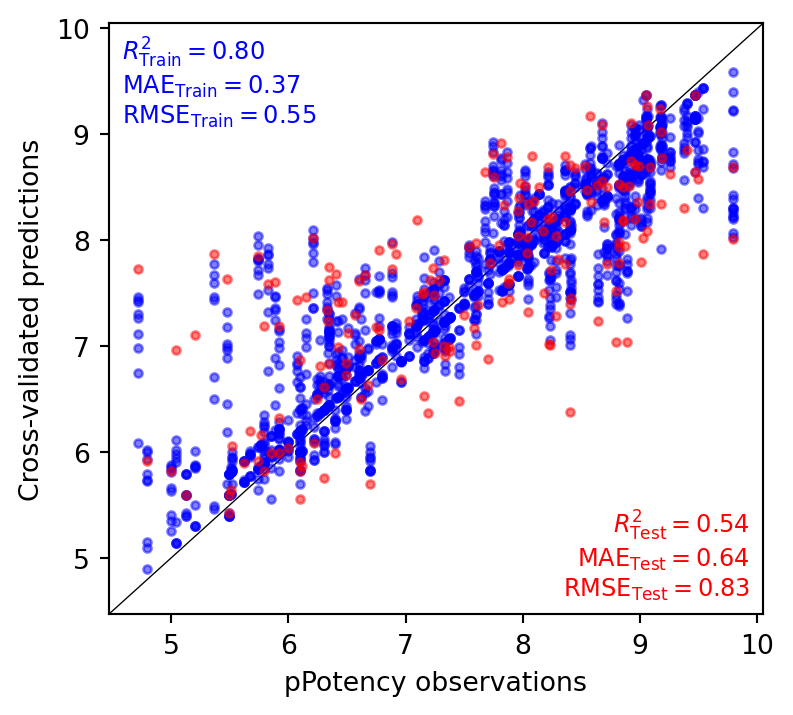

In [148]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=saveDir + '/LassaVirus_CV_TrTs.svg',
            save_formats=['svg', 'png'])

Generate a model trained on the whole data set, to be used for prediction tasks

In [155]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=100, 
    random_state=42
)

mcw.fit(smiles, Y)

In [156]:
X_all = mcw.transform(smiles)
X_all.shape

(189, 15)

Training samples: 151
Test samples: 38
Feature dimensions: 30

Running GridSearchCV with 4 parallel jobs...

------------------------------------------------------------
Best Hyperparameters:
------------------------------------------------------------
  C: 5
  epsilon: 0.3
  kernel: rbf

Best CV MAE (on training folds): 0.71

------------------------------------------------------------
PERFORMANCE COMPARISON:
------------------------------------------------------------
Metric     Training        Test            Difference     
------------------------------------------------------------
R²         0.85            0.64            0.21           
MAE        0.35            0.57            0.23           
RMSE       0.48            0.76            0.28           
------------------------------------------------------------


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Lassa_bestMACAW//LassaVirus_fullData_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6

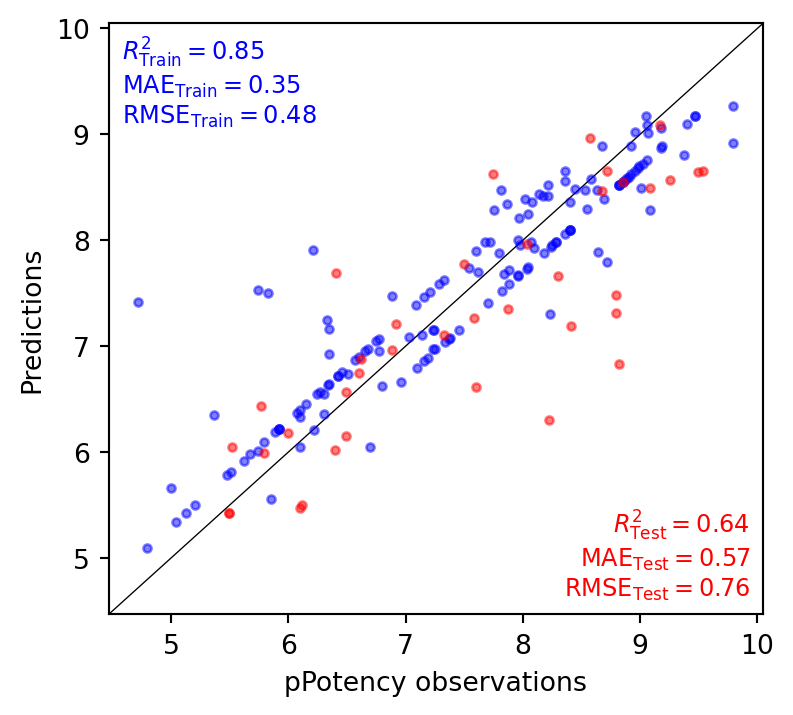

CPU times: user 1.18 s, sys: 112 ms, total: 1.29 s
Wall time: 2.07 s


In [158]:
%%time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# ---------------------------
# 1. TRAIN-TEST SPLIT
# ---------------------------
# Since you're working with only one virus group, use regular train_test_split
X_train_smi, X_test_smi, Y_train, Y_test = train_test_split(
    smiles, Y, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print(f"Training samples: {len(X_train_smi)}")
print(f"Test samples: {len(X_test_smi)}")

# ---------------------------
# 2. FIT MACAW ON TRAINING DATA ONLY
# ---------------------------
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=30, 
    n_landmarks=100, 
    random_state=42
)
mcw.fit(X_train_smi, Y_train)

# Transform both train and test
X_train = mcw.transform(X_train_smi)
X_test = mcw.transform(X_test_smi)

print(f"Feature dimensions: {X_train.shape[1]}")

# ---------------------------
# 3. GRID SEARCH ON TRAINING DATA ONLY
# ---------------------------
n_jobs = 4

regr_pred = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    refit=True,
    n_jobs=n_jobs,
    verbose=0,
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    pre_dispatch='2*n_jobs'
)

print(f"\nRunning GridSearchCV with {n_jobs} parallel jobs...")
regr_pred.fit(X_train, Y_train)

# ---------------------------
# 4. DISPLAY BEST HYPERPARAMETERS
# ---------------------------
print("\n" + "-"*60)
print("Best Hyperparameters:")
print("-"*60)
for param, value in regr_pred.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV MAE (on training folds): {-regr_pred.best_score_:.2f}")

# ---------------------------
# 5. PREDICTIONS AND METRICS
# ---------------------------
# Training predictions (in-sample)
y_train_pred = regr_pred.predict(X_train)

# Test predictions (held-out)
y_test_pred = regr_pred.predict(X_test)

# Calculate metrics for TRAIN
train_r2 = r2_score(Y_train, y_train_pred)
train_mae = mean_absolute_error(Y_train, y_train_pred)
train_rmse = np.sqrt(np.mean((Y_train - y_train_pred)**2))

# Calculate metrics for TEST
test_r2 = r2_score(Y_test, y_test_pred)
test_mae = mean_absolute_error(Y_test, y_test_pred)
test_rmse = np.sqrt(np.mean((Y_test - y_test_pred)**2))

# ---------------------------
# 6. DISPLAY RESULTS
# ---------------------------
print("\n" + "-"*60)
print("PERFORMANCE COMPARISON:")
print("-"*60)
print(f"{'Metric':<10} {'Training':<15} {'Test':<15} {'Difference':<15}")
print("-"*60)
print(f"{'R²':<10} {train_r2:<15.2f} {test_r2:<15.2f} {abs(train_r2-test_r2):<15.2f}")
print(f"{'MAE':<10} {train_mae:<15.2f} {test_mae:<15.2f} {abs(train_mae-test_mae):<15.2f}")
print(f"{'RMSE':<10} {train_rmse:<15.2f} {test_rmse:<15.2f} {abs(train_rmse-test_rmse):<15.2f}")
print("-"*60)

# Check for overfitting
overfit_gap = train_r2 - test_r2
if overfit_gap > 0.1:
    print("\n  WARNING: Possible overfitting detected (R² gap > 0.1)")
elif test_r2 >= 0.7:
    print("\n Good generalization performance!")

print("\n" + "="*60)

# ---------------------------
# 7. GENERATE PARITY PLOT
# ---------------------------
parity_plot(
    x=Y_train,                      # observed train
    y=y_train_pred,                 # predicted train (in-sample)
    x_test=Y_test,                  # observed test
    y_test=y_test_pred,             # predicted test (held-out)
    xlabel="pPotency observations",
    ylabel="Predictions",
    savetitle=saveDir + '/LassaVirus_fullData_TrTs.svg',
    save_formats=['svg', 'png']
)

### Compare performance of different ML model

- SVR
- Random Forest
- XGBoost
- LightGBM
- CatBoost
- Neural Network

Import all necessary libraries

## 2.1 Discovery of new hits specific to all viruses (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [177]:
EnamineAntiviralsData = pd.read_csv(dataDir + "Enamine/Enamine_Antiviral_Library_plated_3200cmpds_20251019.csv",
                                    sep=",", comment=None, skipinitialspace=True, engine="python", encoding="utf-8",          
                                    skiprows=1, skip_blank_lines=True)
print(f"Original Enamine data shape: {EnamineAntiviralsData.shape}")

smiles_train = LassaVirusData_chEMBL_wMACAW.Smiles

# Function to canonicalize SMILES using RDKit
def canonicalize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            return Chem.MolToSmiles(mol, canonical=True)
        else:
            return None
    except:
        return None

# Canonicalize training SMILES and create a set for fast lookup
canonical_train = set()
for smi in smiles_train:
    canonical_smi = canonicalize_smiles(smi)
    if canonical_smi is not None:
        canonical_train.add(canonical_smi)

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to Enamine data
EnamineAntiviralsData['Canonical_SMILES'] = EnamineAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~EnamineAntiviralsData['Canonical_SMILES'].isin(canonical_train)
EnamineAntiviralsData_filtered = EnamineAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
EnamineAntiviralsData = EnamineAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered Enamine data shape for validation: {EnamineAntiviralsData.shape}")
print(f"Removed {EnamineAntiviralsData.shape[0] - EnamineAntiviralsData_filtered.shape[0]} duplicate compounds from Enamine data set")

# Now use the filtered data
smi_lib_EnamineDataset = EnamineAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib_EnamineDataset)}")
EnamineAntiviralsData.head()

Original Enamine data shape: (3200, 11)
Number of unique SMILES in training set: 183
Filtered Enamine data shape for validation: (3200, 11)
Removed 0 duplicate compounds from Enamine data set
Total compounds to screen: 3200


,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL
0,COCC(C)NC(=O)NC1=NN=C(S1)C2CC2,Z410227912,256.326,256.326,1.231,-2.190,2,4,76.14,5,https://real.enamine.net/public-enum-files/Z41...
1,CN1C(=O)C=CN(CC(=O)NCC2CC2)C1=O,Z383167688,237.256,237.256,-0.042,-0.692,1,3,69.72,5,https://real.enamine.net/public-enum-files/Z38...
2,CCN(CC)CCNC(=O)C1=CC=CN=C1N2CCOCC2,Z235579208,306.404,306.404,1.583,-2.082,1,5,57.70,7,NaN
3,CCC(CNC(=O)CC=1C(C)=NOC1C)N2CCCC2,Z403694008,279.379,279.379,1.156,-0.660,1,3,58.37,7,https://real.enamine.net/public-enum-files/Z40...
4,CCC(C)(CNC(=O)CN1C=CC=CC1=O)N2CCOCC2,Z384461492,307.389,307.389,1.084,-1.180,1,4,61.88,7,https://real.enamine.net/public-enum-files/Z38...


Generate predictions for the H1 receptor:

In [178]:
smi_lib_EnamineDataset_wMACAW = mcw.transform(smi_lib_EnamineDataset)

# Create column names
num_features = smi_lib_EnamineDataset_wMACAW.shape[1]
column_names = [f'MACAW_{i+1}' for i in range(num_features)]

# Create DataFrame with same index as smi_lib
SMILES_lib_EnamineDataset = pd.DataFrame(smi_lib_EnamineDataset_wMACAW, columns=column_names, index=smi_lib_EnamineDataset.index)
# Then add SMILES as first column
SMILES_lib_EnamineDataset.insert(0, 'SMILES', smi_lib_EnamineDataset)
# Save to CSV
SMILES_lib_EnamineDataset.to_csv(os.path.join(saveDir, "LassaVirus_EnamineDataset_wMACAW.csv"), index=False)
SMILES_lib_EnamineDataset

,SMILES,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,MACAW_9,...,MACAW_21,MACAW_22,MACAW_23,MACAW_24,MACAW_25,MACAW_26,MACAW_27,MACAW_28,MACAW_29,MACAW_30
0,COCC(C)NC(=O)NC1=NN=C(S1)C2CC2,0.064846,-0.013306,0.027461,0.127448,0.052809,-0.102919,0.010308,0.002427,0.026655,...,0.041719,0.011118,-0.001658,-0.000752,-0.011968,-0.015609,0.016243,-0.005641,0.005699,0.013235
1,CN1C(=O)C=CN(CC(=O)NCC2CC2)C1=O,0.120899,0.021779,0.038184,0.103440,0.014033,-0.093019,-0.037911,-0.023275,0.014358,...,0.035486,-0.035319,-0.007508,0.015398,0.017641,-0.033848,-0.027880,-0.032976,0.040884,0.007238
2,CCN(CC)CCNC(=O)C1=CC=CN=C1N2CCOCC2,0.082577,0.030865,0.093907,0.153282,0.019489,-0.112542,-0.005510,0.007145,0.030870,...,0.005158,0.007778,0.012306,0.019980,-0.015885,0.007353,-0.008920,-0.021909,0.008609,0.042095
3,CCC(CNC(=O)CC=1C(C)=NOC1C)N2CCCC2,0.104986,0.014261,0.099781,0.134030,0.042728,-0.083004,0.015907,0.006184,0.025181,...,0.033586,-0.044718,-0.011756,0.043142,-0.023855,-0.024187,0.002265,0.030175,0.012904,-0.015552
4,CCC(C)(CNC(=O)CN1C=CC=CC1=O)N2CCOCC2,0.108071,0.030563,0.068385,0.124577,0.012316,-0.080312,-0.015901,-0.014208,0.052851,...,0.013578,-0.023400,-0.047301,-0.025139,-0.015453,-0.034062,-0.025378,0.047778,-0.019885,0.023299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3195,CCOC=1N=CC=CC1NC(=O)NC2CCN3CCCCC23,0.131530,0.030766,0.089201,0.173581,0.015786,-0.085408,0.027909,0.041715,0.018216,...,0.026792,-0.013767,0.029046,0.030259,-0.025591,-0.034691,0.021485,-0.004078,0.042448,0.026309
3196,CC1=NN(CC(O)C=2C=CC=CC2)C(=O)C(C#N)=C1C,0.135889,-0.076075,-0.010638,0.079220,-0.008261,-0.082257,-0.009696,-0.040573,-0.003079,...,0.057554,-0.043476,-0.060303,-0.002477,-0.069605,-0.045575,0.042558,0.001085,-0.042773,-0.004990
3197,CCC1=NN=NN1CC(=O)NC2CCN(CC2)C(C)=O,0.084423,0.013356,0.111691,0.139996,0.054996,-0.101627,0.038645,-0.028121,0.008225,...,0.008569,-0.030001,-0.005431,-0.001218,-0.048069,-0.009529,0.005972,-0.023128,-0.005918,0.014390
3198,CC=1C=C2N=CN(CC(O)CN3CCS(=O)CC3)C2=CC1C,0.105333,0.036899,0.110096,0.138165,0.005509,-0.080001,0.004990,0.030195,-0.000817,...,0.023563,-0.052484,-0.003185,-0.033711,-0.047074,-0.031262,-0.011912,0.020982,-0.020488,-0.020413


read results from ART predictions

In [ ]:
EnamineAntiviralsData_predicted = pd.read_csv(saveDir + 'LassaVirus_wART_EnamineDataset_predicted_all.csv')
max_val = EnamineAntiviralsData_predicted['pPotency_prediction'].max()
min_val = EnamineAntiviralsData_predicted['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

EnamineAntiviralsData_predicted

Let us represent the predictions of both models:

In [ ]:
Y1_lib_pred = EnamineAntiviralsData_predicted['pPotency_prediction'].values

In [ ]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + 'LassaVirus_validation_wART.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + 'LassaVirus_validation_wART.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [ ]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7.0)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

In [ ]:
EnamineAntiviralsData_final = EnamineAntiviralsData.iloc[idx].copy()
EnamineAntiviralsData_final['pPotency_prediction'] = Y1_lib_pred[idx]

EnamineAntiviralsData_final

### Top 20 compounds with higher PpPotency

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
EnamineAntiviralsData_top20 = EnamineAntiviralsData_predicted.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
EnamineAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
EnamineAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
EnamineAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
EnamineAntiviralsData_top20 = EnamineAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (M)"]
)
EnamineAntiviralsData_top20

In [ ]:
EnamineAntiviralsData_top20.to_csv(os.path.join(saveDir + "LassaVirus_EnamineAntiviralsData_top20_wART.csv"), index=False)
EnamineAntiviralsData_top20[['SMILES']].to_csv(os.path.join(saveDir + "LassaVirus_EnamineAntiviralsData_top20_SMILES_wART.csv"), index=False)

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image


# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_top20.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in EnamineAntiviralsData_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'LassaVirus_enamine_predictedCompounds_wART.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'LassaVirus_enamine_predictedCompounds_wART.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

## 2.2 Discovery of new hits specific to all viruses (data source Life chemicals data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [179]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "LifeChemicals/LC_Merged_Antiviral_Screening_Superset.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

LCAntiviralsData_superset = pd.DataFrame(records)
print(f"Original LifeChemicals data shape: {LCAntiviralsData_superset.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to LifeChemicals data (reusing canonical_train from code-1)
LCAntiviralsData_superset['Canonical_SMILES'] = LCAntiviralsData_superset['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~LCAntiviralsData_superset['Canonical_SMILES'].isin(canonical_train)
LCAntiviralsData_superset_filtered = LCAntiviralsData_superset[mask].copy()

# Remove the helper column if you don't need it
LCAntiviralsData_superset = LCAntiviralsData_superset_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered LifeChemicals data shape for validation: {LCAntiviralsData_superset.shape}")
print(f"Removed {LCAntiviralsData_superset_filtered.shape[0] - LCAntiviralsData_superset.shape[0]} duplicate compounds from LifeChemicals data set")

# Now use the filtered data
smi_lib_LCAntiviralsData = LCAntiviralsData_superset.SMILES
print(f"Total compounds to screen: {len(smi_lib_LCAntiviralsData)}")
LCAntiviralsData_superset.head()

Original LifeChemicals data shape: (45573, 17)
Number of unique SMILES in training set: 183
Filtered LifeChemicals data shape for validation: (45573, 17)
Removed 0 duplicate compounds from LifeChemicals data set
Total compounds to screen: 45573


,IDNUMBER,Chemical_Name,CAS,PriceCoeff,MW,Description,FSP3,clogP,TPSA,Acceptor,Donor,RotBonds,HAC,Collection,Library,PPDS,SMILES
0,F6544-0534,"11-(oxan-4-yl)-7,11-diazatricyclo[7.3.1.0²,⁷]t...",2034607-75-3,1.5,274.36,solid,0.69,-0.12,32.78,2,1,1,20.0,Advanced,Anti-Hepatitis_A_B_ Screening_Library,,Cl.O=c1cccc2n1CC1CC2CN(C2CCOCC2)C1
1,F6559-5304,6-[4-(trifluoromethyl)pyrimidin-2-yl]-6-azaspi...,2034225-11-9,1.5,301.26,solid,0.62,2.03,66.32,4,1,2,21.0,Advanced,2019-nCoV_Main_Protease_Targeted_Library,+,O=C(O)C1CN(c2nccc(C(F)(F)F)n2)CC12CCC2
2,F6610-6619,"1-methyl-4-[(pyridin-4-yl)methyl]-1,4-diazepane",2320860-02-2,1.0,205.30,oil,0.58,0.89,19.37,3,3,2,15.0,General,Anti-HIV_Focused_Library,,CN1CCCN(Cc2ccncc2)CC1
3,F6559-5274,"6-(4,6-dimethylpyrimidin-2-yl)-6-azaspiro[3.4]...",2034225-08-4,1.5,261.32,oil,0.64,2.09,66.32,4,1,2,19.0,Advanced,Antiviral_Screening_Compound_Library_2D_Simila...,,Cc1cc(C)nc(N2CC(C(=O)O)C3(CCC3)C2)n1
4,F1912-1536,N-cyclopropyl-N-(piperidin-4-yl)pyrimidin-4-amine,1781768-10-2,1.5,218.29,solid,0.67,0.79,41.05,2,2,3,16.0,Advanced,Antiviral_Screening_Compound_Library_2D_Simila...,,c1cc(N(C2CCNCC2)C2CC2)ncn1


Generate predictions for the H1 receptor:

In [180]:
smi_lib_LCAntiviralsData_wMACAW = mcw.transform(smi_lib_LCAntiviralsData)

# Create column names
num_features = smi_lib_LCAntiviralsData_wMACAW.shape[1]
column_names = [f'MACAW_{i+1}' for i in range(num_features)]

# Create DataFrame with same index as smi_lib
SMILES_lib_LCAntiviralsData = pd.DataFrame(smi_lib_LCAntiviralsData_wMACAW, columns=column_names, index=smi_lib_LCAntiviralsData.index)
# Then add SMILES as first column
SMILES_lib_LCAntiviralsData.insert(0, 'SMILES', smi_lib_LCAntiviralsData)
# Save to CSV
SMILES_lib_LCAntiviralsData.to_csv(os.path.join(saveDir + "LassaVirus_LCAntiviralsData_wMACAW.csv"), index=False)
SMILES_lib_LCAntiviralsData

,SMILES,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,MACAW_9,...,MACAW_21,MACAW_22,MACAW_23,MACAW_24,MACAW_25,MACAW_26,MACAW_27,MACAW_28,MACAW_29,MACAW_30
0,Cl.O=c1cccc2n1CC1CC2CN(C2CCOCC2)C1,0.123123,0.037124,0.119924,0.137663,0.005966,-0.090376,-0.039528,0.015815,-0.005039,...,0.013943,0.015093,0.000057,-0.018441,-0.043536,-0.032924,-0.024045,-0.025500,-0.014848,0.044083
1,O=C(O)C1CN(c2nccc(C(F)(F)F)n2)CC12CCC2,0.111240,0.019406,0.116173,0.146379,0.033968,-0.152091,-0.022747,-0.080464,0.022580,...,0.018936,0.027380,-0.023846,-0.053627,-0.052944,-0.026206,-0.050099,0.009775,-0.018842,0.055159
2,CN1CCCN(Cc2ccncc2)CC1,0.093307,0.012385,0.135466,0.132714,0.000740,-0.161886,-0.020942,-0.016967,0.001823,...,-0.022651,-0.021844,-0.011255,0.013747,-0.024936,-0.029318,-0.015806,0.011300,-0.058608,0.052383
3,Cc1cc(C)nc(N2CC(C(=O)O)C3(CCC3)C2)n1,0.112478,-0.006847,0.101214,0.125043,0.010291,-0.125996,-0.002314,-0.012929,-0.000419,...,0.007248,-0.000133,-0.019263,-0.035023,-0.057444,-0.007775,-0.011297,0.027521,0.008844,0.008969
4,c1cc(N(C2CCNCC2)C2CC2)ncn1,0.102934,-0.023020,0.123521,0.150778,0.013562,-0.153278,-0.011297,-0.020138,-0.024938,...,-0.008035,0.002151,-0.030678,-0.010403,-0.016625,-0.063597,-0.029233,-0.022287,0.002666,0.046987
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45568,CCN1C=C/C(=C\C=C\c2cc[n+](CC)c3ccccc23)c2ccccc...,0.014508,0.013889,0.097718,0.025551,-0.023199,-0.089654,-0.071670,0.025916,0.001562,...,-0.048638,-0.106843,-0.021568,0.011844,0.017681,-0.026859,-0.039569,-0.015377,-0.026264,-0.034208
45569,CCCN1/C(=C/C=C/c2sc3ccccc3[n+]2CCC)Sc2ccccc21....,0.040006,0.051538,0.133399,0.047339,0.015305,-0.102302,-0.043233,-0.005951,-0.006096,...,0.022226,-0.088506,-0.075072,-0.002716,-0.033948,-0.008078,-0.021183,0.038542,-0.008048,-0.066517
45570,COC(=O)c1ccccc1-c1c2ccc(=N)cc-2oc2cc(N)ccc12.Cl,0.030854,-0.056443,0.040623,0.041545,0.036960,-0.039386,0.002571,-0.022474,0.066827,...,0.030959,0.000913,-0.044281,0.003321,-0.065871,0.003272,-0.016484,-0.038921,-0.033426,-0.008732
45571,CCN1/C(=C/C=C2\CCC(/C=C/c3sc4ccc(Cl)cc4[n+]3CC...,0.040324,0.064372,0.171714,-0.000526,0.138884,-0.005216,-0.004633,-0.013734,-0.004559,...,0.043273,-0.050811,-0.038974,-0.098166,-0.077005,0.046520,-0.031767,0.059075,0.043100,-0.055854


In [ ]:
LCAntiviralsData_predicted = pd.read_csv(saveDir + 'LassaVirus_wART_LCAntiviralsData_predicted_all.csv')
max_val = LCAntiviralsData_predicted['pPotency_prediction'].max()
min_val = LCAntiviralsData_predicted['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
LCAntiviralsData_predicted

Let us represent the predictions of both models:

In [ ]:
Y1_lib_pred = LCAntiviralsData_predicted['pPotency_prediction'].values

In [ ]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + 'LassaVirus_validation_LCDatasets_wART.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + 'LassaVirus_validation_LCDatasets_wART.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [ ]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7.0)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

### Top 20 compounds with higher PpPotency

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
LCAntiviralsData_top20 = LCAntiviralsData_predicted.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
LCAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
LCAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
LCAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
LCAntiviralsData_top20 = LCAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (M)"]
)
LCAntiviralsData_top20

In [ ]:
LCAntiviralsData_top20.to_csv(os.path.join(saveDir + "LassaVirus_LCAntiviralsData_top20_wART.csv"), index=False)
LCAntiviralsData_top20[['SMILES']].to_csv(os.path.join(saveDir + "LassaVirus_LCAntiviralsData_top20_SMILES_wART.csv"), index=False)

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image


# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in LCAntiviralsData_top20.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in LCAntiviralsData_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'LassaVirus_predictedCompounds_LCDataset_wART.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'LassaVirus_predictedCompounds_LCDataset_wART.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

# 2.3 Discovery of new hits specific to all viruses (data source chemDiv data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. The custom library compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [181]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "ChemDiv/ChemDiv_Antiviral-Library-64958.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

ChemDivAntiviralsData = pd.DataFrame(records)
print(f"Original ChemDiv data shape: {ChemDivAntiviralsData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to ChemDiv data (reusing canonical_train from previous code)
ChemDivAntiviralsData['Canonical_SMILES'] = ChemDivAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~ChemDivAntiviralsData['Canonical_SMILES'].isin(canonical_train)
ChemDivAntiviralsData_filtered = ChemDivAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
ChemDivAntiviralsData = ChemDivAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered ChemDiv data shape for validation: {ChemDivAntiviralsData.shape}")
print(f"Removed {ChemDivAntiviralsData_filtered.shape[0] - ChemDivAntiviralsData.shape[0]} duplicate compounds from ChemDiv data set")

# Now use the filtered data
smi_lib_ChemDivAntiviralsData = ChemDivAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib_ChemDivAntiviralsData)}")
ChemDivAntiviralsData

Original ChemDiv data shape: (64958, 28)
Number of unique SMILES in training set: 183
Filtered ChemDiv data shape for validation: (64957, 28)
Removed 0 duplicate compounds from ChemDiv data set
Total compounds to screen: 64957


,IDNUMBER,available,H_acceptor,H_donor,B_rotN,N_O,logP,logD,logSw,PSA,...,InChI Key,PERCENTSP3,Link,CLNUMBER,Saltdata,Saltdata_MW,STEREO,State,SMILES,CAS
0,E676-1193,55,6,0,10,6.0,4.5844,3.8255,-4.7363,44.193,...,CADSCKHSUSMLDE-UHFFFAOYSA-N,33.3,https://www.chemdiv.com/catalog/screening-comp...,CL4971B,HCl,36.461,ACHIRAL,Solid,CCOc1cccc2sc(N(CCN(C)C)C(=O)COc3ccc(Cl)cc3)nc12,NaN
1,E676-4289,2,8,0,9,7.0,2.0836,1.2794,-2.8669,59.381,...,GBCBRISSOXAFMF-UHFFFAOYSA-N,47.4,https://www.chemdiv.com/catalog/screening-comp...,CL4971B,HCl,36.461,ACHIRAL,Solid,CCN(CC)CCN(C(=O)CN1C(=O)CCC1=O)c1nc2c(Cl)cccc2s1,NaN
2,E676-2516,15,7,0,7,7.0,4.2745,3.4440,-4.3551,53.078,...,LSLRIDUYGBBIBR-SFHVURJKSA-N,36.4,https://www.chemdiv.com/catalog/screening-comp...,CL4971B,HCl,36.461,RACEMIC MIXTURE,Solid,COc1ccc(C)c2sc(N(CCN(C)C)C(=O)C3COc4ccccc4O3)nc12,NaN
3,F735-0482,21,7,2,9,7.0,3.2314,3.2247,-3.4234,79.491,...,NBFDETMKPOQYSJ-UHFFFAOYSA-N,22.2,https://www.chemdiv.com/catalog/screening-comp...,CL8286,NaN,NaN,ACHIRAL,Solid,CCCc1nnc(C(=O)Nc2ccc(C(=O)NCc3ccco3)cc2)s1,NaN
4,G211-0195,304,5,1,5,5.0,5.0539,5.0538,-5.4692,49.877,...,DRPXIGZHBISZAU-UHFFFAOYSA-N,32.0,https://www.chemdiv.com/catalog/screening-comp...,CL6036,NaN,NaN,ACHIRAL,Solid,O=C(NCc1cccc(Cl)c1)c1c2c(nc3ccccc13)C(=O)N(C1C...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64953,8010-2606,54,8,1,9,8.0,6.6853,3.1000,-6.6782,70.818,...,ZQXAXHNEVALOJP-UHFFFAOYSA-N,30.8,https://www.chemdiv.com/catalog/screening-comp...,CL1650,NaN,NaN,ACHIRAL,Solid,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,NaN
64954,2774-1508,1,7,1,8,7.0,6.5514,3.8841,-5.7384,62.323,...,KDXCUTJRVPCZKK-UHFFFAOYSA-N,25.0,https://www.chemdiv.com/catalog/screening-comp...,CL1652,NaN,NaN,ACHIRAL,Solid,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,NaN
64955,K061-0539,124,7,1,7,7.0,6.0140,2.4287,-5.4637,64.713,...,XEIANUQFWJNADZ-UHFFFAOYSA-N,27.3,https://www.chemdiv.com/catalog/screening-comp...,CL1647,NaN,NaN,ACHIRAL,Solid,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,NaN
64956,K061-0894,165,6,1,7,7.0,6.9051,6.3866,-6.7611,57.369,...,IBXAKUXFQPUZBE-UHFFFAOYSA-N,13.6,https://www.chemdiv.com/catalog/screening-comp...,CL1650,NaN,NaN,ACHIRAL,Solid,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,NaN


In [182]:
smi_lib_ChemDivAntiviralsData_wMACAW = mcw.transform(smi_lib_ChemDivAntiviralsData)

# Create column names
num_features = smi_lib_ChemDivAntiviralsData_wMACAW.shape[1]
column_names = [f'MACAW_{i+1}' for i in range(num_features)]

# Create DataFrame with same index as smi_lib
SMILES_lib_ChemDivAntiviralsData = pd.DataFrame(smi_lib_ChemDivAntiviralsData_wMACAW, columns=column_names, index=smi_lib_ChemDivAntiviralsData.index)
# Then add SMILES as first column
SMILES_lib_ChemDivAntiviralsData.insert(0, 'SMILES', smi_lib_ChemDivAntiviralsData)
# Save to CSV
SMILES_lib_ChemDivAntiviralsData.to_csv(os.path.join(saveDir + "LassaVirus_ChemDivAntiviralsData_wMACAW.csv"), index=False)
SMILES_lib_ChemDivAntiviralsData

50000


,SMILES,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,MACAW_9,...,MACAW_21,MACAW_22,MACAW_23,MACAW_24,MACAW_25,MACAW_26,MACAW_27,MACAW_28,MACAW_29,MACAW_30
0,CCOc1cccc2sc(N(CCN(C)C)C(=O)COc3ccc(Cl)cc3)nc12,0.090669,0.031061,0.100974,0.013837,0.066385,-0.042163,0.051814,0.008387,0.053783,...,0.052713,-0.066420,-0.038631,-0.016264,0.004047,0.049590,0.010090,0.044922,-0.001970,0.039237
1,CCN(CC)CCN(C(=O)CN1C(=O)CCC1=O)c1nc2c(Cl)cccc2s1,0.100083,0.038653,0.169378,0.115538,0.026781,-0.068392,0.039406,-0.058989,0.026850,...,0.066035,0.015856,0.015935,0.010277,-0.003211,0.015431,-0.021262,0.027692,-0.018389,0.009307
2,COc1ccc(C)c2sc(N(CCN(C)C)C(=O)C3COc4ccccc4O3)nc12,0.115830,0.005675,0.109674,0.001619,0.052434,-0.030051,0.095625,0.075520,0.076154,...,-0.017836,-0.011618,-0.069763,0.028576,-0.016713,0.002441,0.059458,-0.016530,0.040177,-0.030919
3,CCCc1nnc(C(=O)Nc2ccc(C(=O)NCc3ccco3)cc2)s1,0.063558,0.029436,0.028895,0.153158,0.119304,0.046722,0.012346,0.044742,0.040977,...,-0.043537,0.041415,-0.028591,0.008936,-0.119490,0.028207,-0.053777,-0.026701,0.028490,0.010981
4,O=C(NCc1cccc(Cl)c1)c1c2c(nc3ccccc13)C(=O)N(C1C...,0.137036,0.046171,0.157012,0.159574,0.060311,-0.069681,-0.046544,-0.010405,0.012507,...,0.051453,0.020241,0.010006,-0.019139,-0.069586,0.021098,0.012000,-0.016252,0.049605,0.033314
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64953,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,0.003658,0.053308,0.091227,0.137538,0.114210,-0.002841,0.056596,-0.060448,0.071491,...,0.026981,0.040036,-0.002939,-0.001265,-0.072889,0.041671,0.044653,-0.022942,0.050524,-0.020775
64954,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,0.005118,0.069222,0.073615,0.135016,0.118425,-0.000902,0.027369,-0.079498,0.072685,...,0.008799,0.037347,-0.003477,-0.018577,-0.049629,0.016517,0.048417,0.003190,0.044190,-0.020277
64955,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,0.024864,0.041441,0.089723,0.156909,0.114573,-0.041776,0.042384,-0.059231,0.075756,...,0.011764,0.032668,-0.026117,-0.025160,-0.067854,0.014027,0.030822,0.031582,0.038737,-0.019520
64956,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,-0.016695,-0.003529,0.041599,0.058115,0.121074,-0.013902,0.081346,-0.082807,0.136833,...,0.008376,0.006989,-0.037516,-0.021742,-0.069145,0.023115,0.035314,0.059630,0.032639,0.014067


In [ ]:
ChemDivAntiviralsData_predicted = pd.read_csv(saveDir + 'LassaVirus_wART_ChemDivAntiviralsData_predicted_all.csv')
max_val = ChemDivAntiviralsData_predicted['pPotency_prediction'].max()
min_val = ChemDivAntiviralsData_predicted['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
ChemDivAntiviralsData_predicted

In [ ]:
Y1_lib_pred = ChemDivAntiviralsData_predicted['pPotency_prediction'].values

In [ ]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + 'LassaVirus_ChemDivDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + 'LassaVirus_ChemDivDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [ ]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7.0)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

### Top 20 compounds with higher pPotency

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
ChemDivAntiviralsData_top20 = ChemDivAntiviralsData_predicted.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
ChemDivAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
ChemDivAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
ChemDivAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
ChemDivAntiviralsData_top20 = ChemDivAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (M)"]
)

ChemDivAntiviralsData_top20

In [ ]:
ChemDivAntiviralsData_top20.to_csv(os.path.join(saveDir + "LassaVirus_ChemDivAntiviralsData_top20_wART.csv"), index=False)
ChemDivAntiviralsData_top20[['SMILES']].to_csv(os.path.join(saveDir + "LassaVirus_ChemDivAntiviralsData_top20_SMILES_wART.csv"), index=False)

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image


# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in ChemDivAntiviralsData_top20.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in ChemDivAntiviralsData_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'LassaVirus_predictedCompounds_SMACCDataset_wART.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'LassaVirus_predictedCompounds_SMACCDataset_wART.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

### 2.4 Discovery of new hits specific to all viruses (data source SMACC Antivirals data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. In particular, we are interested in molecules with high predicted pPotency.

In [183]:
SMACCAntiviralsData = pd.read_csv(modelBuildingDataDir + "SMACCAntiviralsData_clean.csv")

# Check for duplicates
dup_check = SMACCAntiviralsData.groupby('SMILES')['pIC50'].agg(['count', 'median', 'std'])
duplicates = dup_check[dup_check['count'] > 1]
print(f"Original SMACC data shape: {SMACCAntiviralsData.shape}, with Duplicate SMILES: {len(duplicates)}")

# Take median pIC50 for duplicates
SMACCAntiviralsData = SMACCAntiviralsData.groupby('SMILES').agg({
    'Molecule ChEMBL ID': 'first',
    'pIC50': 'median',  # Use median instead of mean
    'Virus': 'first'
}).reset_index()

print(f"After removing internal duplicates: {SMACCAntiviralsData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")
# Add canonical SMILES column to SMACC data (reusing canonical_train from previous code)
SMACCAntiviralsData['Canonical_SMILES'] = SMACCAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~SMACCAntiviralsData['Canonical_SMILES'].isin(canonical_train)
SMACCAntiviralsData_filtered = SMACCAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
SMACCAntiviralsData = SMACCAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered SMACC data shape for validation: {SMACCAntiviralsData.shape}")
print(f"Removed {SMACCAntiviralsData_filtered.shape[0] - SMACCAntiviralsData.shape[0]} duplicate compounds from SMACC data set")
SMACCAntiviralsData = SMACCAntiviralsData.rename(columns={'pIC50': 'pIC50_experimental'})

smi_lib_SMACCAntiviralsData = SMACCAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib_SMACCAntiviralsData)}")
SMACCAntiviralsData.head()

Original SMACC data shape: (1923, 5), with Duplicate SMILES: 197
After removing internal duplicates: (1612, 4)
Number of unique SMILES in training set: 183
Filtered SMACC data shape for validation: (1612, 4)
Removed 0 duplicate compounds from SMACC data set
Total compounds to screen: 1612


,SMILES,Molecule ChEMBL ID,pIC50_experimental,Virus
0,Brc1ccc(NC(=O)CC2Sc3ncnn3C2=O)cc1,CHEMBL243652,5.690370,SARS-CoV-2
1,Brc1ccc(Oc2ccc3NS(=O)(=O)C=C(OC(=O)c4ccccc4)c3...,CHEMBL4284511,5.327902,Dengue
2,Brc1ccc(cc1)C1C2=C(NC(=S)NC2=O)OC2=C1C(=O)NC(=...,CHEMBL1402117,4.132474,Dengue
3,Brc1ccc2C(=O)C(=O)C=Cc2c1,CHEMBL4303595,7.096910,SARS-CoV-2
4,Brc1ccc2NC(=O)C(=C3SC(=S)N(NS(=O)(=O)c4ccccc4)...,CHEMBL1361582,4.627272,Dengue


Generate predictions

In [184]:
smi_lib_SMACCAntiviralsData_wMACAW = mcw.transform(smi_lib_SMACCAntiviralsData)

# Create column names
num_features = smi_lib_SMACCAntiviralsData_wMACAW.shape[1]
column_names = [f'MACAW_{i+1}' for i in range(num_features)]

# Create DataFrame with same index as smi_lib
SMILES_lib_SMACCAntiviralsData = pd.DataFrame(smi_lib_SMACCAntiviralsData_wMACAW, columns=column_names, index=smi_lib_SMACCAntiviralsData.index)
# Then add SMILES as first column
SMILES_lib_SMACCAntiviralsData.insert(0, 'SMILES', smi_lib_SMACCAntiviralsData)
# Save to CSV
SMILES_lib_SMACCAntiviralsData.to_csv(os.path.join(saveDir + "LassaVirus_SMACCAntiviralsData_wMACAW.csv"), index=False)
SMILES_lib_SMACCAntiviralsData

,SMILES,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,MACAW_9,...,MACAW_21,MACAW_22,MACAW_23,MACAW_24,MACAW_25,MACAW_26,MACAW_27,MACAW_28,MACAW_29,MACAW_30
0,Brc1ccc(NC(=O)CC2Sc3ncnn3C2=O)cc1,0.126416,-0.030398,-0.008856,0.107973,0.066741,-0.055709,-0.053086,-0.064258,0.008514,...,0.017358,-0.025363,-0.046393,0.002767,-0.017568,-0.004606,-0.011638,-0.020027,0.043074,0.058201
1,Brc1ccc(Oc2ccc3NS(=O)(=O)C=C(OC(=O)c4ccccc4)c3...,0.059809,0.001518,0.063549,-0.005618,0.089044,-0.005740,-0.017219,-0.037646,0.050326,...,0.041190,0.046565,-0.019261,-0.094398,-0.045006,-0.010899,-0.047664,-0.051236,0.060148,-0.024447
2,Brc1ccc(cc1)C1C2=C(NC(=S)NC2=O)OC2=C1C(=O)NC(=...,0.095468,-0.025112,0.039777,0.076109,0.055536,-0.065327,0.045313,-0.071978,-0.009667,...,0.024097,0.013982,-0.019456,-0.038435,-0.127183,-0.007950,-0.013041,0.044926,0.021165,0.024648
3,Brc1ccc2C(=O)C(=O)C=Cc2c1,0.104287,-0.024327,0.042906,0.089203,0.014227,-0.080561,-0.003274,-0.065679,-0.012982,...,0.003126,-0.023277,-0.017578,-0.024668,-0.028540,-0.018620,-0.063114,-0.000223,-0.023648,0.032020
4,Brc1ccc2NC(=O)C(=C3SC(=S)N(NS(=O)(=O)c4ccccc4)...,0.138065,0.005137,0.085778,0.003315,0.064111,-0.024338,0.001662,-0.082930,0.029360,...,0.014797,-0.021561,-0.015225,-0.077430,-0.061764,0.000780,-0.029324,0.008083,0.051037,-0.032201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1607,S=C1NN=C(Nc2ccccc2)S1,0.056618,-0.038401,-0.003093,0.120718,-0.020694,-0.095420,0.003257,-0.046863,-0.013457,...,-0.011730,0.011360,-0.032416,0.008230,-0.058184,0.001974,-0.055827,0.001355,-0.037599,0.010388
1608,S=C1Nc2ccccc2S1,0.074588,-0.030358,0.038038,0.083315,-0.004187,-0.102551,-0.013449,-0.054325,-0.024324,...,0.017783,-0.031581,-0.014549,-0.016621,-0.032778,-0.023966,-0.030757,0.025553,-0.034845,0.028335
1609,SC(=S)N1CCCC1,0.086279,-0.017910,0.091508,0.093483,0.036388,-0.095589,-0.002067,-0.046319,0.004327,...,-0.004364,-0.004629,-0.035893,-0.053176,-0.053292,-0.039905,-0.036824,0.026378,-0.039504,0.013795
1610,c1coc(c1)-c1nc2ccccc2nc1-c1ccco1,0.026420,-0.057029,0.044599,0.094157,0.021917,-0.082329,-0.031373,-0.068996,-0.037615,...,-0.018107,0.000715,-0.018334,0.000879,-0.057699,-0.018642,-0.091367,0.028486,-0.070284,0.037301


In [ ]:
SMACCAntiviralsData_predicted = pd.read_csv(saveDir + 'LassaVirus_wART_SMACCAntiviralsData_predicted_all.csv')
max_val = SMACCAntiviralsData_predicted['pPotency_prediction'].max()
min_val = SMACCAntiviralsData_predicted['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
SMACCAntiviralsData_predicted

In [ ]:
def canonicalize(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

# Add canonical SMILES column to both dataframes
SMACCAntiviralsData_predicted['can_smiles'] = (
    SMACCAntiviralsData_predicted['SMILES'].apply(canonicalize)
)

SMACCAntiviralsData['can_smiles'] = (
    SMACCAntiviralsData['SMILES'].apply(canonicalize)
)

SMACCAntiviralsData_predicted_wExpt = pd.merge(
    SMACCAntiviralsData_predicted,
    SMACCAntiviralsData[['can_smiles', 'Molecule ChEMBL ID', 'pIC50_experimental', 'Virus']],
    on='can_smiles',
    how='inner'   # only keep rows where SMILES match
)

# Move Molecule ChEMBL ID to the last column
cols = [col for col in SMACCAntiviralsData_predicted_wExpt.columns if col != 'Molecule ChEMBL ID'] + ['Molecule ChEMBL ID']
SMACCAntiviralsData_predicted_wExpt = SMACCAntiviralsData_predicted_wExpt[cols]

# If you do not want the canonical column anymore
SMACCAntiviralsData_predicted_wExpt = SMACCAntiviralsData_predicted_wExpt.drop(columns=['can_smiles'])
new_order = ['SMILES', 'Virus', 'pIC50_experimental', 'pPotency_prediction', 'pPotency_std', 'pPotency_lower_95CI',
       'pPotency_upper_95CI', 'IC50(M)_prediction', 'IC50(M)_lower_95CI',
       'IC50(M)_upper_95CI', 'Molecule ChEMBL ID']
SMACCAntiviralsData_predicted_wExpt = SMACCAntiviralsData_predicted_wExpt[new_order]
SMACCAntiviralsData_predicted_wExpt

### Plot the error between `experimental_pPotency` and `predicted_pPotency`

In [ ]:
# ---------------------------------------
# 1. Compute residuals
# ---------------------------------------
SMACCAntiviralsData_predicted_wExpt['residuals'] = (
    SMACCAntiviralsData_predicted_wExpt['pPotency_prediction'] -
    SMACCAntiviralsData_predicted_wExpt['pIC50_experimental']
)

# ---------------------------------------
# 2. Print core statistics
# ---------------------------------------
res = SMACCAntiviralsData_predicted_wExpt['residuals']

print(f"Mean Residual: {res.mean():.3f}")
print(f"Std Dev of Residuals: {res.std():.3f}")
print(f"Min Residual: {res.min():.3f}")
print(f"Max Residual: {res.max():.3f}")

# ---------------------------------------
# 3. Create the two-panel residual plot
# ---------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Plot 1: Residuals vs Experimental pIC50 ----
axes[0].scatter(
    SMACCAntiviralsData_predicted_wExpt['pIC50_experimental'],
    res,
    alpha=0.6,
    s=50,
    edgecolors='black',
    linewidth=0.5
)

axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[0].set_xlabel('Experimental pIC50', fontsize=12)
axes[0].set_ylabel('Residuals (Predicted - Experimental)', fontsize=12)
axes[0].set_title('Residual Plot', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ---- Plot 2: Distribution of residuals ----
axes[1].hist(res, bins=30, edgecolor='black', alpha=0.7)

axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].axvline(
    x=res.mean(),
    color='blue',
    linestyle='--',
    linewidth=2,
    label=f'Mean: {res.mean():.3f}'
)

axes[1].set_xlabel('Residuals (Predicted - Experimental)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Residuals', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Plotting R2, MAE and RMSE

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Extract
x = SMACCAntiviralsData_predicted_wExpt['pIC50_experimental'].values
y = SMACCAntiviralsData_predicted_wExpt['pPotency_prediction'].values

# Metrics
r2 = r2_score(x, y)
mae = mean_absolute_error(x, y)
mse = mean_squared_error(x, y)
rmse = mse ** 0.5


# Plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.4, color='blue', marker='o', s=50, 
           edgecolors='blue', linewidth=0.8)
plt.plot([min(x), max(x)], [min(x), max(x)], 'k--', linewidth=1.2)

plt.xlabel("Experimental pIC50")
plt.ylabel("Predicted pIC50")
plt.title("Experimental vs Predicted Potency")

# Metrics box
textstr = f"R² = {r2:.2f}\nMAE = {mae:.2f}\nRMSE = {rmse:.2f}"
plt.gca().text(
    0.05, 0.95, textstr, transform=plt.gca().transAxes,
    fontsize=10, verticalalignment='top',
    
)

plt.tight_layout()
plt.show()

Let us have a look at the compounds:

In [ ]:
Y1_lib_pred = SMACCAntiviralsData_predicted['pPotency_prediction'].values

In [ ]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + 'LassaVirus_validation_noDuplicates_SMACCDatasets_wART.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + 'LassaVirus_validation_noDuplicates_SMACCDatasets_wART.png', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

### Top 20 compounds with higher pPotency

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
SMACCAntiviralsData_top20 = SMACCAntiviralsData_predicted.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
SMACCAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
SMACCAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
SMACCAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
SMACCAntiviralsData_top20 = SMACCAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (M)"]
)
SMACCAntiviralsData_top20

In [ ]:
SMACCAntiviralsData_top20.to_csv(os.path.join(saveDir + "LassaVirus_SMACCAntiviralsData_top20.csv"), index=False)
SMACCAntiviralsData_top20[['SMILES']].to_csv(os.path.join(saveDir + "LassaVirus_SMACCAntiviralsData_top20_SMILES.csv"), index=False)

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image


# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in SMACCAntiviralsData_top20.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in SMACCAntiviralsData_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'LassaVirus_enamine_predictedCompounds_wART.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'LassaVirus_enamine_predictedCompounds_wART.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

### 2.5 Checking drug likeliness of `Remdesivir` and `Molnupiravir`

In [185]:
Remdesivir_SMILES_file = os.path.join(dataDir + "/target_SMILES/Remdesivir_structure.mol")
Molnupiravir_SMILES_file = os.path.join(dataDir + "/target_SMILES/Molnupiravir_structure.mol")

In [186]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import pandas as pd

# SMILES strings
Remdesivir_SMILES = 'CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1'
Molnupiravir_SMILES = 'CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=C\C(NC1=O)=N\O'

# Dictionary of drugs and their SMILES
drugs = {
    'Remdesivir': Remdesivir_SMILES,
    'Molnupiravir': Molnupiravir_SMILES
}

# List to store results
smiles_data = []

# Process each drug
for drug_name, smiles in drugs.items():
    # Convert SMILES to molecule object
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is not None:
        smiles_data.append({
            'Drug_Name': drug_name,
            'SMILES': smiles,
            'Molecular_Formula': rdMolDescriptors.CalcMolFormula(mol),
            'Molecular_Weight': round(Descriptors.MolWt(mol), 2)
        })
        print(f" {drug_name}")
        print(f"  Formula: {rdMolDescriptors.CalcMolFormula(mol)}")
        print(f"  MW: {round(Descriptors.MolWt(mol), 2)} g/mol")
    else:
        print(f" Failed to parse SMILES for {drug_name}")

# Create DataFrame
DTRA_target_SMILES = pd.DataFrame(smiles_data)
smi_lib_DTRA_targets = DTRA_target_SMILES.SMILES
print(f"Total DTRA target compounds to screen: {len(smi_lib_DTRA_targets)}")
DTRA_target_SMILES

 Remdesivir
  Formula: C27H35N6O8P
  MW: 602.59 g/mol
 Molnupiravir
  Formula: C13H19N3O7
  MW: 329.31 g/mol
Total DTRA target compounds to screen: 2


,Drug_Name,SMILES,Molecular_Formula,Molecular_Weight
0,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](...,C27H35N6O8P,602.59
1,Molnupiravir,CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=...,C13H19N3O7,329.31


Generate predictions

In [187]:
smi_lib = smi_lib_DTRA_targets.copy()
smi_lib_DTRA_targets_wMACAW = mcw.transform(smi_lib_DTRA_targets)

# Create column names
num_features = smi_lib_DTRA_targets_wMACAW.shape[1]
column_names = [f'MACAW_{i+1}' for i in range(num_features)]

# Create DataFrame with same index as smi_lib
smi_lib_DTRA_targets = pd.DataFrame(smi_lib_DTRA_targets_wMACAW, columns=column_names, index=smi_lib.index)
# Then add SMILES as first column
smi_lib_DTRA_targets.insert(0, 'SMILES', smi_lib)
# Save to CSV
smi_lib_DTRA_targets.to_csv(os.path.join(saveDir + "LassaVirus_DTRA_smiles_wMACAW.csv"), index=False)
smi_lib_DTRA_targets

,SMILES,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,MACAW_9,...,MACAW_21,MACAW_22,MACAW_23,MACAW_24,MACAW_25,MACAW_26,MACAW_27,MACAW_28,MACAW_29,MACAW_30
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](...,0.050035,0.018673,0.091331,0.071391,0.133082,0.000480,0.009837,-0.004374,0.069879,...,0.018366,0.019675,-0.070115,-0.072223,-0.076312,-0.044018,0.002216,0.028717,0.038695,-0.044484
1,CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=...,0.062095,-0.058514,0.045621,0.069142,0.033938,-0.009166,-0.017624,-0.001120,0.026112,...,0.076175,0.018592,-0.041559,-0.069912,-0.058245,-0.028105,-0.025624,0.031422,-0.046277,0.022208


### Import ART predictions

In [ ]:
DTRA_target_SMILES_predicted = pd.read_csv(saveDir + 'LassaVirus_wART_DTRA_target_antivirals_predicted_all.csv')
max_val = DTRA_target_SMILES_predicted['pPotency_prediction'].max()
min_val = DTRA_target_SMILES_predicted['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

def canonical(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

DTRA_target_SMILES['can_smiles'] = DTRA_target_SMILES['SMILES'].apply(canonical)
DTRA_target_SMILES_predicted['can_smiles'] = DTRA_target_SMILES_predicted['SMILES'].apply(canonical)

DTRA_target_SMILES_predicted = DTRA_target_SMILES_predicted.merge(
    DTRA_target_SMILES[['can_smiles', 'Drug_Name']],
    on='can_smiles',
    how='left')

cols = ['Drug_Name'] + [c for c in DTRA_target_SMILES_predicted.columns if c != 'Drug_Name']
DTRA_target_SMILES_predicted = DTRA_target_SMILES_predicted[cols]
DTRA_target_SMILES_predicted = DTRA_target_SMILES_predicted.drop(columns=['can_smiles'])
DTRA_target_SMILES_predicted

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image


# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in DTRA_target_SMILES_predicted.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in DTRA_target_SMILES_predicted[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50(M)_prediction']:.2e} M"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50(M)_prediction']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'LassaVirus_DTRA_target_antivirals_wART.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'LassaVirus_DTRA_target_antivirals_wART.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

# Run the same code by removing duplicate SMILES for `Maburg` virus

In [204]:
LassaVirusData_chEMBL

,ID,compound_id,Smiles,pPotency,VirusClassifier
13799,1,CHEMBL2314868,CCOc1ccc(Cn2cnc3cc(NCc4ccc(CC)cc4)cnc32)cc1,5.795880,Lassa
13800,2,CHEMBL2315151,CCOc1ccc(-n2cnc3cc(NCc4ccc(CC)cc4)cnc32)nc1,9.008774,Lassa
13801,3,CHEMBL2315139,CCOc1ccc(-n2ccc3cc(NCc4ccc(CC)cc4)ccc32)cc1,7.161151,Lassa
13802,4,CHEMBL2314867,CCOc1ccc(-n2cnc3cc(/N=C/c4ccc(CC)cc4)cnc32)cc1,5.366532,Lassa
13803,5,CHEMBL2322815,COc1ccc(-n2cnc3cc(NCc4ccccc4OC)ccc32)cc1,6.337242,Lassa
...,...,...,...,...,...
14008,208,CHEMBL4860136,CC(C)Oc1ccc(-c2ccc3ncn(-c4ccc(OC(C)C)cc4)c3c2)cc1,9.086186,Lassa
14009,209,CHEMBL4854274,Cc1cc2nnn(-c3ccc(OC(C)C)cc3)c2cc1-c1ccc(OC(C)C...,8.978811,Lassa
14013,213,CHEMBL4864023,CC(C)Oc1ccc(-c2cnc3ccc(-c4ccc(C5(N)CC5)cc4)cn2...,8.098542,Lassa
14014,214,CHEMBL4851799,Cc1c(-c2ccc(OC(C)C)cc2)ccc2ncc(-c3ccc(OC(C)C)c...,9.494850,Lassa


### Remove duplicate compounds using Compute median potency per (Smiles, Virus) pair

In [205]:
# Print shape before removing duplicates
print("Before removing duplicates:", LassaVirusData_chEMBL.shape)

# Aggregate duplicates *within the same Virus*
aggDF = (
    LassaVirusData_chEMBL.groupby(['Smiles', 'VirusClassifier'], as_index=False)
      .agg({'pPotency': 'median'})   # or 'mean' if you prefer
)

# Merge back non-target columns (like MACAW features)
LassaVirusData_chEMBL_noDuplicates = (aggDF
      .merge(
          aggDF.drop(columns=['pPotency']),
          on=['Smiles', 'VirusClassifier'],
          how='left'
      )
      .drop_duplicates(subset=['Smiles', 'VirusClassifier'])
      .reset_index(drop=True)
)

# Print shape after removing duplicates
print("After removing duplicates:", LassaVirusData_chEMBL_noDuplicates.shape)

Before removing duplicates: (189, 5)
After removing duplicates: (183, 3)


In [206]:
duplicates = LassaVirusData_chEMBL_noDuplicates.duplicated(subset=['Smiles', 'VirusClassifier'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 0


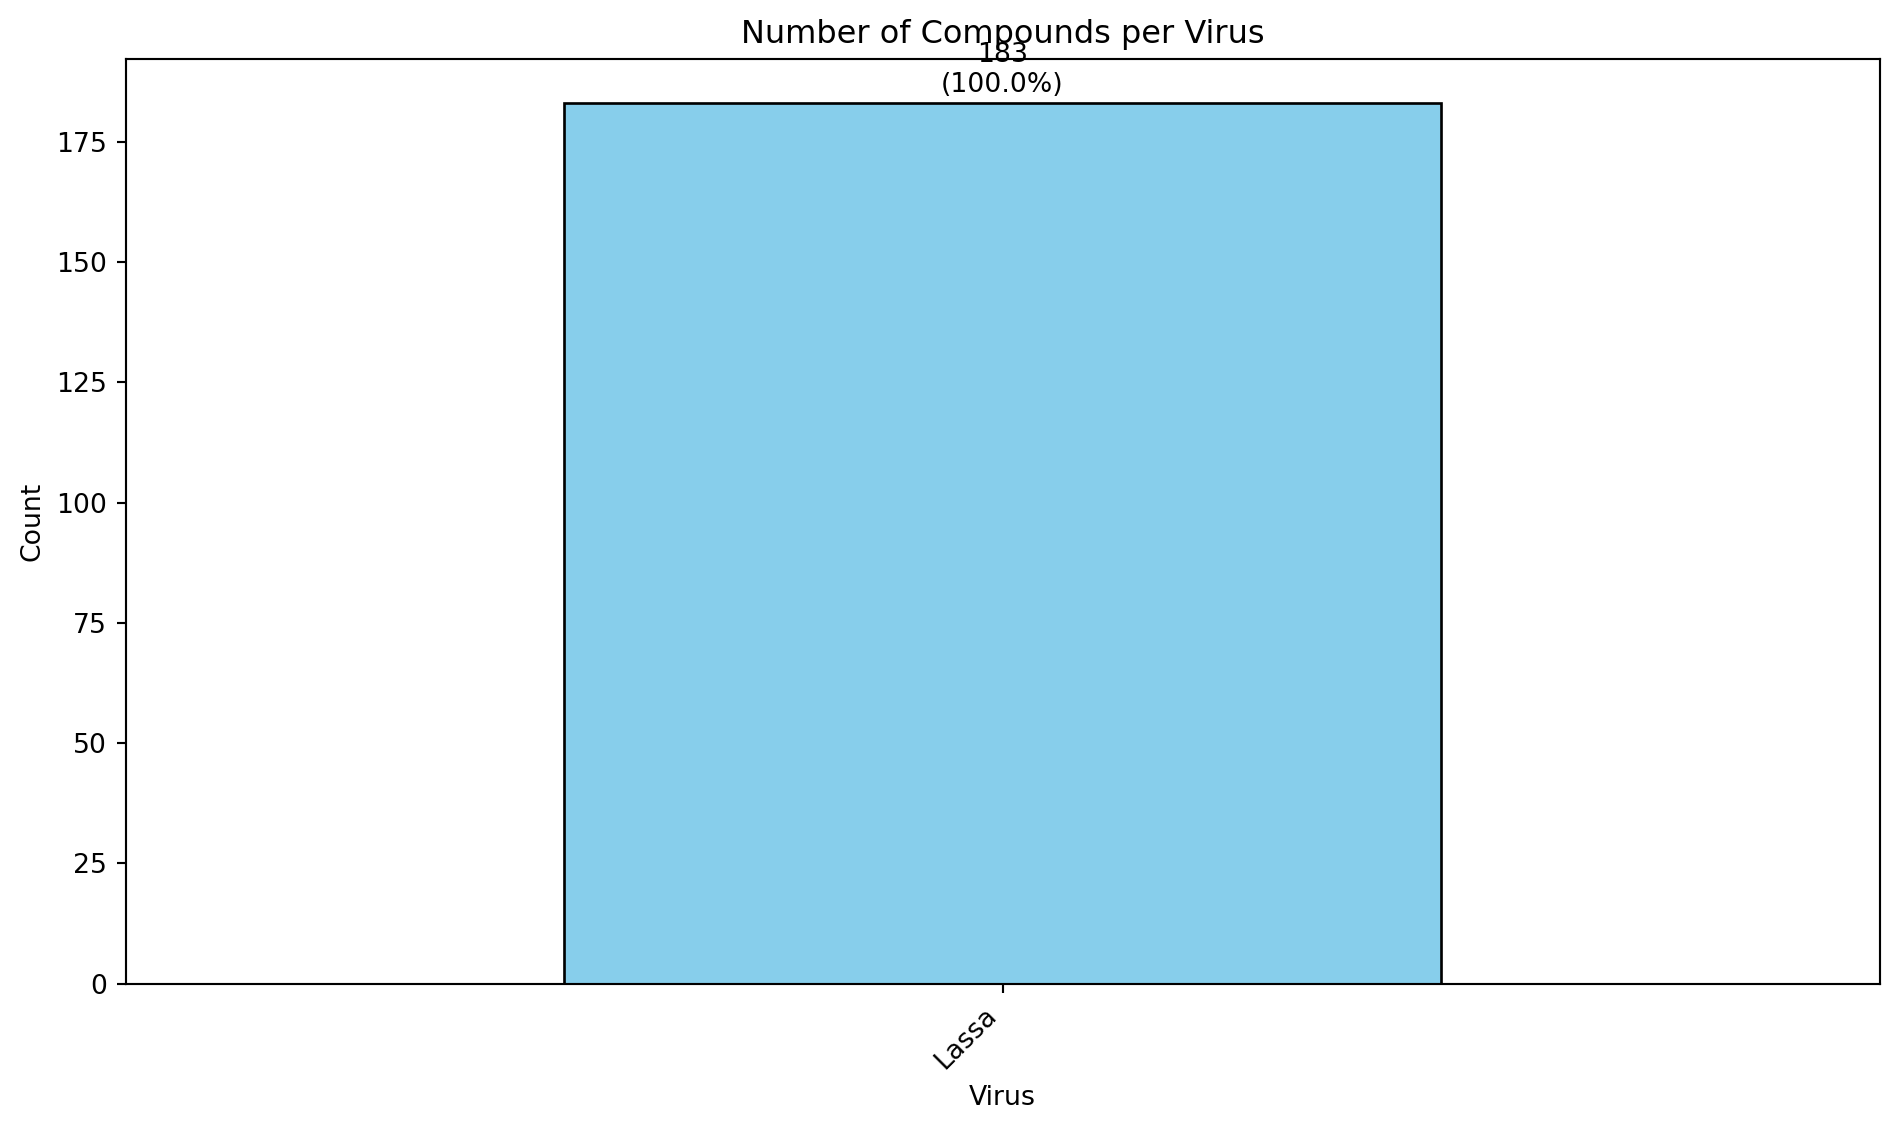

In [207]:
# Get counts and percentages
counts = LassaVirusData_chEMBL_noDuplicates['VirusClassifier'].value_counts()
percentages = counts / counts.sum() * 100

# Create bar plot
plt.figure(figsize=(10, 6))
bars = counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Number of Compounds per Virus')
plt.xlabel('Virus')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Annotate each bar with count and %
for i, (count, pct) in enumerate(zip(counts, percentages)):
    plt.text(
        i, count + 1,                 # position (x, y)
        f'{count}\n({pct:.1f}%)',     # label: count + percentage
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

In [208]:
LassaVirusData_chEMBL_noDuplicates.to_csv(os.path.join(modelBuildingDataDir, "LassaVirusData_chEMBL_noDuplicates_MLready.csv"), index=False)

### pPotency value distribution across each Virus

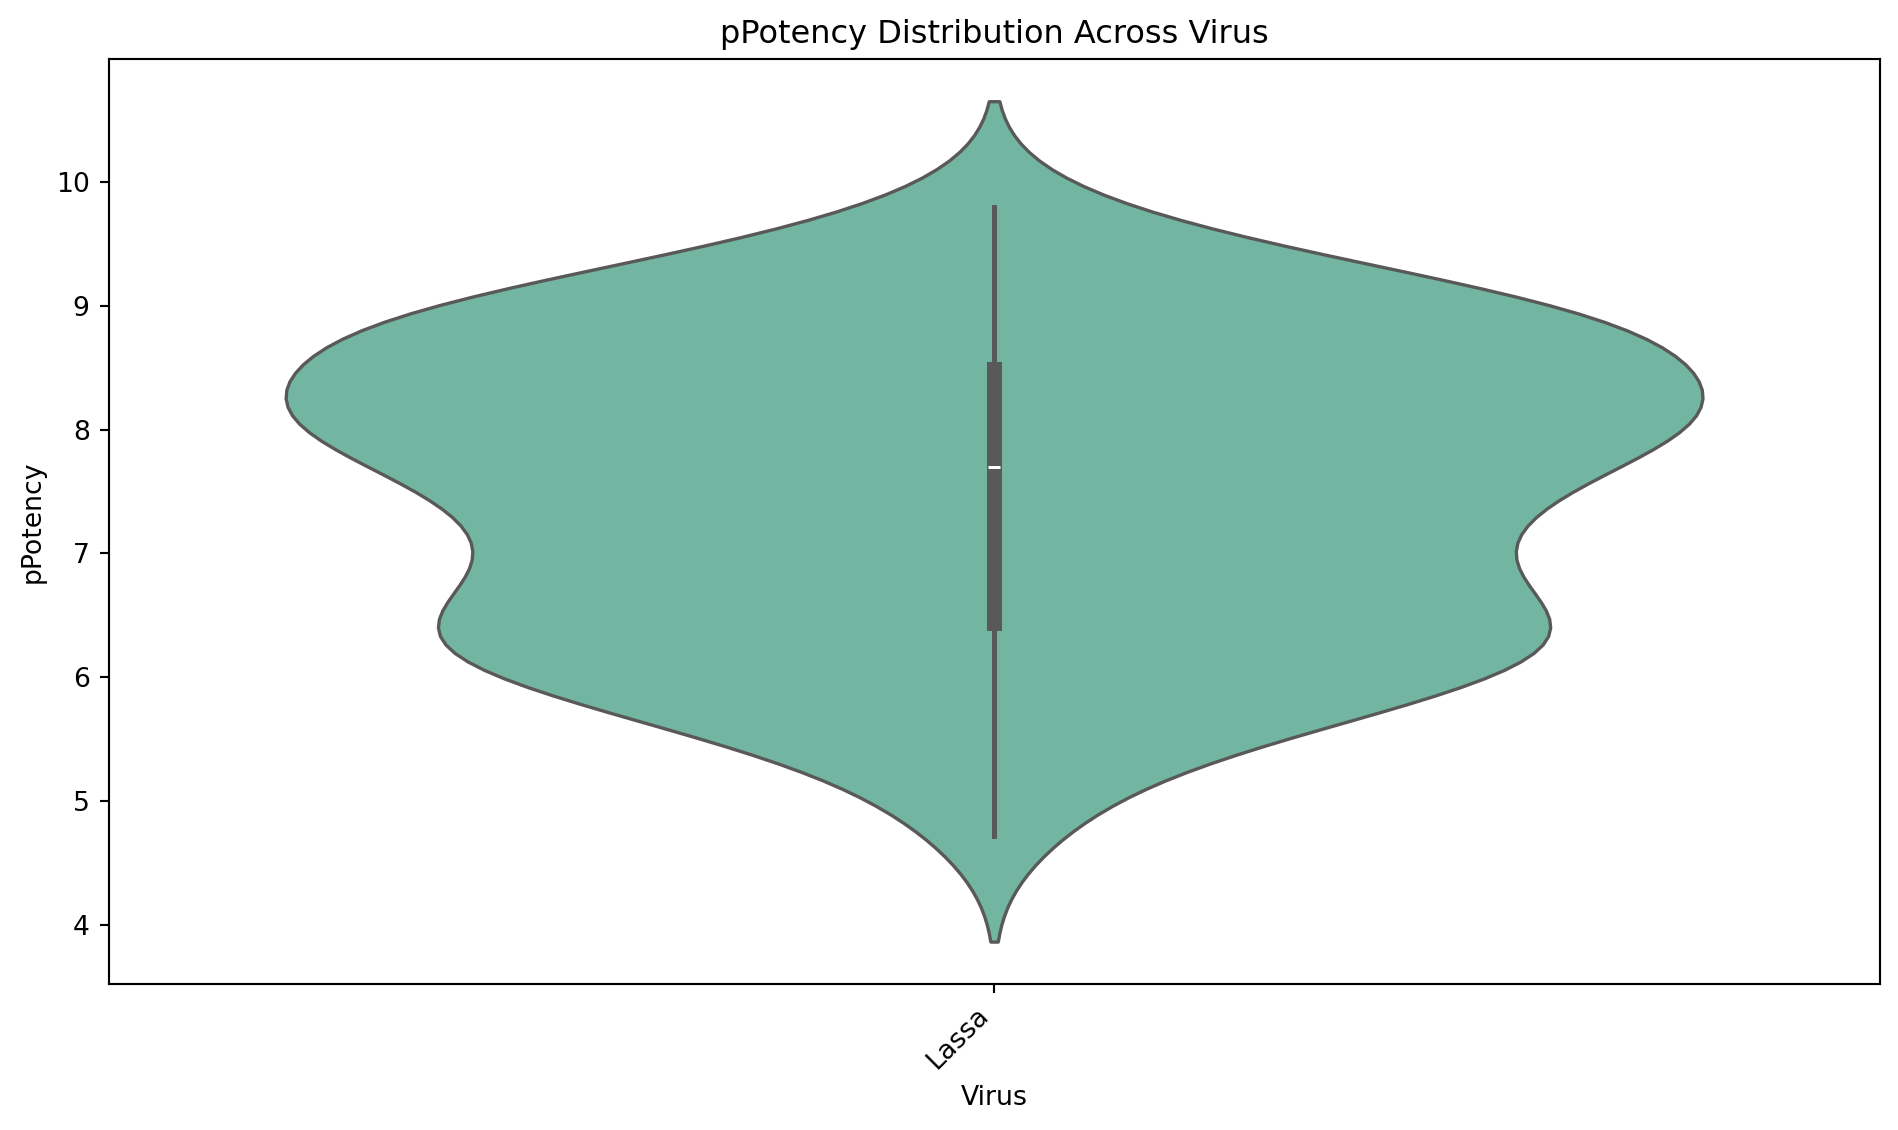

In [209]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=LassaVirusData_chEMBL_noDuplicates,
    x='VirusClassifier',
    y='pPotency',
    palette='Set2',
    inner='box'
)

plt.xticks(rotation=45, ha='right')
plt.title('pPotency Distribution Across Virus')
plt.xlabel('Virus')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

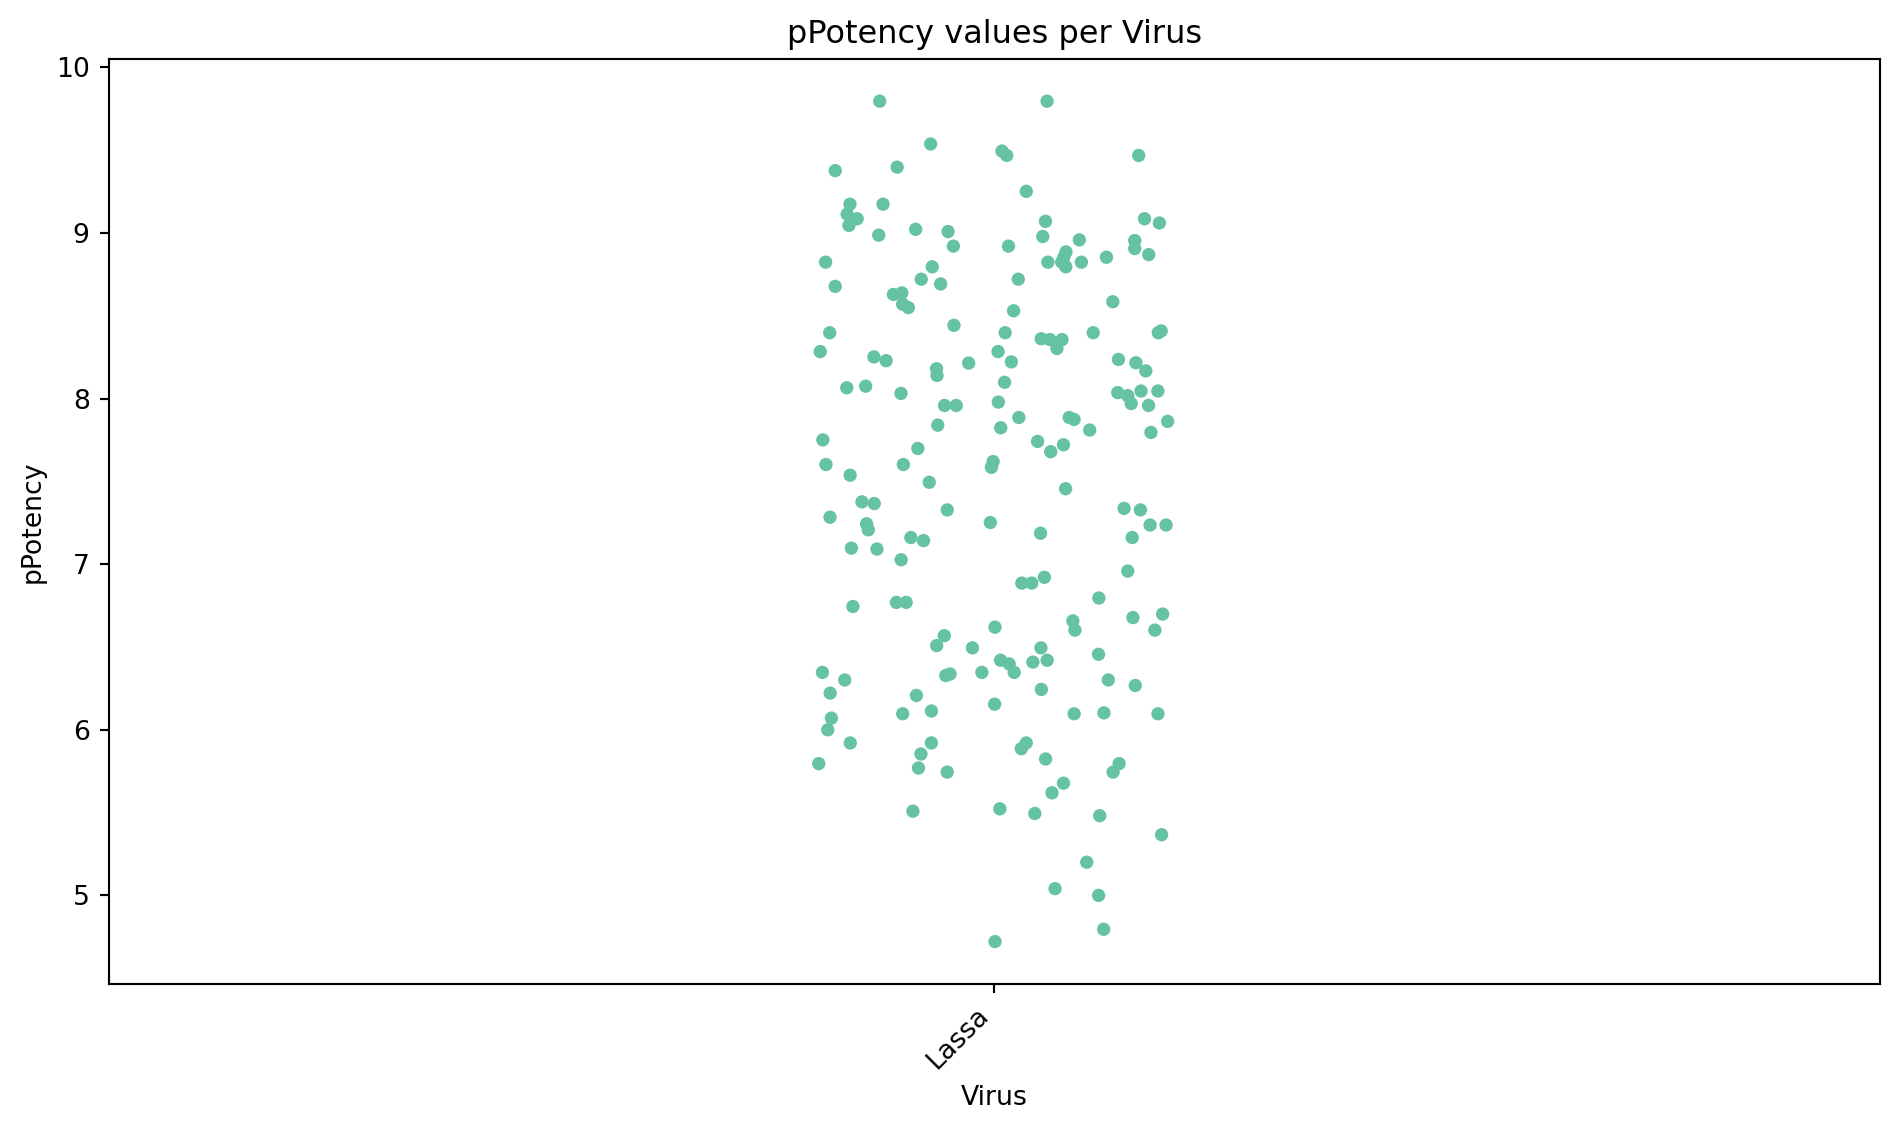

In [210]:
plt.figure(figsize=(10, 6))
sns.stripplot(
    data=LassaVirusData_chEMBL_noDuplicates,
    x='VirusClassifier',
    y='pPotency',
    jitter=True,          # spreads the dots to avoid overlap
    palette='Set2',
    alpha=1
)
plt.xticks(rotation=45, ha='right')
plt.title('pPotency values per Virus')
plt.xlabel('Virus')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

### Create MACAW embeedings to run ART

In [211]:
# ---------------------------
# 1. FIT MACAW AND GENERATE EMBEDDINGS
# ---------------------------
# Initialize MACAW
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=100, 
    random_state=42
)

# Fit MACAW on SMILES and pPotency
mcw.fit(LassaVirusData_chEMBL_noDuplicates['Smiles'], LassaVirusData_chEMBL_noDuplicates['pPotency'])

# Save MACAW transformer
macaw_save_path = os.path.join(modelBuildingDataDir, "LassaVirusData_chEMBL_noDuplicates_MACAW_transformer.joblib")
with open(macaw_save_path, 'wb') as f:
    pickle.dump(mcw, f)
print(f"MACAW transformer saved to: {macaw_save_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(LassaVirusData_chEMBL_noDuplicates['Smiles'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# ---------------------------
# 2. CREATE DATAFRAME WITH EMBEDDINGS
# ---------------------------
# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=LassaVirusData_chEMBL_noDuplicates.index)

# ---------------------------
# 3. CONCATENATE WITH ORIGINAL DATAFRAME
# ---------------------------
LassaVirusData_chEMBL_noDuplicates_wMACAW = pd.concat([LassaVirusData_chEMBL_noDuplicates, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {LassaVirusData_chEMBL_noDuplicates.shape}")
print(f"New dataframe shape: {LassaVirusData_chEMBL_noDuplicates_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
LassaVirusData_chEMBL_noDuplicates_wMACAW.head()

MACAW transformer saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/LassaVirusData_chEMBL_noDuplicates_MACAW_transformer.joblib
MACAW embeddings shape: (183, 15)

Original dataframe shape: (183, 3)
New dataframe shape: (183, 18)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15']


,Smiles,VirusClassifier,pPotency,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,MACAW_9,MACAW_10,MACAW_11,MACAW_12,MACAW_13,MACAW_14,MACAW_15
0,C/C(=N\NC(=O)[C@@H]1C[C@H]1c1ccc(C(C)(C)C)cc1)...,Lassa,8.180456,-0.353515,0.004583,0.140716,0.060699,0.004963,0.099319,-0.291925,0.031673,-0.231556,0.021991,-0.109316,0.106153,-0.095808,-0.068104,0.006299
1,C/C(=N\NC(=O)[C@@H]1C[C@H]1c1ccc(C(C)(C)C)cc1)...,Lassa,7.795880,-0.347759,0.001038,0.119785,0.032016,0.001712,0.077291,-0.281844,0.009622,-0.251016,0.024246,-0.117630,0.090193,-0.052403,-0.075436,0.009524
2,C/C(=N\NC(=O)[C@@H]1C[C@H]1c1ccc(C(C)(C)C)cc1)...,Lassa,6.113509,-0.162057,-0.013693,-0.008059,-0.342304,-0.105968,-0.024243,-0.080438,-0.024002,-0.073701,0.024236,-0.052104,0.042699,0.109687,0.049764,0.080131
3,C/C(=N\NC(=O)[C@@H]1C[C@H]1c1ccc(C(C)(C)C)cc1)...,Lassa,7.823909,-0.360314,-0.015753,0.138847,0.096194,0.013165,0.088129,-0.197216,0.012077,-0.139726,0.039577,-0.091377,0.087520,0.025244,-0.011448,0.011390
4,C/C(=N\NC(=O)[C@@H]1C[C@H]1c1ccccc1)c1ccc(-c2c...,Lassa,8.886057,-0.335451,0.011877,0.141459,-0.058846,-0.039440,-0.076954,0.013294,-0.053089,0.054488,0.053421,-0.071019,0.063480,-0.087780,-0.000953,-0.037775


In [212]:
LassaVirusData_chEMBL_noDuplicates_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "LassaVirusData_chEMBL_noDuplicates_wMACAW.csv"), index=False)

### Clip first 1000 rows from the data set for fast testing

### Train ML Model

In [87]:
# df = LassaVirusData_chEMBL_noDuplicates
Y = LassaVirusData_chEMBL_noDuplicates.pPotency
smiles = LassaVirusData_chEMBL_noDuplicates.Smiles

In [88]:
print(len(smiles))

184


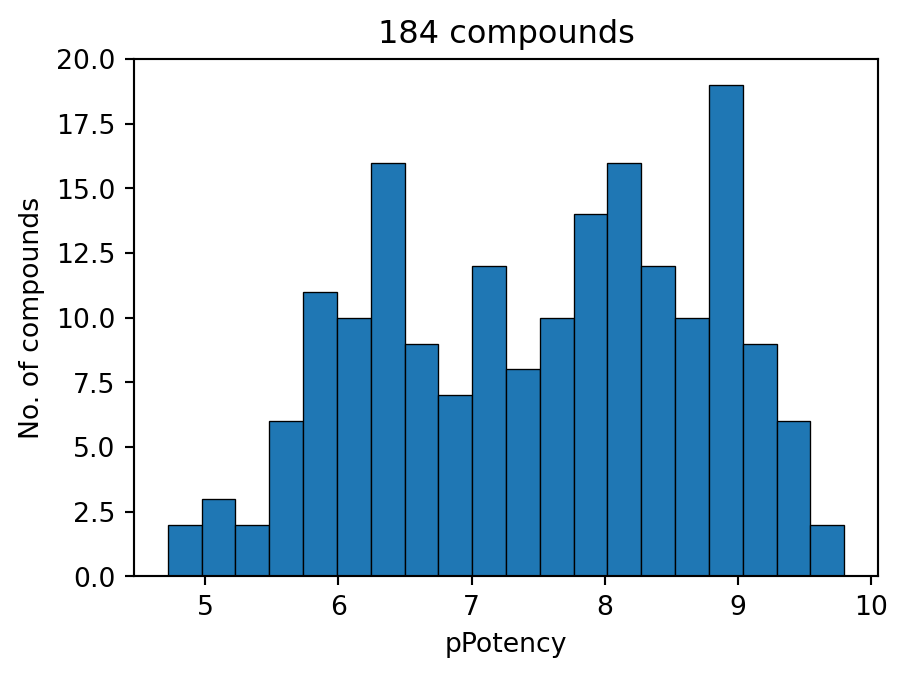

In [89]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [90]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [91]:
param_grid = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500], 
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding:

In [92]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=100, 
    random_state=39
)


After cleaning NaN values, reset the indices

In [93]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True)            

print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

Cleaned data has: 184 samples
Y index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### ML predictions with Train + Test results

In [94]:
%%time
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import Parallel, delayed
from copy import deepcopy

def process_fold(fold_id, train_index, test_index, smiles, Y, mcw, param_grid, num_partitions):
    """Process a single CV fold"""
    print(f"Partition {fold_id}/{num_partitions}")
    
    # Split data
    smi_train = smiles.iloc[train_index]
    smi_test = smiles.iloc[test_index]
    y_train = Y[train_index]
    y_test = Y[test_index]
    
    # Compute MACAW embeddings (clone to avoid conflicts)
    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)
    
    X_train = mcw_fold.transform(smi_train)
    X_test = mcw_fold.transform(smi_test)
    
    # Optimize hyperparameters
    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(X_train, y_train)
    
    best_params = grid.best_params_
    
    # Predict on both train and test
    y_cv_pred_train = grid.predict(X_train)
    y_cv_pred_test = grid.predict(X_test)
    
    # Calculate fold metrics
    train_mae = mean_absolute_error(y_train, y_cv_pred_train)
    test_mae = mean_absolute_error(y_test, y_cv_pred_test)
    print(f"  Fold {fold_id} - Train MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    
    # Return all predictions and parameters
    return {
        'train_pred': y_cv_pred_train,
        'train_obs': y_train,
        'test_pred': y_cv_pred_test,
        'test_obs': y_test,
        'best_params': best_params
    }

# Parallel execution
results = Parallel(n_jobs=4, verbose=10)(
    delayed(process_fold)(
        fold_id=i+1,
        train_index=train_idx,
        test_index=test_idx,
        smiles=smiles,
        Y=Y,
        mcw=mcw,
        param_grid=param_grid,
        num_partitions=num_of_partitions
    )
    for i, (train_idx, test_idx) in enumerate(kf.split(smiles))
)

# Combine results
Y_cv_pred_train = []
Y_obs_train = []
Y_cv_pred_test = []
Y_obs_test = []
best_params_per_fold = []

for fold_result in results:
    Y_cv_pred_train.extend(fold_result['train_pred'])
    Y_obs_train.extend(fold_result['train_obs'])
    Y_cv_pred_test.extend(fold_result['test_pred'])
    Y_obs_test.extend(fold_result['test_obs'])
    best_params_per_fold.append(fold_result['best_params'])

# Convert to numpy arrays
Y_cv_pred_train = np.array(Y_cv_pred_train)
Y_obs_train = np.array(Y_obs_train)
Y_cv_pred_test = np.array(Y_cv_pred_test)
Y_obs_test = np.array(Y_obs_test)

# ===== OVERALL METRICS =====
print("\n" + "-"*40)
print("Cross Validation Metrics")
print("-"*40)

# Train metrics
train_mae = mean_absolute_error(Y_obs_train, Y_cv_pred_train)
train_rmse = np.sqrt(mean_squared_error(Y_obs_train, Y_cv_pred_train))
train_r2 = r2_score(Y_obs_train, Y_cv_pred_train)

print(f"Train Set:")
print(f"  MAE:  {train_mae:.2f}")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  R²:   {train_r2:.2f}")

# Test metrics
test_mae = mean_absolute_error(Y_obs_test, Y_cv_pred_test)
test_rmse = np.sqrt(mean_squared_error(Y_obs_test, Y_cv_pred_test))
test_r2 = r2_score(Y_obs_test, Y_cv_pred_test)

print(f"Test Set:")
print(f"  MAE:  {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  R²:   {test_r2:.2f}")

print(f"\nBest params (sample): {best_params_per_fold[:3]}")


----------------------------------------
Cross Validation Metrics
----------------------------------------
Train Set:
  MAE:  0.57
  RMSE: 0.73
  R²:   0.63
Test Set:
  MAE:  0.67
  RMSE: 0.86
  R²:   0.50

Best params (sample): [{'C': 1, 'epsilon': 0.3, 'kernel': 'rbf'}, {'C': 1, 'epsilon': 0.3, 'kernel': 'rbf'}, {'C': 1, 'epsilon': 1, 'kernel': 'rbf'}]
CPU times: user 64.5 ms, sys: 68.2 ms, total: 133 ms
Wall time: 2.69 s


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Lassavirus/LassaVirus_noDuplicates_CV_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Lassavirus/LassaVirus_noDuplicates_CV_TrTs.png


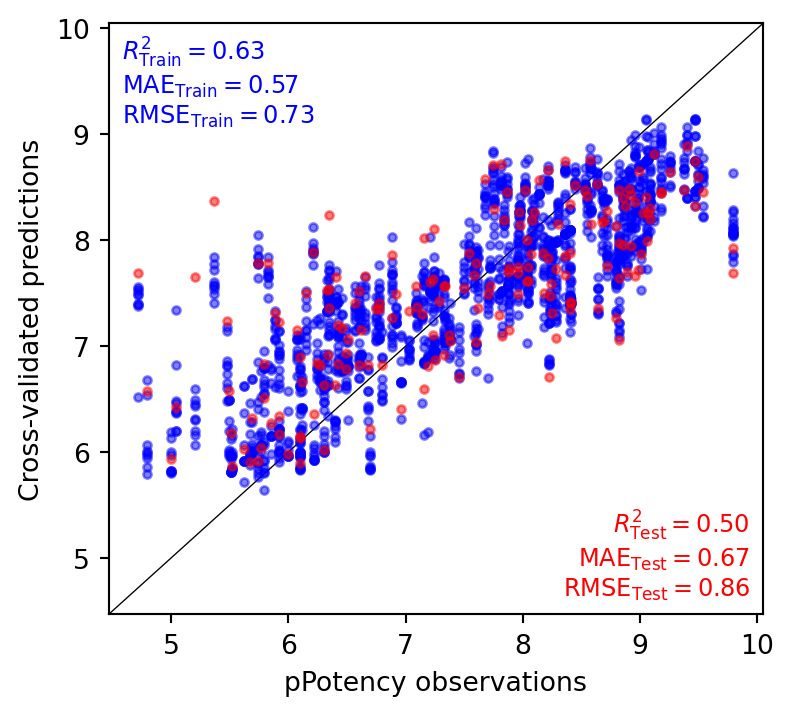

In [95]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=saveDir + '/LassaVirus_noDuplicates_CV_TrTs.svg',
            save_formats=['svg', 'png'])

Generate a model trained on the whole data set, to be used for prediction tasks

In [96]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=100, 
    random_state=39
)
mcw.fit(smiles, Y)

In [97]:
X_all = mcw.transform(smiles)
X_all.shape

(184, 15)

Training samples: 147
Test samples: 37
Feature dimensions: 15

Running GridSearchCV with 4 parallel jobs...

------------------------------------------------------------
Best Hyperparameters:
------------------------------------------------------------
  C: 5
  epsilon: 0.1
  kernel: rbf

Best CV MAE (on training folds): 0.67

------------------------------------------------------------
PERFORMANCE COMPARISON:
------------------------------------------------------------
Metric     Training        Test            Difference     
------------------------------------------------------------
R²         0.75            0.65            0.10           
MAE        0.37            0.56            0.19           
RMSE       0.61            0.69            0.08           
------------------------------------------------------------

Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Lassavirus/LassaVirus_noDuplicates_fullData_TrTs.svg
Saved: /mnt/data.ese/nfs/users/s

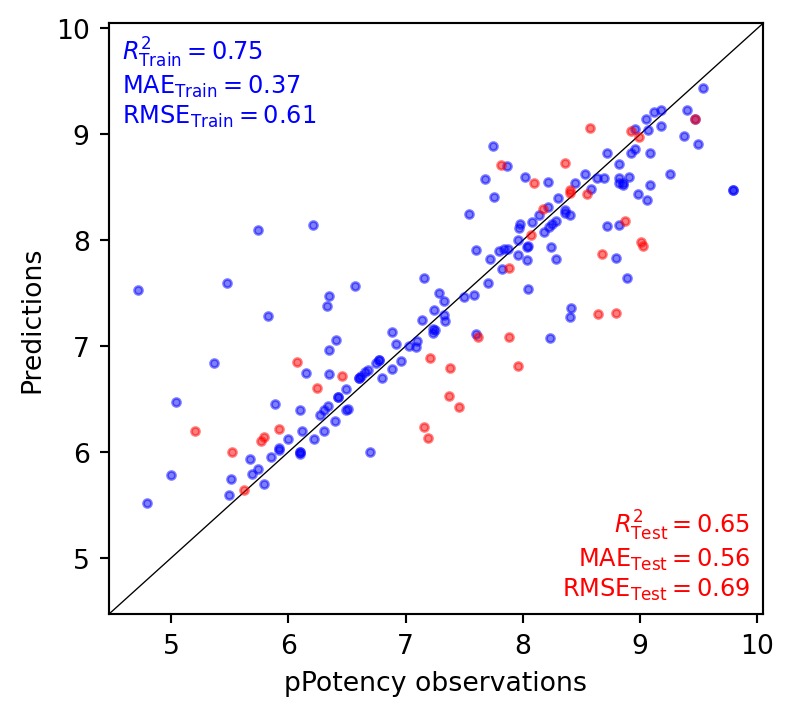

CPU times: user 657 ms, sys: 20.5 ms, total: 678 ms
Wall time: 752 ms


In [98]:
%%time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# ---------------------------
# 1. TRAIN-TEST SPLIT
# ---------------------------
# Since you're working with only one virus group, use regular train_test_split
X_train_smi, X_test_smi, Y_train, Y_test = train_test_split(
    smiles, Y, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print(f"Training samples: {len(X_train_smi)}")
print(f"Test samples: {len(X_test_smi)}")

# ---------------------------
# 2. FIT MACAW ON TRAINING DATA ONLY
# ---------------------------
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=100, 
    random_state=39
)
mcw.fit(X_train_smi, Y_train)

# Transform both train and test
X_train = mcw.transform(X_train_smi)
X_test = mcw.transform(X_test_smi)

print(f"Feature dimensions: {X_train.shape[1]}")

# ---------------------------
# 3. GRID SEARCH ON TRAINING DATA ONLY
# ---------------------------
n_jobs = 4

regr_pred = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    refit=True,
    n_jobs=n_jobs,
    verbose=0,
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    pre_dispatch='2*n_jobs'
)

print(f"\nRunning GridSearchCV with {n_jobs} parallel jobs...")
regr_pred.fit(X_train, Y_train)

# ---------------------------
# 4. DISPLAY BEST HYPERPARAMETERS
# ---------------------------
print("\n" + "-"*60)
print("Best Hyperparameters:")
print("-"*60)
for param, value in regr_pred.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV MAE (on training folds): {-regr_pred.best_score_:.2f}")

# ---------------------------
# 5. PREDICTIONS AND METRICS
# ---------------------------
# Training predictions (in-sample)
y_train_pred = regr_pred.predict(X_train)

# Test predictions (held-out)
y_test_pred = regr_pred.predict(X_test)

# Calculate metrics for TRAIN
train_r2 = r2_score(Y_train, y_train_pred)
train_mae = mean_absolute_error(Y_train, y_train_pred)
train_rmse = np.sqrt(np.mean((Y_train - y_train_pred)**2))

# Calculate metrics for TEST
test_r2 = r2_score(Y_test, y_test_pred)
test_mae = mean_absolute_error(Y_test, y_test_pred)
test_rmse = np.sqrt(np.mean((Y_test - y_test_pred)**2))

# ---------------------------
# 6. DISPLAY RESULTS
# ---------------------------
print("\n" + "-"*60)
print("PERFORMANCE COMPARISON:")
print("-"*60)
print(f"{'Metric':<10} {'Training':<15} {'Test':<15} {'Difference':<15}")
print("-"*60)
print(f"{'R²':<10} {train_r2:<15.2f} {test_r2:<15.2f} {abs(train_r2-test_r2):<15.2f}")
print(f"{'MAE':<10} {train_mae:<15.2f} {test_mae:<15.2f} {abs(train_mae-test_mae):<15.2f}")
print(f"{'RMSE':<10} {train_rmse:<15.2f} {test_rmse:<15.2f} {abs(train_rmse-test_rmse):<15.2f}")
print("-"*60)

# Check for overfitting
overfit_gap = train_r2 - test_r2
if overfit_gap > 0.1:
    print("\n  WARNING: Possible overfitting detected (R² gap > 0.1)")
elif test_r2 >= 0.7:
    print("\n Good generalization performance!")

print("\n" + "="*60)

# ---------------------------
# 7. GENERATE PARITY PLOT
# ---------------------------
parity_plot(
    x=Y_train,                      # observed train
    y=y_train_pred,                 # predicted train (in-sample)
    x_test=Y_test,                  # observed test
    y_test=y_test_pred,             # predicted test (held-out)
    xlabel="pPotency observations",
    ylabel="Predictions",
    savetitle=saveDir + '/LassaVirus_noDuplicates_fullData_TrTs.svg',
    save_formats=['svg', 'png']
)

### Compare performance of different ML model

- SVR
- Random Forest
- XGBoost
- LightGBM
- CatBoost
- Neural Network

Import all necessary libraries

## 2.1 Discovery of new hits specific to all viruses (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [99]:
EnamineAntiviralsData = pd.read_csv(dataDir + "Enamine/Enamine_Antiviral_Library_plated_3200cmpds_20251019.csv",
                                    sep=",", comment=None, skipinitialspace=True, engine="python", encoding="utf-8",          
                                    skiprows=1, skip_blank_lines=True)
print(f"Original Enamine data shape: {EnamineAntiviralsData.shape}")

smiles_train = LassaVirusData_chEMBL.Smiles

# Function to canonicalize SMILES using RDKit
def canonicalize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            return Chem.MolToSmiles(mol, canonical=True)
        else:
            return None
    except:
        return None

# Canonicalize training SMILES and create a set for fast lookup
canonical_train = set()
for smi in smiles_train:
    canonical_smi = canonicalize_smiles(smi)
    if canonical_smi is not None:
        canonical_train.add(canonical_smi)

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to Enamine data
EnamineAntiviralsData['Canonical_SMILES'] = EnamineAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~EnamineAntiviralsData['Canonical_SMILES'].isin(canonical_train)
EnamineAntiviralsData_filtered = EnamineAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
EnamineAntiviralsData = EnamineAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered Enamine data shape for validation: {EnamineAntiviralsData.shape}")
print(f"Removed {EnamineAntiviralsData.shape[0] - EnamineAntiviralsData_filtered.shape[0]} duplicate compounds from Enamine data set")

# Now use the filtered data
smi_lib = EnamineAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
EnamineAntiviralsData.head()

Original Enamine data shape: (3200, 11)
Number of unique SMILES in training set: 184
Filtered Enamine data shape for validation: (3200, 11)
Removed 0 duplicate compounds from Enamine data set
Total compounds to screen: 3200


,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL
0,COCC(C)NC(=O)NC1=NN=C(S1)C2CC2,Z410227912,256.326,256.326,1.231,-2.190,2,4,76.140,5,https://real.enamine.net/public-enum-files/Z41...
1,CN1C(=O)C=CN(CC(=O)NCC2CC2)C1=O,Z383167688,237.256,237.256,-0.042,-0.692,1,3,69.720,5,https://real.enamine.net/public-enum-files/Z38...
2,CCN(CC)CCNC(=O)C1=CC=CN=C1N2CCOCC2,Z235579208,306.404,306.404,1.583,-2.082,1,5,57.700,7,NaN
3,CCC(CNC(=O)CC=1C(C)=NOC1C)N2CCCC2,Z403694008,279.379,279.379,1.156,-0.660,1,3,58.370,7,https://real.enamine.net/public-enum-files/Z40...
4,CCC(C)(CNC(=O)CN1C=CC=CC1=O)N2CCOCC2,Z384461492,307.389,307.389,1.084,-1.180,1,4,61.880,7,https://real.enamine.net/public-enum-files/Z38...


Generate predictions

In [100]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [101]:
EnamineAntiviralsData_predicted = EnamineAntiviralsData.copy()
EnamineAntiviralsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
EnamineAntiviralsData_predicted['pPotency(M)_prediction'] = 10 ** (-EnamineAntiviralsData_predicted['pPotency_prediction'])

EnamineAntiviralsData_predicted = EnamineAntiviralsData_predicted.filter(
    items=["SMILES", "pPotency_prediction",  "pPotency(M)_prediction"]
)
EnamineAntiviralsData_predicted.to_csv(os.path.join(resultsDir + "Lassavirus/Lassavirus_noDuplicates_EnamineDatasets_predicted_all.csv"), index=False)
EnamineAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "Lassavirus/Lassavirus_noDuplicates_EnamineDatasets_predicted_all_SMILES.csv"), index=False)
EnamineAntiviralsData_predicted

,SMILES,pPotency_prediction,pPotency(M)_prediction
0,COCC(C)NC(=O)NC1=NN=C(S1)C2CC2,5.290,5.126e-06
1,CN1C(=O)C=CN(CC(=O)NCC2CC2)C1=O,5.483,3.288e-06
2,CCN(CC)CCNC(=O)C1=CC=CN=C1N2CCOCC2,5.357,4.394e-06
3,CCC(CNC(=O)CC=1C(C)=NOC1C)N2CCCC2,5.282,5.225e-06
4,CCC(C)(CNC(=O)CN1C=CC=CC1=O)N2CCOCC2,5.554,2.792e-06
...,...,...,...
3195,CCOC=1N=CC=CC1NC(=O)NC2CCN3CCCCC23,5.309,4.914e-06
3196,CC1=NN(CC(O)C=2C=CC=CC2)C(=O)C(C#N)=C1C,5.615,2.427e-06
3197,CCC1=NN=NN1CC(=O)NC2CCN(CC2)C(C)=O,5.208,6.201e-06
3198,CC=1C=C2N=CN(CC(O)CN3CCS(=O)CC3)C2=CC1C,5.312,4.878e-06


Let us represent the predictions of both models:

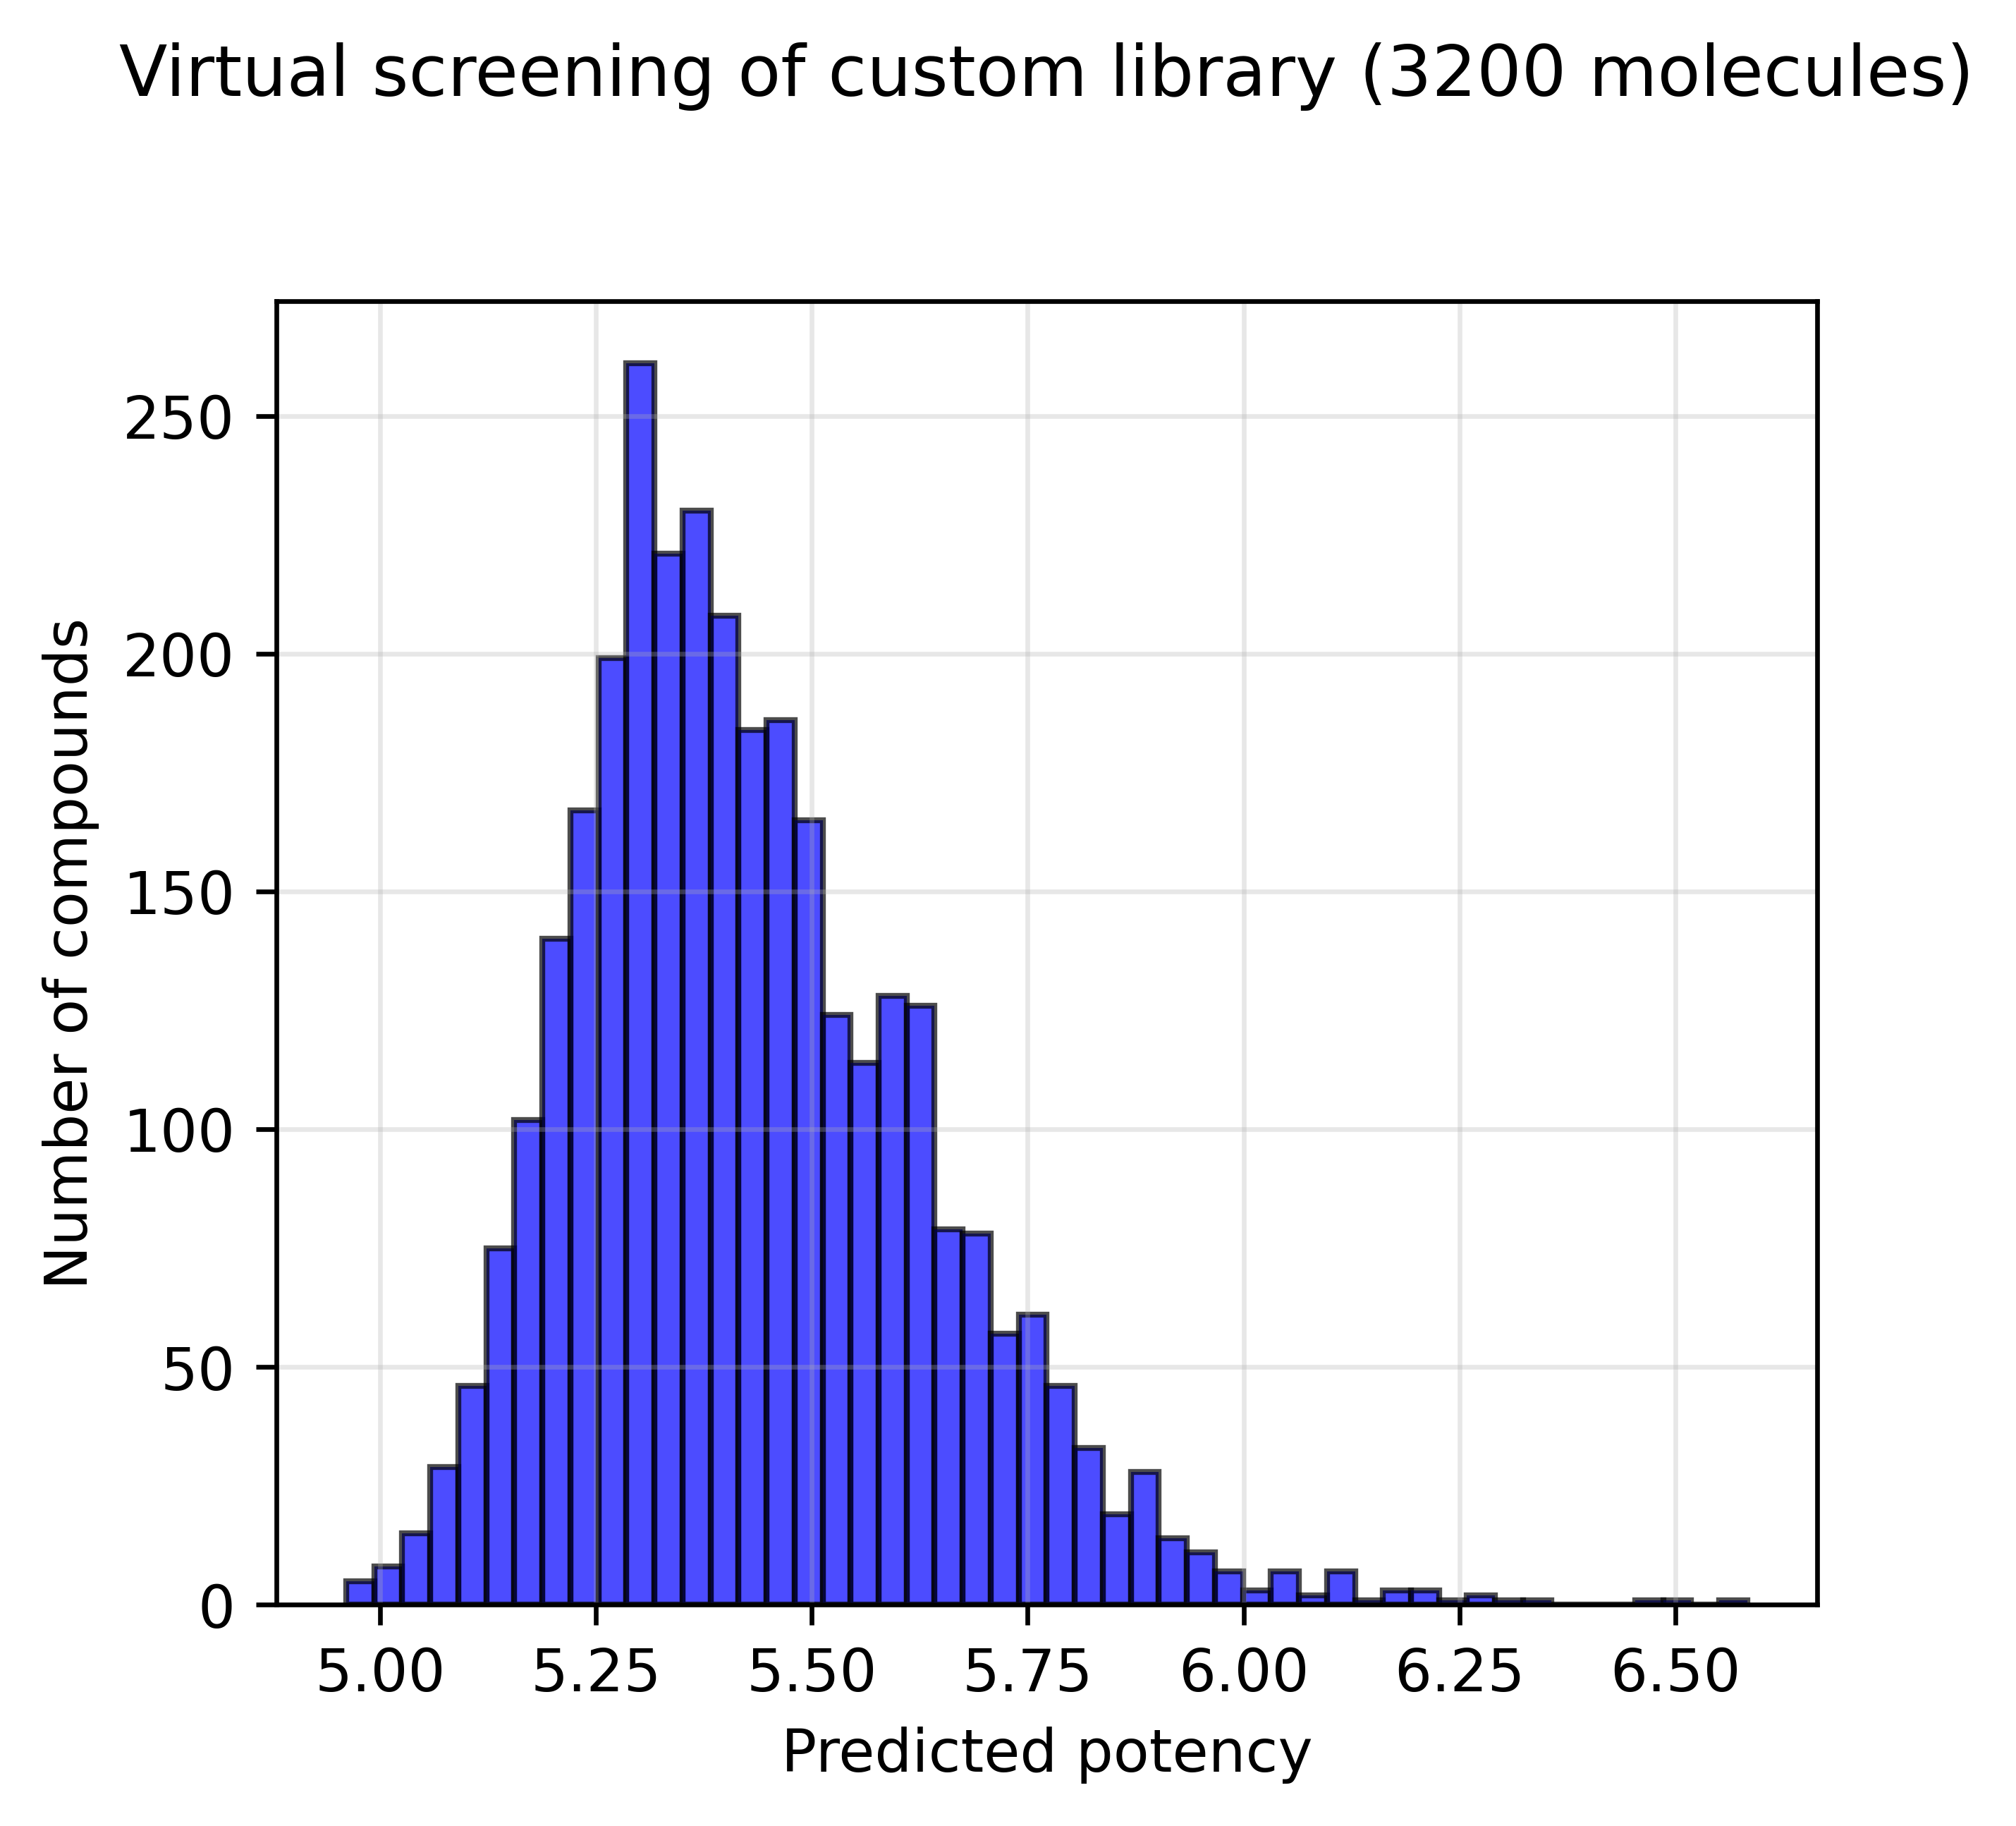

In [102]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2, label='pPotency = 5.0 (minimum)') 
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2, label='pPotency = 6.0 (good)')
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2, label='pPotency = 7.0 (excellent)')

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + '/LassaVirus_noDuplicates_validation.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + '/LassaVirus_noDuplicates_validation.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [103]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 34 compounds
Low priority (5 ≤ pPotency < 6): 3160 compounds


In [104]:
EnamineAntiviralsData_final = EnamineAntiviralsData.iloc[idx].copy()
EnamineAntiviralsData_final['pPotency_prediction'] = Y1_lib_pred[idx]

EnamineAntiviralsData_final

,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL,pPotency_prediction


### Top 20 compounds with higher pPotency

In [105]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 6.11
Highest predicted pPotency: 6.58
Range of top 20: 6.11 - 6.58


In [106]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
EnamineAntiviralsData_top20 = EnamineAntiviralsData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
EnamineAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
EnamineAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
EnamineAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
EnamineAntiviralsData_top20 = EnamineAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
EnamineAntiviralsData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    6.106
  IC50:        7.830e-07 M  (782.96 nM)

Best Values (1st ranked compound):
  pPotency:    6.583
  IC50:        2.610e-07 M  (260.98 nM)
Range for Top 20 Compounds:
pPotency Range:  6.106 - 6.583

IC50 Range (M):  7.830e-07 - 2.610e-07


,Rank,SMILES,pPotency_prediction,IC50 (M)
2539,1,OC(CN1C=NC=2C=CC=CC21)C=3C=CC(=CC3)OC(F)F,6.583,2.610e-07
1236,2,CC(C)C=1C=CC(=CC1)C(O)CN2C(CO)=NC=3C=CC=CC32,6.488,3.251e-07
1604,3,CS(=O)(=O)C=1C=CC(=CC1)C(O)CN2C=NC=3C=CC=CC32,6.474,3.357e-07
1355,4,CC1=NC=2C=CC=CC2N1CC(O)C=3C=CC(=CC3)OC(F)F,6.336,4.609e-07
1606,5,OCC1=NC=2C=CC=CC2N1CC(O)C=3C=CC(=CC3)C(F)(F)F,6.311,4.888e-07
915,6,OCC1=NC=2C=CC=CC2N1CC(O)C=3C=CC=CC3,6.266,5.417e-07
1156,7,COC=1C=CC(OC)=C(C1)C(O)CN2C=NC=3C=CC=CC32,6.261,5.478e-07
980,8,OCC1=NC=2C=CC=CC2N1CC(O)C=3C=CC(=CC3)OC(F)F,6.235,5.826e-07
513,9,NC(=O)CC1=NC=2C=CC=CC2N1CC(O)C=3C=CC=CC3,6.205,6.238e-07
2499,10,COC=1C=CC(=CC1)CC2=NC=3C=CC=CC3N2CC(O)CO,6.204,6.258e-07


In [107]:
EnamineAntiviralsData_top20.to_csv(os.path.join(resultsDir + "Lassavirus/Lassavirus_noDuplicates_EnamineAntiviralsData_top20.csv"), index=False)
EnamineAntiviralsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "Lassavirus/Lassavirus_noDuplicates_EnamineAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Lassavirus/LassaVirus_noDuplicates_predictedCompounds.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Lassavirus/LassaVirus_noDuplicates_predictedCompounds.svg


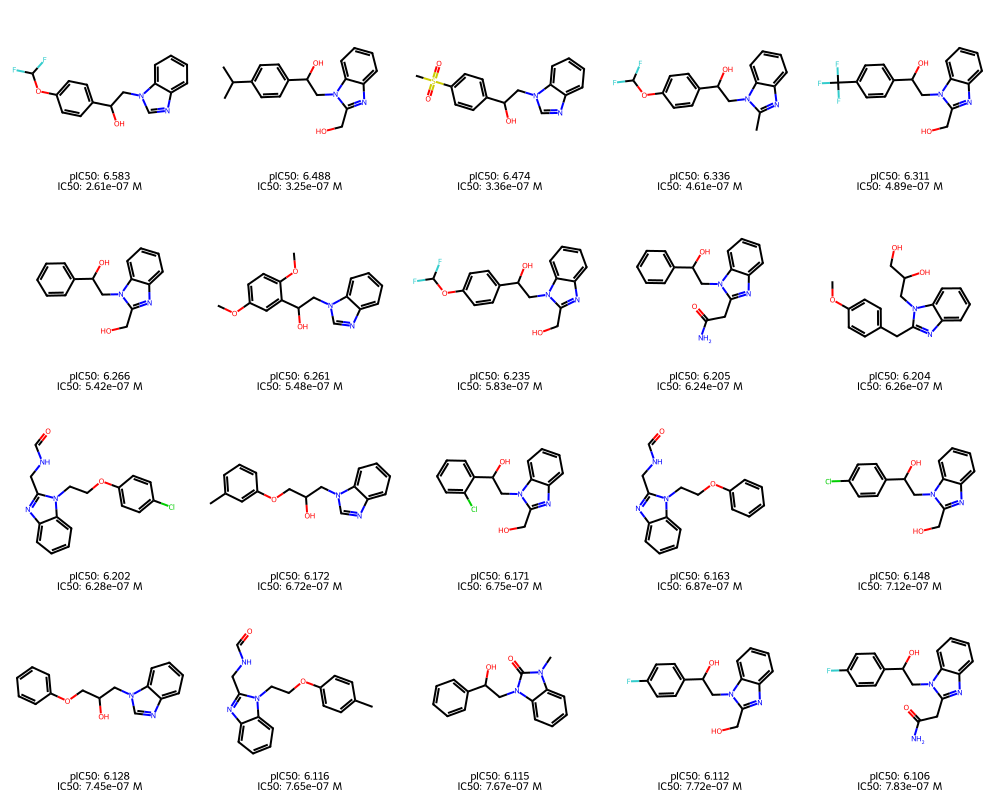

In [108]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = saveDir + '/'
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in EnamineAntiviralsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'LassaVirus_noDuplicates_predictedCompounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'LassaVirus_noDuplicates_predictedCompounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

## 2.2 Discovery of new hits specific to all viruses (data source Life chemicals data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [109]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "LifeChemicals/LC_Merged_Antiviral_Screening_Superset.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

LCAntiviralsData_superset = pd.DataFrame(records)
print(f"Original LifeChemicals data shape: {LCAntiviralsData_superset.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to LifeChemicals data (reusing canonical_train from code-1)
LCAntiviralsData_superset['Canonical_SMILES'] = LCAntiviralsData_superset['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~LCAntiviralsData_superset['Canonical_SMILES'].isin(canonical_train)
LCAntiviralsData_superset_filtered = LCAntiviralsData_superset[mask].copy()

# Remove the helper column if you don't need it
LCAntiviralsData_superset = LCAntiviralsData_superset_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered LifeChemicals data shape for validation: {LCAntiviralsData_superset.shape}")
print(f"Removed {LCAntiviralsData_superset_filtered.shape[0] - LCAntiviralsData_superset.shape[0]} duplicate compounds from LifeChemicals data set")

# Now use the filtered data
smi_lib = LCAntiviralsData_superset.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
LCAntiviralsData_superset.head()

Original LifeChemicals data shape: (45573, 17)
Number of unique SMILES in training set: 184
Filtered LifeChemicals data shape for validation: (45573, 17)
Removed 0 duplicate compounds from LifeChemicals data set
Total compounds to screen: 45573


,IDNUMBER,Chemical_Name,CAS,PriceCoeff,MW,Description,FSP3,clogP,TPSA,Acceptor,Donor,RotBonds,HAC,Collection,Library,PPDS,SMILES
0,F6544-0534,"11-(oxan-4-yl)-7,11-diazatricyclo[7.3.1.0²,⁷]t...",2034607-75-3,1.500,274.360,solid,0.690,-0.120,32.780,2,1,1,20.000,Advanced,Anti-Hepatitis_A_B_ Screening_Library,,Cl.O=c1cccc2n1CC1CC2CN(C2CCOCC2)C1
1,F6559-5304,6-[4-(trifluoromethyl)pyrimidin-2-yl]-6-azaspi...,2034225-11-9,1.500,301.260,solid,0.620,2.030,66.320,4,1,2,21.000,Advanced,2019-nCoV_Main_Protease_Targeted_Library,+,O=C(O)C1CN(c2nccc(C(F)(F)F)n2)CC12CCC2
2,F6610-6619,"1-methyl-4-[(pyridin-4-yl)methyl]-1,4-diazepane",2320860-02-2,1.000,205.300,oil,0.580,0.890,19.370,3,3,2,15.000,General,Anti-HIV_Focused_Library,,CN1CCCN(Cc2ccncc2)CC1
3,F6559-5274,"6-(4,6-dimethylpyrimidin-2-yl)-6-azaspiro[3.4]...",2034225-08-4,1.500,261.320,oil,0.640,2.090,66.320,4,1,2,19.000,Advanced,Antiviral_Screening_Compound_Library_2D_Simila...,,Cc1cc(C)nc(N2CC(C(=O)O)C3(CCC3)C2)n1
4,F1912-1536,N-cyclopropyl-N-(piperidin-4-yl)pyrimidin-4-amine,1781768-10-2,1.500,218.290,solid,0.670,0.790,41.050,2,2,3,16.000,Advanced,Antiviral_Screening_Compound_Library_2D_Simila...,,c1cc(N(C2CCNCC2)C2CC2)ncn1


Generate predictions for the H1 receptor:

In [110]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [111]:
LCAntiviralsData_predicted = LCAntiviralsData_superset.copy()
LCAntiviralsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
LCAntiviralsData_predicted['pPotency(M)_prediction'] = 10 ** (-LCAntiviralsData_predicted['pPotency_prediction'])

LCAntiviralsData_predicted = LCAntiviralsData_predicted.filter(
    items=["SMILES", "pPotency_prediction",  "pPotency(M)_prediction"]
)
LCAntiviralsData_predicted.to_csv(os.path.join(resultsDir + "Lassavirus/Lassavirus_noDuplicates_LCDatasets_predicted_all.csv"), index=False)
LCAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "Lassavirus/Lassavirus_noDuplicates_LCDatasets_predicted_all_SMILES.csv"), index=False)
LCAntiviralsData_predicted

,SMILES,pPotency_prediction,pPotency(M)_prediction
0,Cl.O=c1cccc2n1CC1CC2CN(C2CCOCC2)C1,5.291,5.117e-06
1,O=C(O)C1CN(c2nccc(C(F)(F)F)n2)CC12CCC2,5.501,3.153e-06
2,CN1CCCN(Cc2ccncc2)CC1,5.541,2.879e-06
3,Cc1cc(C)nc(N2CC(C(=O)O)C3(CCC3)C2)n1,5.306,4.946e-06
4,c1cc(N(C2CCNCC2)C2CC2)ncn1,5.355,4.416e-06
...,...,...,...
45568,CCN1C=C/C(=C\C=C\c2cc[n+](CC)c3ccccc23)c2ccccc...,6.155,7.005e-07
45569,CCCN1/C(=C/C=C/c2sc3ccccc3[n+]2CCC)Sc2ccccc21....,5.583,2.614e-06
45570,COC(=O)c1ccccc1-c1c2ccc(=N)cc-2oc2cc(N)ccc12.Cl,5.550,2.818e-06
45571,CCN1/C(=C/C=C2\CCC(/C=C/c3sc4ccc(Cl)cc4[n+]3CC...,5.187,6.499e-06


Let us represent the predictions of both models:

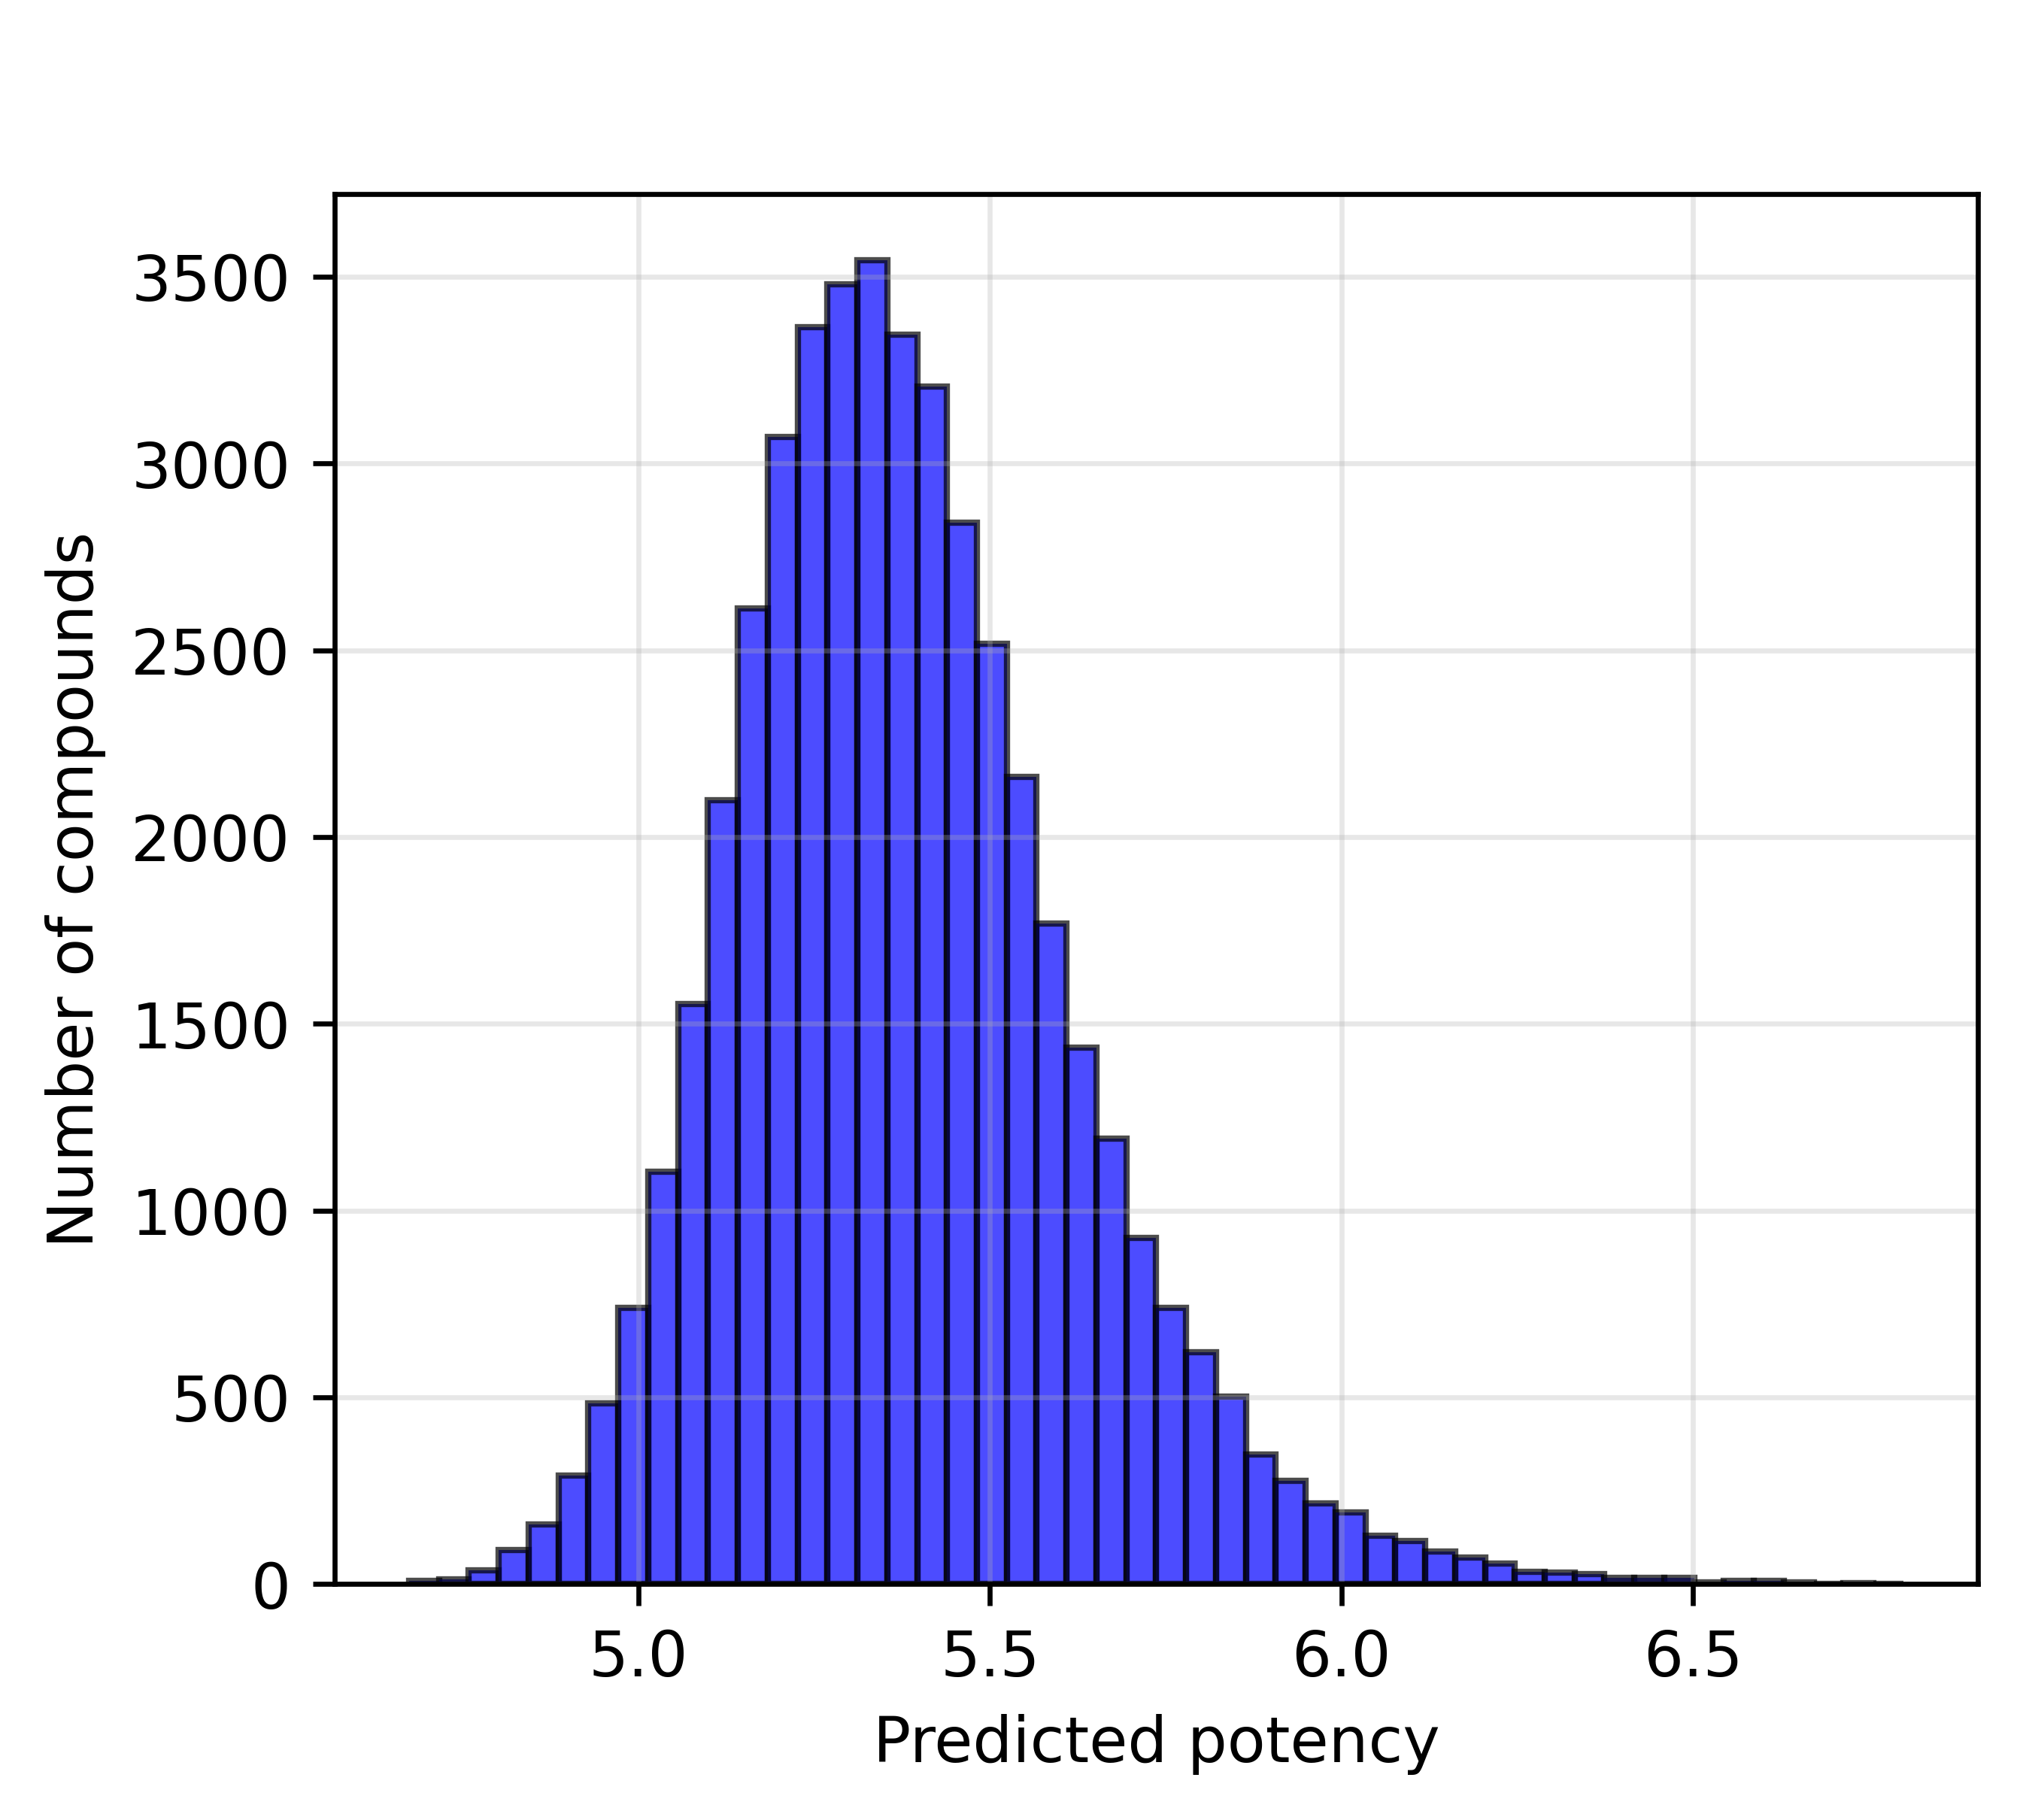

In [112]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + '/LassaVirus_validation_noDuplicates_LCDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + '/LassaVirus_validation_noDuplicates_LCDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [113]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7.0)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 773 compounds
Low priority (5 ≤ pPotency < 6): 43235 compounds


In [114]:
LCAntiviralsData_superset_final = LCAntiviralsData_superset.iloc[idx].copy()
LCAntiviralsData_superset_final['pPotency_prediction'] = Y1_lib_pred[idx]
LCAntiviralsData_superset_final = LCAntiviralsData_superset_final.filter(
    items=["SMILES", "pPotency_prediction", "clogP"]
)
LCAntiviralsData_superset_final

,SMILES,pPotency_prediction,clogP


### Top 20 compounds with higher PpPotency

In [115]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 6.57
Highest predicted pPotency: 6.80
Range of top 20: 6.57 - 6.80


In [116]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
LCAntiviralsData_top20 = LCAntiviralsData_superset.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
LCAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
LCAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
LCAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
LCAntiviralsData_top20 = LCAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
LCAntiviralsData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    6.572
  IC50:        2.677e-07 M  (267.67 nM)

Best Values (1st ranked compound):
  pPotency:    6.799
  IC50:        1.588e-07 M  (158.76 nM)
Range for Top 20 Compounds:
pPotency Range:  6.572 - 6.799

IC50 Range (M):  2.677e-07 - 1.588e-07


,Rank,SMILES,pPotency_prediction,IC50 (M)
36159,1,CC(C)(C)c1ccc(OCc2nc3ccccc3n2CCc2ccccc2)cc1,6.799,1.588e-07
39903,2,CCCCOc1ccc(-c2nc(-c3ccccc3)c3ccccn23)cc1,6.747,1.791e-07
43118,3,COc1ccc(-n2cc(-c3ccccc3)c3c(S)ncnc32)cc1,6.725,1.885e-07
43176,4,COc1ccccc1-n1cc(-c2ccccc2)c2c(S)ncnc21,6.710,1.951e-07
43181,5,COc1ccccc1C(=O)/C=C/c1cn(-c2ccccc2)nc1-c1ccccc1,6.656,2.210e-07
35931,6,c1ccc(-c2cc(-c3ccccc3)n(-c3ccccc3)n2)cc1,6.654,2.217e-07
6603,7,COc1ccc(-c2cn3ccccc3n2)cc1,6.648,2.249e-07
27741,8,Cn1c(-c2ccccc2)cnc1SCc1ccc(C(F)(F)F)cc1,6.630,2.345e-07
14725,9,COc1ccc(C2C=C(c3ccc(C)cc3)Nc3ncnn32)cc1,6.611,2.448e-07
31388,10,COc1ccccc1-n1cc(-c2ccccc2)c2c(SC)ncnc21,6.611,2.449e-07


In [117]:
LCAntiviralsData_top20.to_csv(os.path.join(resultsDir + "Lassavirus/Lassavirus_noDuplicates_LCAntiviralsData_top20.csv"), index=False)
LCAntiviralsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "Lassavirus/Lassavirus_noDuplicates_LCAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Lassavirus/LassaVirus_predictedCompounds_noDuplicates_LCDataset.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Lassavirus/LassaVirus_predictedCompounds_noDuplicates_LCDataset.svg


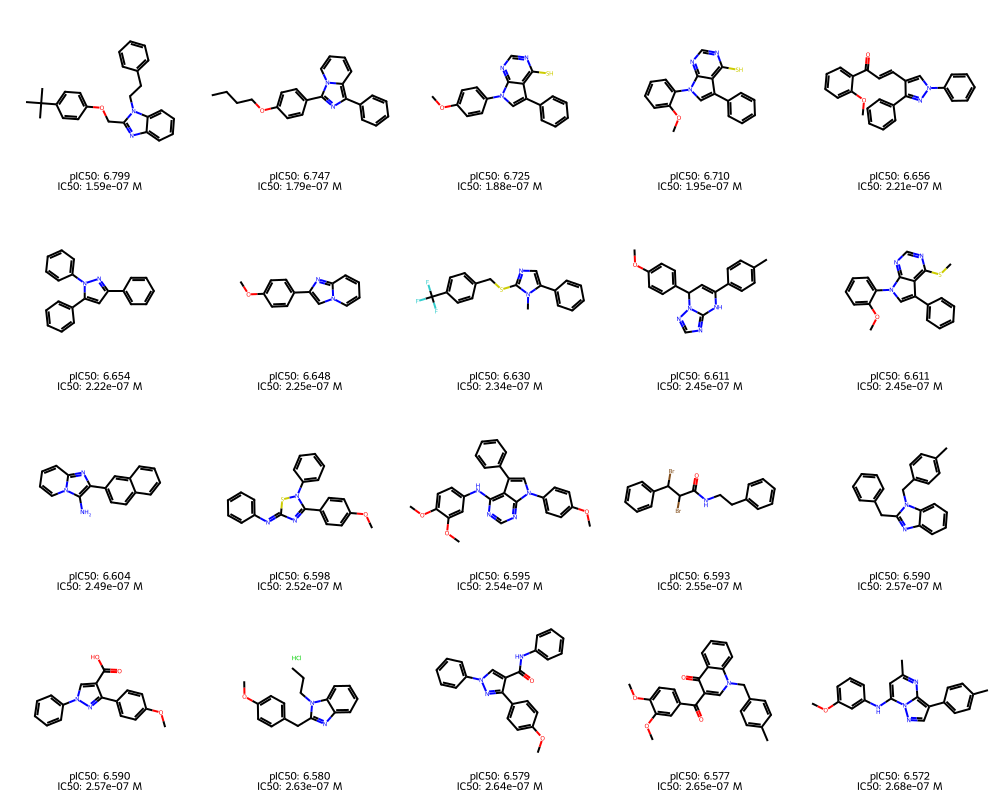

In [118]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = saveDir + '/'
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in LCAntiviralsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in LCAntiviralsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'LassaVirus_predictedCompounds_noDuplicates_LCDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'LassaVirus_predictedCompounds_noDuplicates_LCDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

## 2.3 Discovery of new hits specific to all viruses (data source `chemDiv` data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [119]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "ChemDiv/ChemDiv_Antiviral-Library-64958.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

ChemDivAntiviralsData = pd.DataFrame(records)
print(f"Original ChemDiv data shape: {ChemDivAntiviralsData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to ChemDiv data (reusing canonical_train from previous code)
ChemDivAntiviralsData['Canonical_SMILES'] = ChemDivAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~ChemDivAntiviralsData['Canonical_SMILES'].isin(canonical_train)
ChemDivAntiviralsData_filtered = ChemDivAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
ChemDivAntiviralsData = ChemDivAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered ChemDiv data shape for validation: {ChemDivAntiviralsData.shape}")
print(f"Removed {ChemDivAntiviralsData_filtered.shape[0] - ChemDivAntiviralsData.shape[0]} duplicate compounds from ChemDiv data set")

# Now use the filtered data
smi_lib = ChemDivAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
ChemDivAntiviralsData

Original ChemDiv data shape: (64958, 28)
Number of unique SMILES in training set: 184
Filtered ChemDiv data shape for validation: (64957, 28)
Removed 0 duplicate compounds from ChemDiv data set
Total compounds to screen: 64957


,IDNUMBER,available,H_acceptor,H_donor,B_rotN,N_O,logP,logD,logSw,PSA,...,InChI Key,PERCENTSP3,Link,CLNUMBER,Saltdata,Saltdata_MW,STEREO,State,SMILES,CAS
0,E676-1193,55,6,0,10,6.000,4.584,3.825,-4.736,44.193,...,CADSCKHSUSMLDE-UHFFFAOYSA-N,33.300,https://www.chemdiv.com/catalog/screening-comp...,CL4971B,HCl,36.461,ACHIRAL,Solid,CCOc1cccc2sc(N(CCN(C)C)C(=O)COc3ccc(Cl)cc3)nc12,NaN
1,E676-4289,2,8,0,9,7.000,2.084,1.279,-2.867,59.381,...,GBCBRISSOXAFMF-UHFFFAOYSA-N,47.400,https://www.chemdiv.com/catalog/screening-comp...,CL4971B,HCl,36.461,ACHIRAL,Solid,CCN(CC)CCN(C(=O)CN1C(=O)CCC1=O)c1nc2c(Cl)cccc2s1,NaN
2,E676-2516,15,7,0,7,7.000,4.274,3.444,-4.355,53.078,...,LSLRIDUYGBBIBR-SFHVURJKSA-N,36.400,https://www.chemdiv.com/catalog/screening-comp...,CL4971B,HCl,36.461,RACEMIC MIXTURE,Solid,COc1ccc(C)c2sc(N(CCN(C)C)C(=O)C3COc4ccccc4O3)nc12,NaN
3,F735-0482,21,7,2,9,7.000,3.231,3.225,-3.423,79.491,...,NBFDETMKPOQYSJ-UHFFFAOYSA-N,22.200,https://www.chemdiv.com/catalog/screening-comp...,CL8286,NaN,NaN,ACHIRAL,Solid,CCCc1nnc(C(=O)Nc2ccc(C(=O)NCc3ccco3)cc2)s1,NaN
4,G211-0195,304,5,1,5,5.000,5.054,5.054,-5.469,49.877,...,DRPXIGZHBISZAU-UHFFFAOYSA-N,32.000,https://www.chemdiv.com/catalog/screening-comp...,CL6036,NaN,NaN,ACHIRAL,Solid,O=C(NCc1cccc(Cl)c1)c1c2c(nc3ccccc13)C(=O)N(C1C...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64953,8010-2606,54,8,1,9,8.000,6.685,3.100,-6.678,70.818,...,ZQXAXHNEVALOJP-UHFFFAOYSA-N,30.800,https://www.chemdiv.com/catalog/screening-comp...,CL1650,NaN,NaN,ACHIRAL,Solid,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,NaN
64954,2774-1508,1,7,1,8,7.000,6.551,3.884,-5.738,62.323,...,KDXCUTJRVPCZKK-UHFFFAOYSA-N,25.000,https://www.chemdiv.com/catalog/screening-comp...,CL1652,NaN,NaN,ACHIRAL,Solid,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,NaN
64955,K061-0539,124,7,1,7,7.000,6.014,2.429,-5.464,64.713,...,XEIANUQFWJNADZ-UHFFFAOYSA-N,27.300,https://www.chemdiv.com/catalog/screening-comp...,CL1647,NaN,NaN,ACHIRAL,Solid,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,NaN
64956,K061-0894,165,6,1,7,7.000,6.905,6.387,-6.761,57.369,...,IBXAKUXFQPUZBE-UHFFFAOYSA-N,13.600,https://www.chemdiv.com/catalog/screening-comp...,CL1650,NaN,NaN,ACHIRAL,Solid,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,NaN


Generate predictions for the H1 receptor:

In [120]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

50000


In [121]:
ChemDivAntiviralsData_predicted = ChemDivAntiviralsData.copy()
ChemDivAntiviralsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
ChemDivAntiviralsData_predicted['pPotency(M)_prediction'] = 10 ** (-ChemDivAntiviralsData_predicted['pPotency_prediction'])

ChemDivAntiviralsData_predicted = ChemDivAntiviralsData_predicted.filter(
    items=["SMILES", "pPotency_prediction",  "pPotency(M)_prediction"]
)
ChemDivAntiviralsData_predicted.to_csv(os.path.join(resultsDir + "Lassavirus/Lassavirus_noDuplicates_ChemDivDatasets_predicted_all.csv"), index=False)
ChemDivAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "Lassavirus/Lassavirus_noDuplicates_ChemDivDatasets_predicted_all_SMILES.csv"), index=False)
ChemDivAntiviralsData_predicted

,SMILES,pPotency_prediction,pPotency(M)_prediction
0,CCOc1cccc2sc(N(CCN(C)C)C(=O)COc3ccc(Cl)cc3)nc12,5.332,4.660e-06
1,CCN(CC)CCN(C(=O)CN1C(=O)CCC1=O)c1nc2c(Cl)cccc2s1,5.317,4.817e-06
2,COc1ccc(C)c2sc(N(CCN(C)C)C(=O)C3COc4ccccc4O3)nc12,5.156,6.987e-06
3,CCCc1nnc(C(=O)Nc2ccc(C(=O)NCc3ccco3)cc2)s1,5.090,8.133e-06
4,O=C(NCc1cccc(Cl)c1)c1c2c(nc3ccccc13)C(=O)N(C1C...,5.368,4.288e-06
...,...,...,...
64953,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,5.131,7.398e-06
64954,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,5.126,7.489e-06
64955,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,5.157,6.965e-06
64956,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,5.452,3.531e-06


Let us represent the predictions of both models:

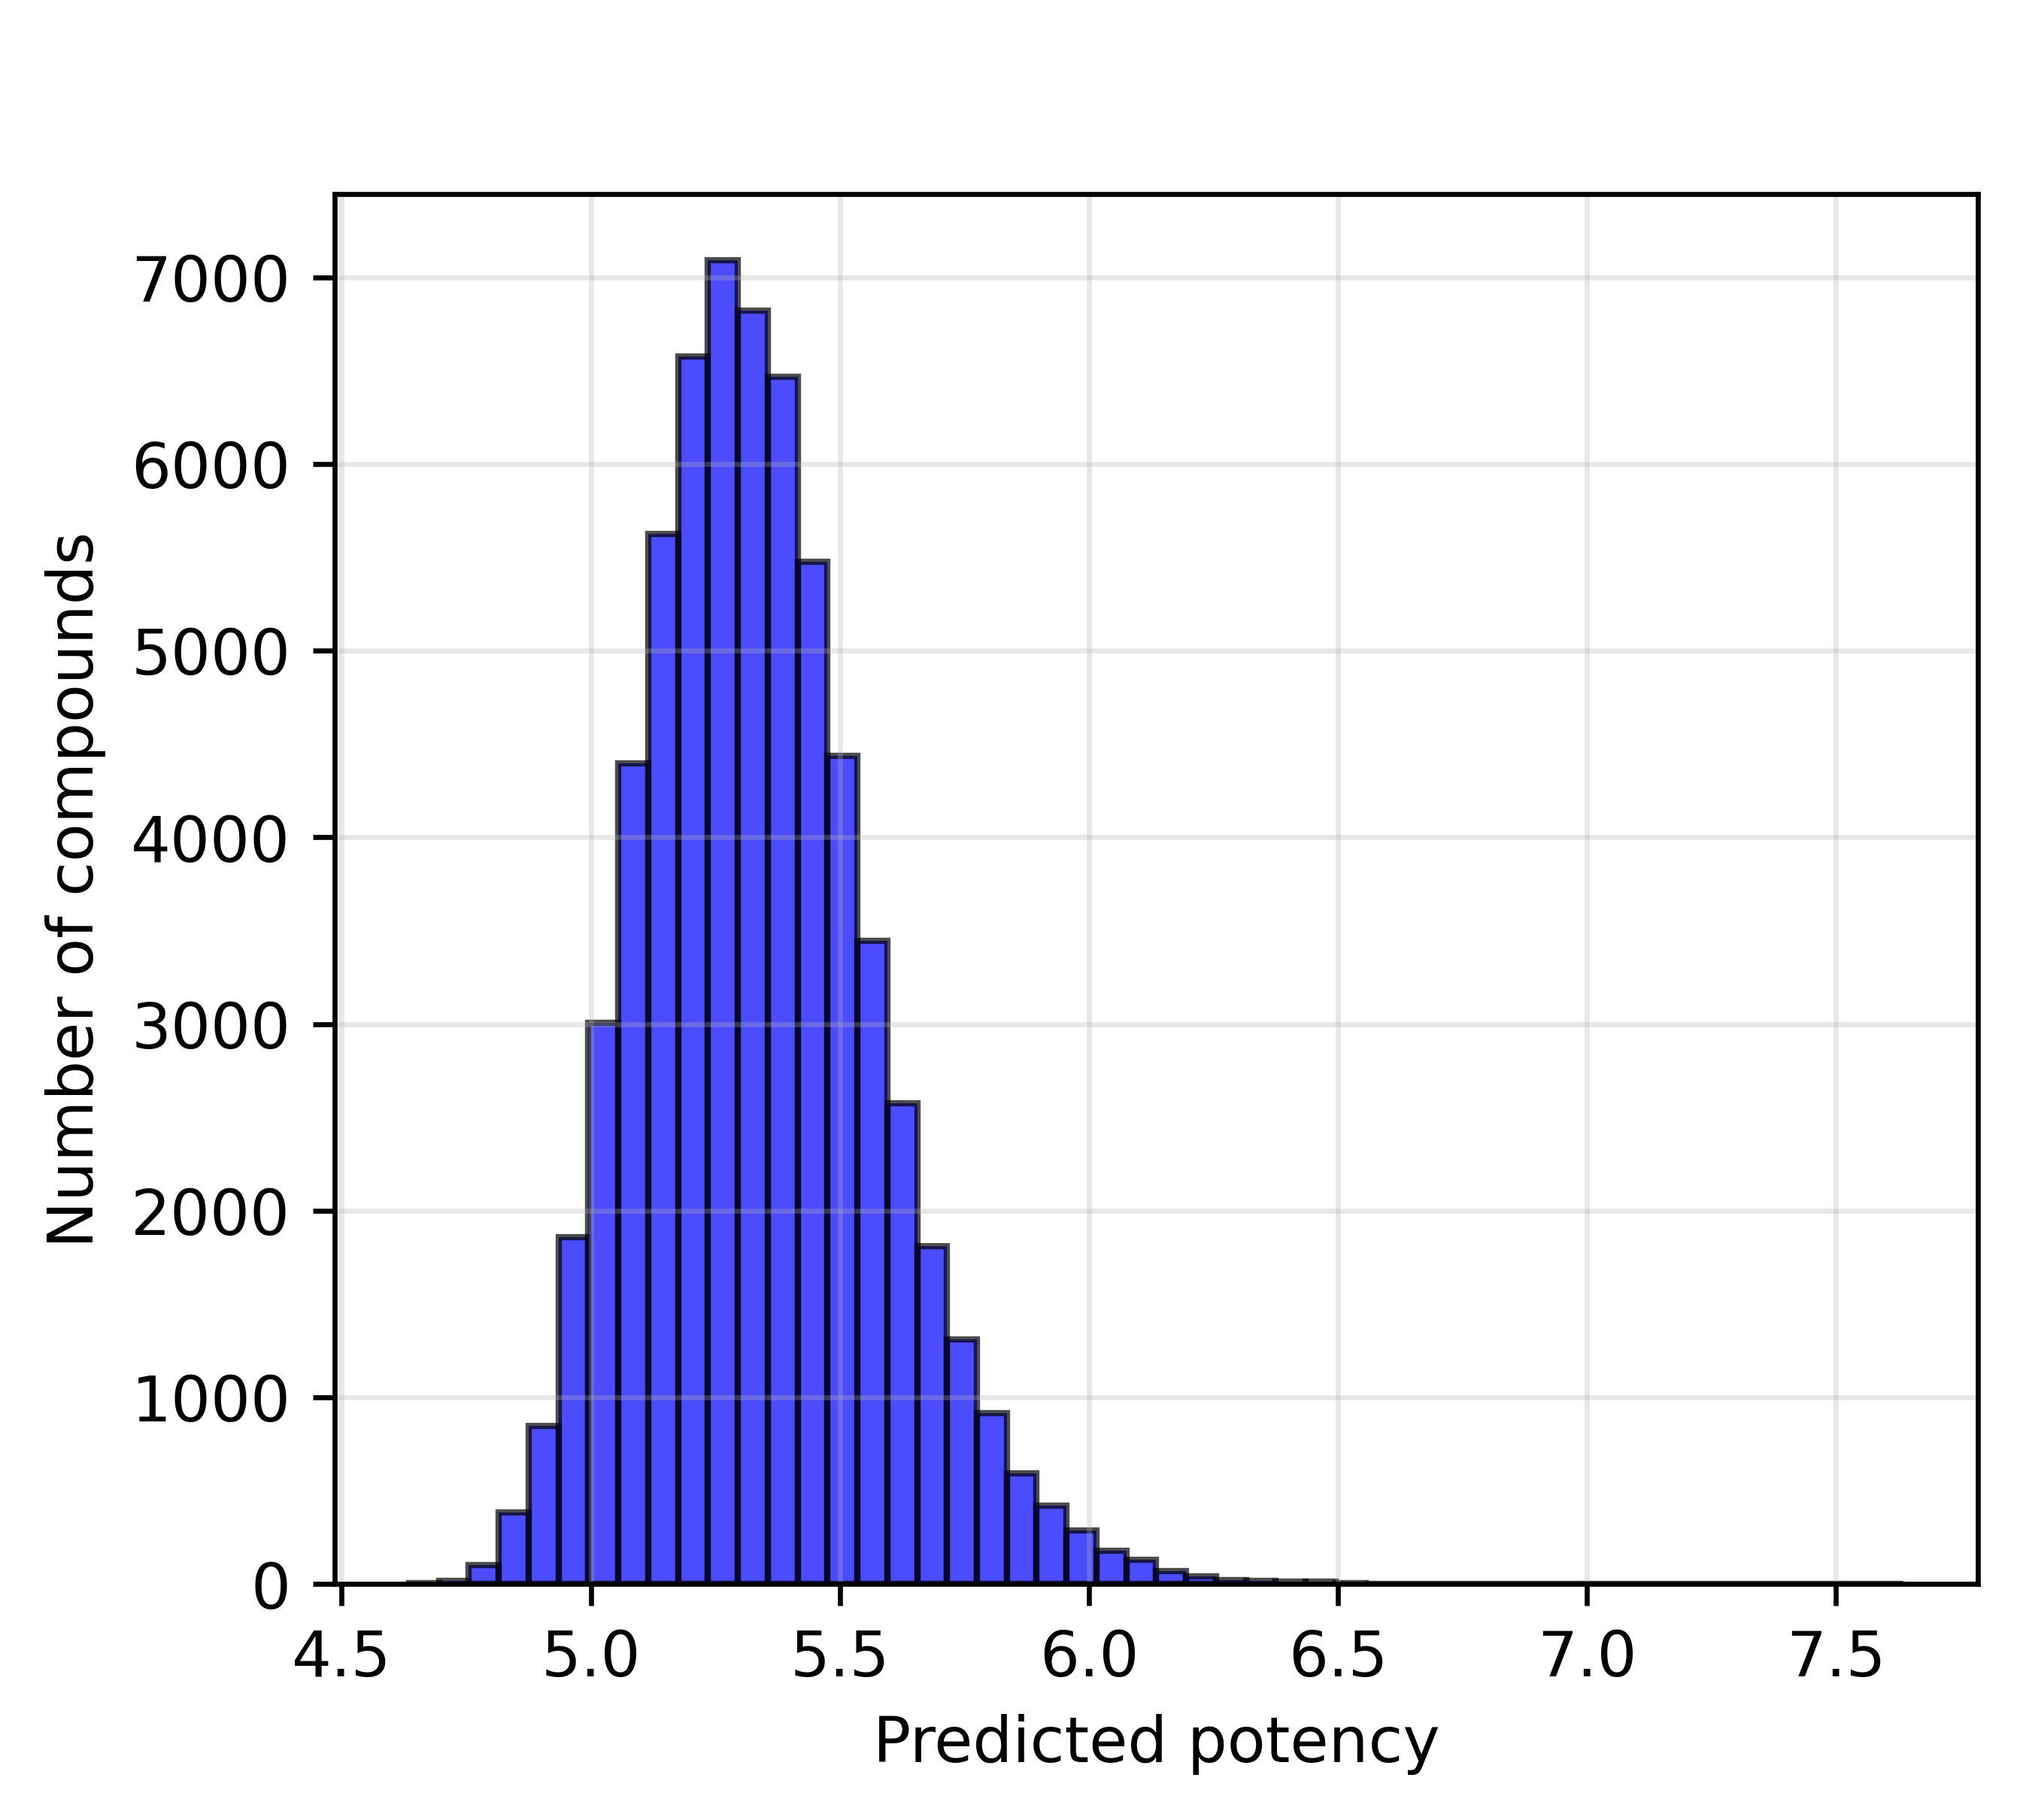

In [122]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + '/LassaVirus_validation_noDuplicates_ChemDivDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + '/LassaVirus_validation_noDuplicates_ChemDivDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [123]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7.0)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 1 compounds
Medium priority (6 ≤ pPotency < 7.0): 543 compounds
Low priority (5 ≤ pPotency < 6): 61016 compounds


In [124]:
ChemDivAntiviralsData_final = ChemDivAntiviralsData.iloc[idx].copy()
ChemDivAntiviralsData_final['pPotency_prediction'] = Y1_lib_pred[idx]
ChemDivAntiviralsData_final = ChemDivAntiviralsData_final.filter(
    items=["SMILES", "pPotency_prediction", "clogP"]
)
ChemDivAntiviralsData_final

,SMILES,pPotency_prediction
8566,CCOc1ccc(CNc2ccc3c(c2)ncn3-c2ccc(C)cc2)cc1,7.635


### Top 20 compounds with higher PpPotency

In [125]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 6.48
Highest predicted pPotency: 7.63
Range of top 20: 6.48 - 7.63


In [126]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
ChemDivAntiviralsData_top20 = ChemDivAntiviralsData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
ChemDivAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
ChemDivAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
ChemDivAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
ChemDivAntiviralsData_top20 = ChemDivAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
ChemDivAntiviralsData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    6.480
  IC50:        3.309e-07 M  (330.88 nM)

Best Values (1st ranked compound):
  pPotency:    7.635
  IC50:        2.318e-08 M  (23.18 nM)
Range for Top 20 Compounds:
pPotency Range:  6.480 - 7.635

IC50 Range (M):  3.309e-07 - 2.318e-08


,Rank,SMILES,pPotency_prediction,IC50 (M)
8566,1,CCOc1ccc(CNc2ccc3c(c2)ncn3-c2ccc(C)cc2)cc1,7.635,2.318e-08
8738,2,COC(=O)c1ccc2c(c1)sc1nc(-c3ccccc3)cn12,6.970,1.071e-07
39255,3,COC(=O)c1ccc2c(c1)sc1nc(-c3ccc(OC)cc3)cn12,6.913,1.222e-07
42929,4,COc1ccc(-c2nn(-c3ccccc3)cc2C(=O)Oc2ccccc2)cc1OC,6.732,1.851e-07
6423,5,CC1(C)Oc2ccc(NC(=O)c3cc(-c4ccccc4)nc4ccccc34)c...,6.707,1.962e-07
28335,6,Cc1c(C(=O)NCC(c2ccc(C(C)(C)C)cc2)N(C)C)oc2ccccc12,6.706,1.966e-07
42089,7,COC(=O)c1cc2nc(-c3ccccc3)cc(-c3ccccc3)n2n1,6.660,2.188e-07
2261,8,CC(C)COc1ccc(-c2nn(-c3ccccc3)cc2CO)cc1,6.655,2.215e-07
15662,9,Cc1nc(Nc2ccc(OC(C)C)cc2)cc(-c2ccccc2)n1,6.631,2.338e-07
64680,10,CCOC(=O)c1ccc2c(c1)sc1nc(-c3ccccc3)cn12,6.604,2.490e-07


In [127]:
ChemDivAntiviralsData_top20.to_csv(os.path.join(resultsDir + "Lassavirus/Lassavirus_noDuplicates_ChemDivAntiviralsData_top20.csv"), index=False)
ChemDivAntiviralsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "Lassavirus/Lassavirus_noDuplicates_ChemDivAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Lassavirus/LassaVirus_predictedCompounds_noDuplicates_ChemDivDataset.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Lassavirus/LassaVirus_predictedCompounds_noDuplicates_ChemDivDataset.svg


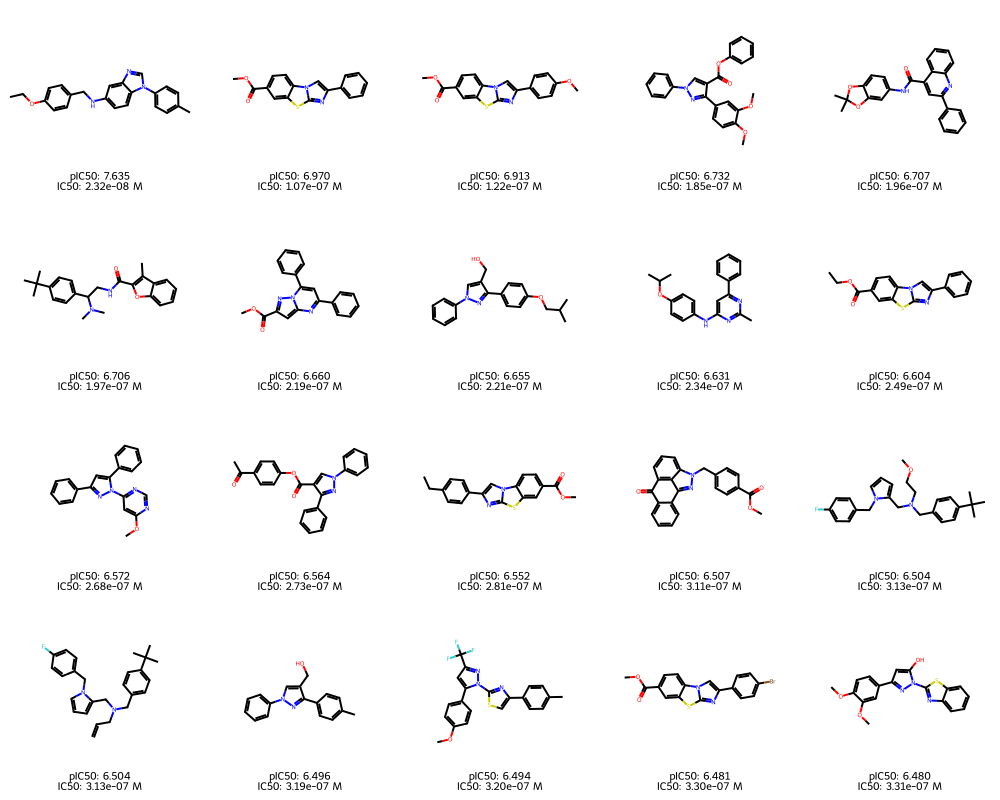

In [128]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = saveDir + '/'
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in ChemDivAntiviralsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in ChemDivAntiviralsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'LassaVirus_predictedCompounds_noDuplicates_ChemDivDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'LassaVirus_predictedCompounds_noDuplicates_ChemDivDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

### 2.4 Discovery of new hits specific to all viruses (data source `SMACC` Antivirals data set)
In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. In particular, we are interested in molecules with high predicted pPotency.

In [129]:
SMACCAntiviralsData = pd.read_csv(modelBuildingDataDir + "SMACCAntiviralsData_clean.csv")

# Check for duplicates
dup_check = SMACCAntiviralsData.groupby('SMILES')['pIC50'].agg(['count', 'median', 'std'])
duplicates = dup_check[dup_check['count'] > 1]
print(f"Original SMACC data shape: {SMACCAntiviralsData.shape}, with Duplicate SMILES: {len(duplicates)}")

# Take median pIC50 for duplicates
SMACCAntiviralsData = SMACCAntiviralsData.groupby('SMILES').agg({
    'Molecule ChEMBL ID': 'first',
    'pIC50': 'median',  # Use median instead of mean
    'Virus': 'first'
}).reset_index()

print(f"After removing internal duplicates: {SMACCAntiviralsData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")
# Add canonical SMILES column to SMACC data (reusing canonical_train from previous code)
SMACCAntiviralsData['Canonical_SMILES'] = SMACCAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~SMACCAntiviralsData['Canonical_SMILES'].isin(canonical_train)
SMACCAntiviralsData_filtered = SMACCAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
SMACCAntiviralsData = SMACCAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered SMACC data shape for validation: {SMACCAntiviralsData.shape}")
print(f"Removed {SMACCAntiviralsData_filtered.shape[0] - SMACCAntiviralsData.shape[0]} duplicate compounds from SMACC data set")
SMACCAntiviralsData = SMACCAntiviralsData.rename(columns={'pIC50': 'pIC50_experimental'})

smi_lib = SMACCAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
SMACCAntiviralsData.head()

Original SMACC data shape: (1923, 5), with Duplicate SMILES: 197
After removing internal duplicates: (1612, 4)
Number of unique SMILES in training set: 184
Filtered SMACC data shape for validation: (1612, 4)
Removed 0 duplicate compounds from SMACC data set
Total compounds to screen: 1612


,SMILES,Molecule ChEMBL ID,pIC50_experimental,Virus
0,Brc1ccc(NC(=O)CC2Sc3ncnn3C2=O)cc1,CHEMBL243652,5.690,SARS-CoV-2
1,Brc1ccc(Oc2ccc3NS(=O)(=O)C=C(OC(=O)c4ccccc4)c3...,CHEMBL4284511,5.328,Dengue
2,Brc1ccc(cc1)C1C2=C(NC(=S)NC2=O)OC2=C1C(=O)NC(=...,CHEMBL1402117,4.132,Dengue
3,Brc1ccc2C(=O)C(=O)C=Cc2c1,CHEMBL4303595,7.097,SARS-CoV-2
4,Brc1ccc2NC(=O)C(=C3SC(=S)N(NS(=O)(=O)c4ccccc4)...,CHEMBL1361582,4.627,Dengue


Generate predictions

In [130]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [131]:
SMACCAntiviralsData_predicted = SMACCAntiviralsData.copy()
SMACCAntiviralsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
SMACCAntiviralsData_predicted['IC50(M)_experimental'] = 10 ** (-SMACCAntiviralsData_predicted['pIC50_experimental'])
SMACCAntiviralsData_predicted['pPotency(M)_prediction'] = 10 ** (-SMACCAntiviralsData_predicted['pPotency_prediction'])

SMACCAntiviralsData_predicted = SMACCAntiviralsData_predicted.filter(
    items=["SMILES", "Virus", "pIC50_experimental", "pPotency_prediction",  "IC50(M)_experimental", "pPotency(M)_prediction"]
)
SMACCAntiviralsData_predicted

,SMILES,Virus,pIC50_experimental,pPotency_prediction,IC50(M)_experimental,pPotency(M)_prediction
0,Brc1ccc(NC(=O)CC2Sc3ncnn3C2=O)cc1,SARS-CoV-2,5.690,5.438,2.040e-06,3.643e-06
1,Brc1ccc(Oc2ccc3NS(=O)(=O)C=C(OC(=O)c4ccccc4)c3...,Dengue,5.328,5.012,4.700e-06,9.729e-06
2,Brc1ccc(cc1)C1C2=C(NC(=S)NC2=O)OC2=C1C(=O)NC(=...,Dengue,4.132,5.197,7.371e-05,6.356e-06
3,Brc1ccc2C(=O)C(=O)C=Cc2c1,SARS-CoV-2,7.097,5.349,8.000e-08,4.481e-06
4,Brc1ccc2NC(=O)C(=C3SC(=S)N(NS(=O)(=O)c4ccccc4)...,Dengue,4.627,5.317,2.359e-05,4.824e-06
...,...,...,...,...,...,...
1607,S=C1NN=C(Nc2ccccc2)S1,SARS-CoV-2,6.409,5.508,3.900e-07,3.105e-06
1608,S=C1Nc2ccccc2S1,SARS-CoV-2,5.759,5.462,1.740e-06,3.454e-06
1609,SC(=S)N1CCCC1,SARS-CoV-2,6.678,5.356,2.100e-07,4.410e-06
1610,c1coc(c1)-c1nc2ccccc2nc1-c1ccco1,Dengue,4.000,5.590,1.000e-04,2.570e-06


In [132]:
SMACCAntiviralsData_predicted.to_csv(os.path.join(resultsDir + "Lassavirus/Lassavirus_noDuplicates_SMACCAntiviralsData_predicted_all.csv"), index=False)
SMACCAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "Lassavirus/Lassavirus_noDuplicates_SMACCAntiviralsData_predicted_all_SMILES.csv"), index=False)

### Plot the error between `experimental_pPotency` and `predicted_pPotency`

Mean Residual: 0.477
Std Dev of Residuals: 1.072
Min Residual: -5.131
Max Residual: 2.327


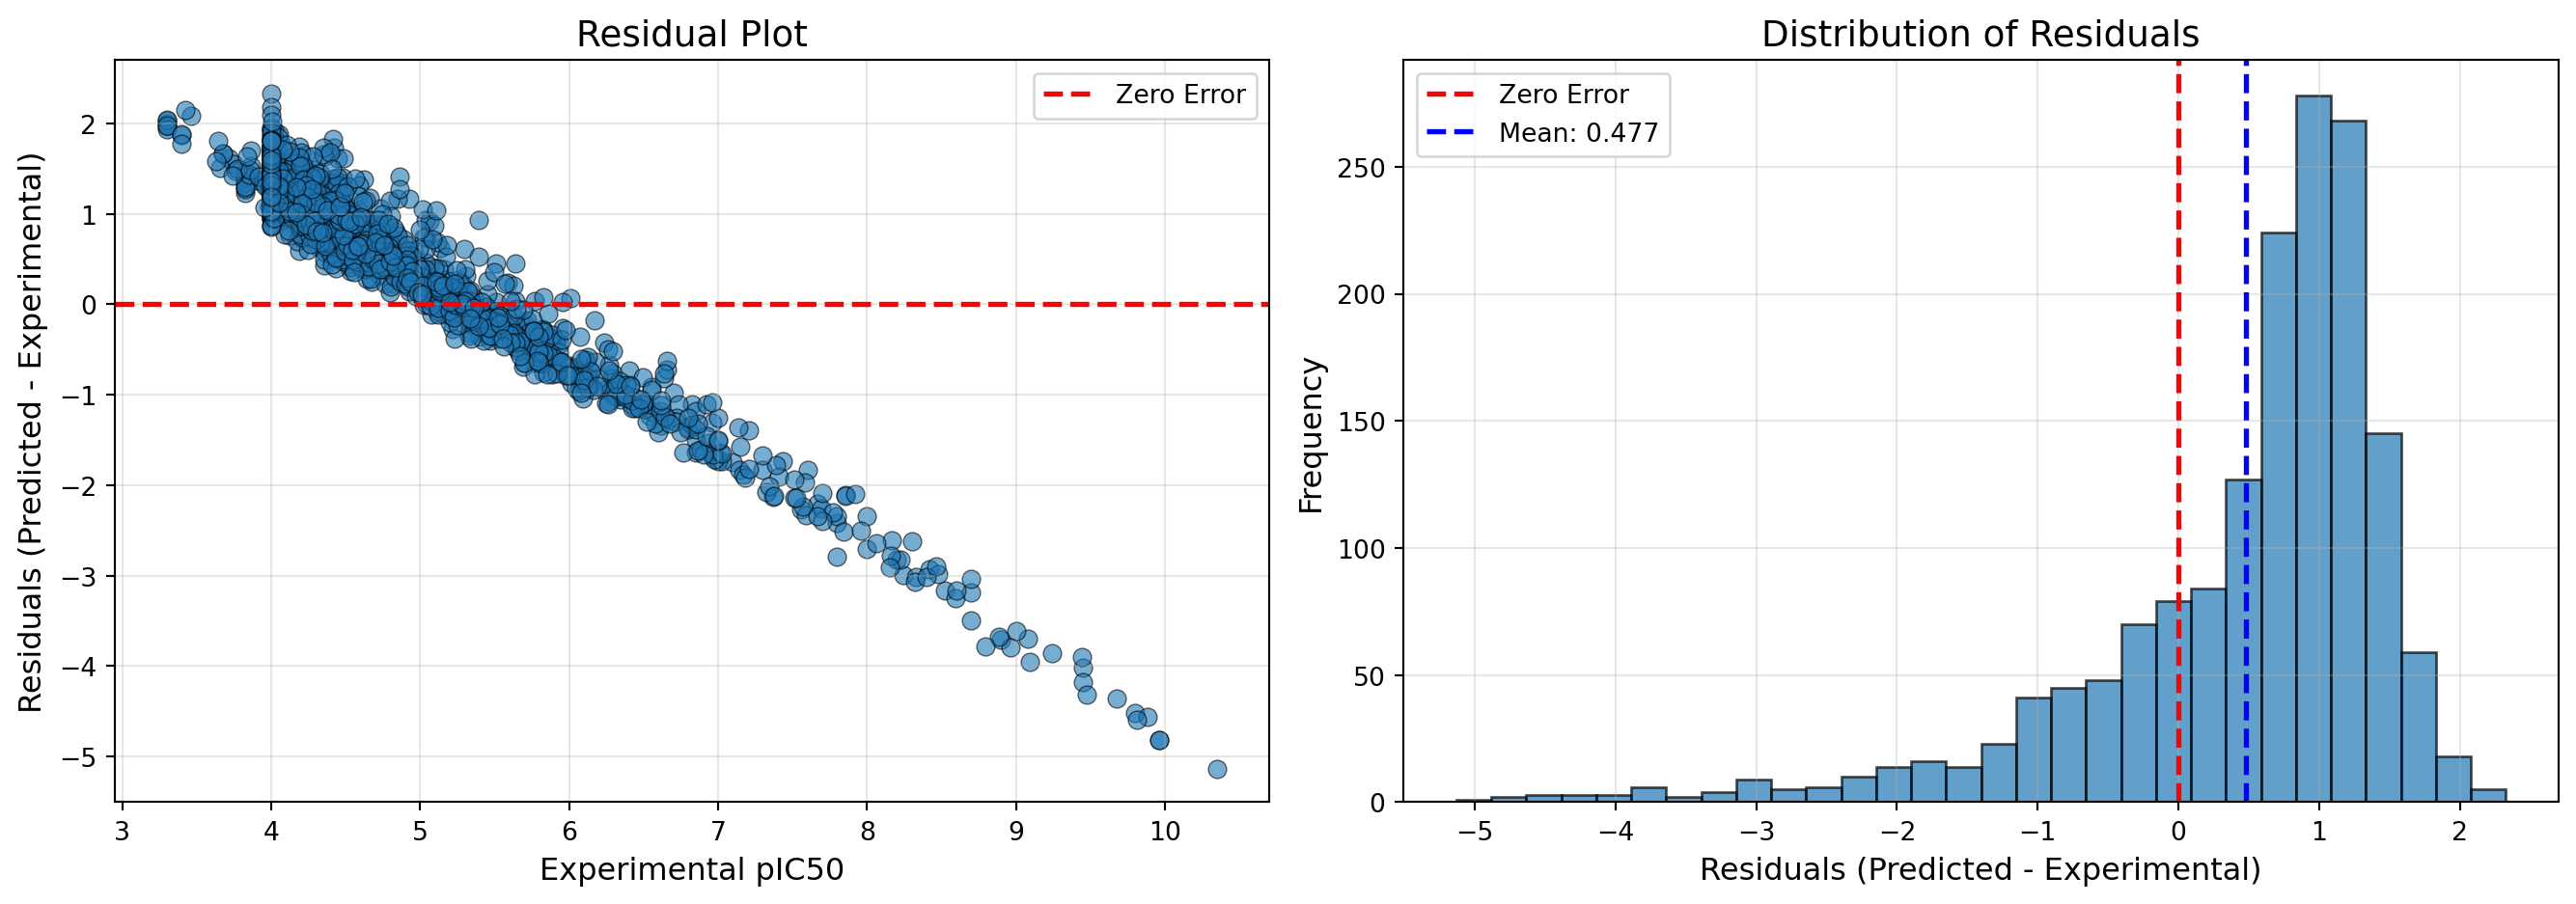

In [133]:
# Calculate residuals (difference)
SMACCAntiviralsData_predicted['residuals'] = (
    SMACCAntiviralsData_predicted['pPotency_prediction'] - 
    SMACCAntiviralsData_predicted['pIC50_experimental']
)

# Print statistics
print(f"Mean Residual: {SMACCAntiviralsData_predicted['residuals'].mean():.3f}")
print(f"Std Dev of Residuals: {SMACCAntiviralsData_predicted['residuals'].std():.3f}")
print(f"Min Residual: {SMACCAntiviralsData_predicted['residuals'].min():.3f}")
print(f"Max Residual: {SMACCAntiviralsData_predicted['residuals'].max():.3f}")

# Create residual plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Residuals vs Experimental values
axes[0].scatter(SMACCAntiviralsData_predicted['pIC50_experimental'], 
                SMACCAntiviralsData_predicted['residuals'], 
                alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[0].set_xlabel('Experimental pIC50', fontsize=12)
axes[0].set_ylabel('Residuals (Predicted - Experimental)', fontsize=12)
axes[0].set_title('Residual Plot', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Distribution of residuals
axes[1].hist(SMACCAntiviralsData_predicted['residuals'], bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].axvline(x=SMACCAntiviralsData_predicted['residuals'].mean(), 
                color='blue', linestyle='--', linewidth=2, 
                label=f'Mean: {SMACCAntiviralsData_predicted["residuals"].mean():.3f}')
axes[1].set_xlabel('Residuals (Predicted - Experimental)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Residuals', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Residual Plot Analysis

In [134]:
print(f"Mean residual: {SMACCAntiviralsData_predicted['residuals'].mean():.3f} (Close to 0 indicates no systematic bias)")
print(f"Std deviation: {SMACCAntiviralsData_predicted['residuals'].std():.3f} (typical prediction error)")
print(f"95% of predictions are within ±{1.96 * SMACCAntiviralsData_predicted['residuals'].std():.3f} pIC50 units")

Mean residual: 0.477 (Close to 0 indicates no systematic bias)
Std deviation: 1.072 (typical prediction error)
95% of predictions are within ±2.102 pIC50 units


Let us have a look at the compounds:

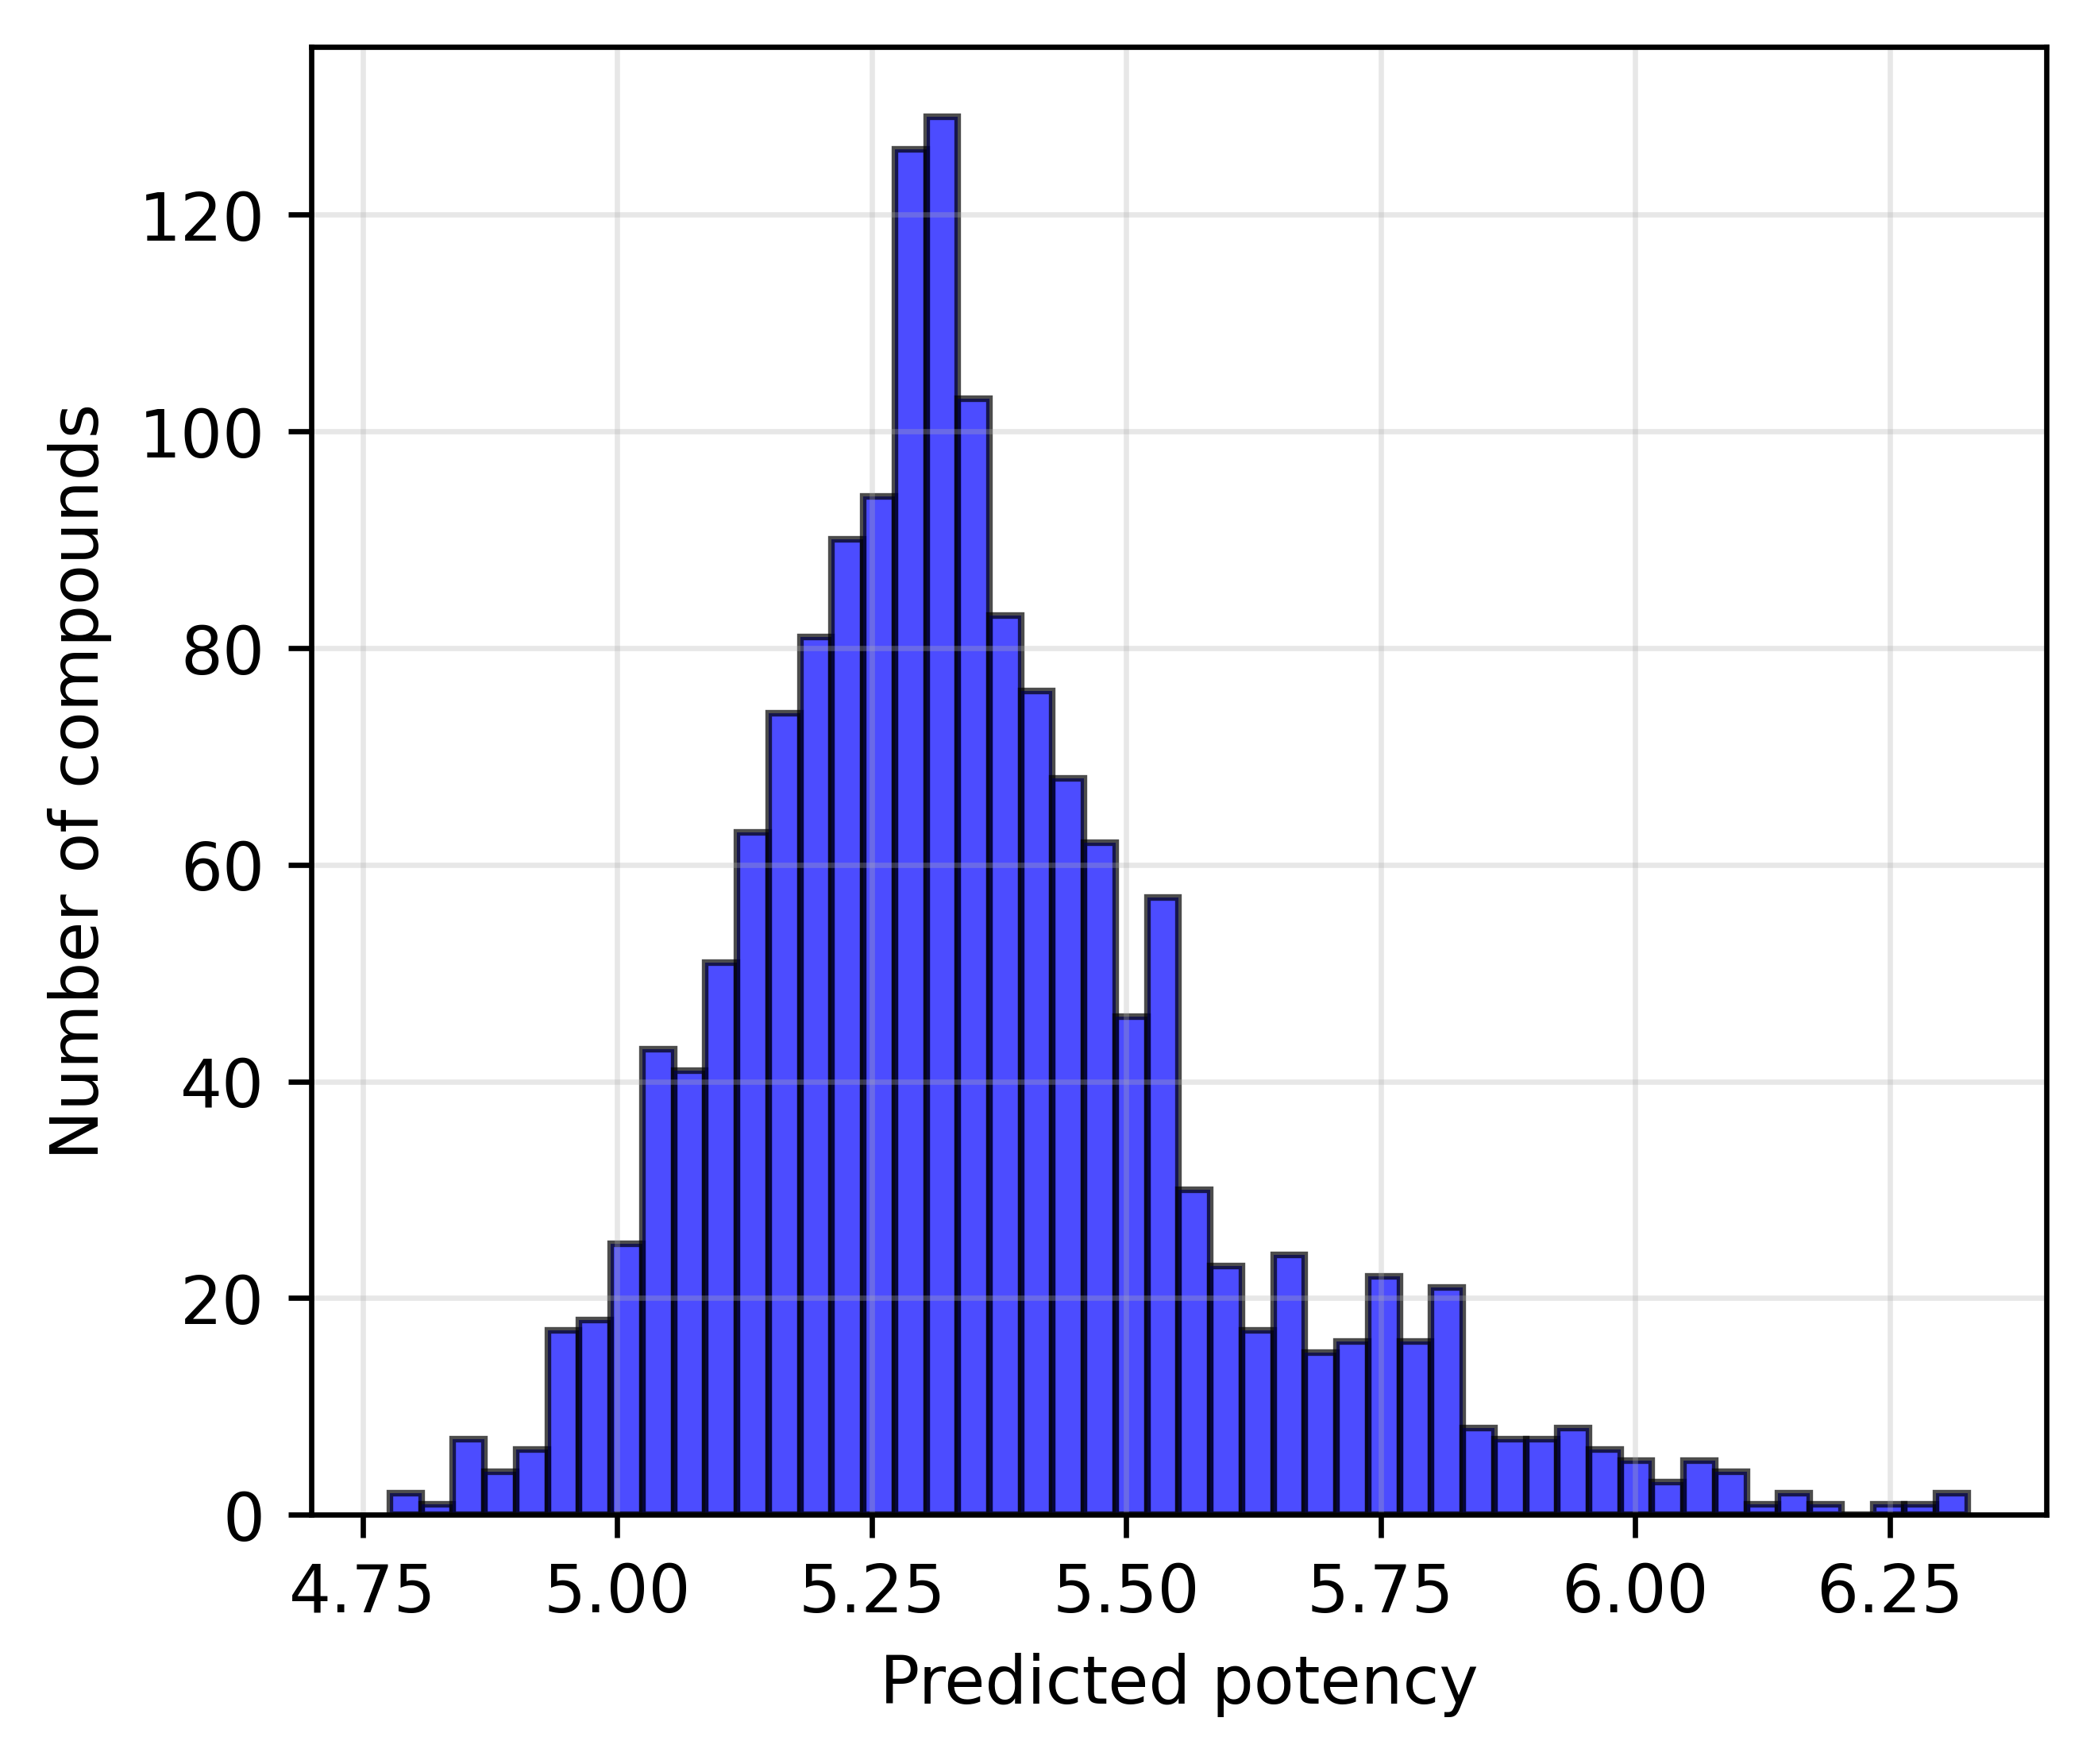

In [135]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + '/LassaVirus_validation_noDuplicates_SMACCDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + '/LassaVirus_validation_noDuplicates_SMACCDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

In [136]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 22 compounds
Low priority (5 ≤ pPotency < 6): 1531 compounds


### Top 20 compounds with higher pPotency

In [137]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 6.02
Highest predicted pPotency: 6.33
Range of top 20: 6.02 - 6.33


In [138]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
SMACCAntiviralsData_top20 = SMACCAntiviralsData_predicted.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
SMACCAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
SMACCAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
SMACCAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'


SMACCAntiviralsData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    6.018
  IC50:        9.598e-07 M  (959.75 nM)

Best Values (1st ranked compound):
  pPotency:    6.327
  IC50:        4.713e-07 M  (471.29 nM)
Range for Top 20 Compounds:
pPotency Range:  6.018 - 6.327

IC50 Range (M):  9.598e-07 - 4.713e-07


,Rank,SMILES,Virus,pIC50_experimental,pPotency_prediction,IC50(M)_experimental,pPotency(M)_prediction,residuals,IC50 (M)
637,1,COc1ccc(Cn2nc(C)cc2CC(=O)c2ccccc2)cc1,West_Nile,4.000,6.327,1.000e-04,4.713e-07,2.327,4.713e-07
643,2,COc1ccc(Cn2nc(C)cc2OC(=O)c2ccccc2)cc1,West_Nile,5.395,6.323,4.030e-06,4.754e-07,0.928,4.754e-07
635,3,COc1ccc(Cn2nc(C)cc2C=Cc2c(F)cccc2F)cc1,West_Nile,4.860,6.271,1.380e-05,5.358e-07,1.411,5.358e-07
638,4,COc1ccc(Cn2nc(C)cc2CC(=O)c2ccccc2F)cc1,West_Nile,4.411,6.237,3.880e-05,5.795e-07,1.826,5.795e-07
640,5,COc1ccc(Cn2nc(C)cc2CC(O)c2ccccc2)cc1,West_Nile,4.000,6.182,1.000e-04,6.584e-07,2.182,6.584e-07
65,6,CC(C)(C)c1ccc(cc1)C(=O)CC(Sc1ccc(Cl)cc1)C(O)=O,Dengue,4.419,6.157,3.808e-05,6.966e-07,1.738,6.966e-07
1167,7,NCCCNc1cc(nc2ccccc12)N1CCc2ccccc2C1,RSV,5.108,6.151,7.800e-06,7.064e-07,1.043,7.064e-07
1041,8,Cn1c2ccc(Br)cc2c2cc(ccc12)-c1cccc(c1)C(N)=N,Zika,4.858,6.129,1.386e-05,7.431e-07,1.271,7.431e-07
873,9,Cc1ccc(F)c(NC(=O)C(C#N)C(=O)c2ccc(cc2)C(C)(C)C)c1,Dengue,4.487,6.103,3.257e-05,7.894e-07,1.616,7.894e-07
465,10,CN(C)c1ccc(C=C2c3cc(ccc3-n3c2cc(-c2ccccc2)[n+]...,Dengue,4.927,6.097,1.182e-05,8.001e-07,1.169,8.001e-07


In [139]:
SMACCAntiviralsData_top20.to_csv(os.path.join(resultsDir + "Lassavirus/Lassavirus_noDuplicates_SMACCAntiviralsData_top20.csv"), index=False)
SMACCAntiviralsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "Lassavirus/Lassavirus_noDuplicates_SMACCAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Lassavirus/LassaVirus_predictedCompounds_noDuplicates_SMACCDataset.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Lassavirus/LassaVirus_predictedCompounds_noDuplicates_SMACCDataset.svg


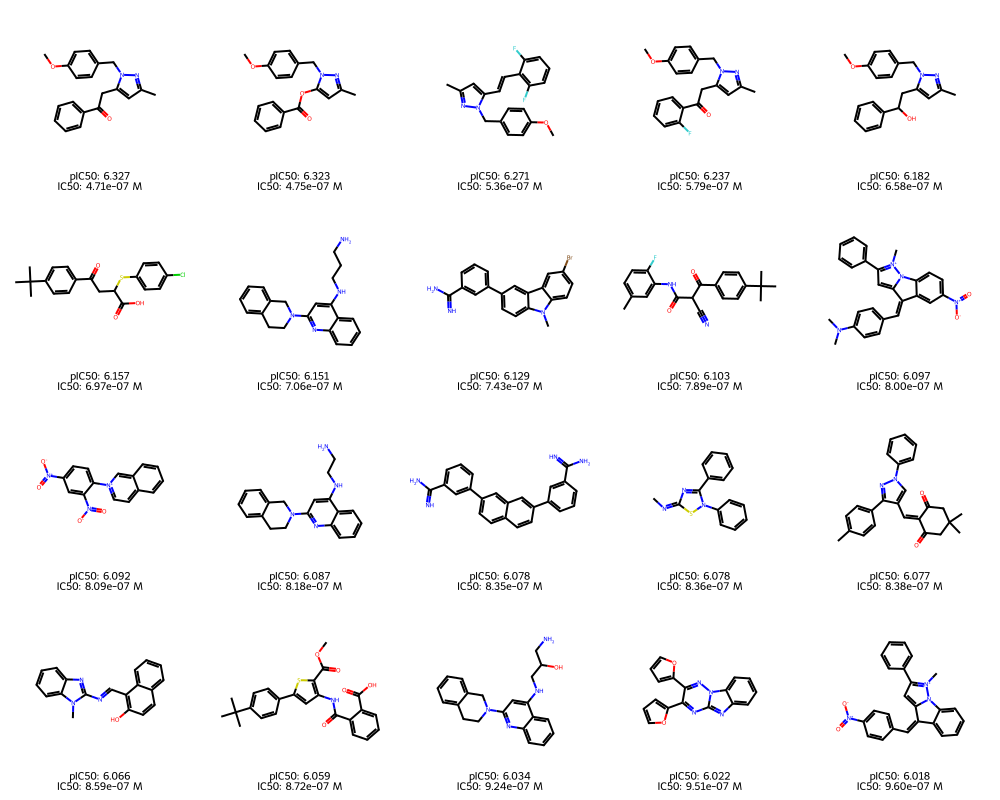

In [140]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = saveDir + '/'
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in SMACCAntiviralsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in SMACCAntiviralsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'LassaVirus_predictedCompounds_noDuplicates_SMACCDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'LassaVirus_predictedCompounds_noDuplicates_SMACCDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

### Checking drug likeliness of `Remdesivir` and `Molnupiravir`

In [141]:
Remdesivir_SMILES_file = os.path.join(dataDir + "/target_SMILES/Remdesivir_structure.mol")
Molnupiravir_SMILES_file = os.path.join(dataDir + "/target_SMILES/Molnupiravir_structure.mol")

In [142]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import pandas as pd

# SMILES strings
Remdesivir_SMILES = 'CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1'
Molnupiravir_SMILES = 'CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=C\C(NC1=O)=N\O'

# Dictionary of drugs and their SMILES
drugs = {
    'Remdesivir': Remdesivir_SMILES,
    'Molnupiravir': Molnupiravir_SMILES
}

# List to store results
smiles_data = []

# Process each drug
for drug_name, smiles in drugs.items():
    # Convert SMILES to molecule object
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is not None:
        smiles_data.append({
            'Drug_Name': drug_name,
            'SMILES': smiles,
            'Molecular_Formula': rdMolDescriptors.CalcMolFormula(mol),
            'Molecular_Weight': round(Descriptors.MolWt(mol), 2)
        })
        print(f" {drug_name}")
        print(f"  Formula: {rdMolDescriptors.CalcMolFormula(mol)}")
        print(f"  MW: {round(Descriptors.MolWt(mol), 2)} g/mol")
    else:
        print(f" Failed to parse SMILES for {drug_name}")

# Create DataFrame
DTRA_target_SMILES = pd.DataFrame(smiles_data)
DTRA_target_SMILES

 Remdesivir
  Formula: C27H35N6O8P
  MW: 602.59 g/mol
 Molnupiravir
  Formula: C13H19N3O7
  MW: 329.31 g/mol


,Drug_Name,SMILES,Molecular_Formula,Molecular_Weight
0,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](...,C27H35N6O8P,602.590
1,Molnupiravir,CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=...,C13H19N3O7,329.310


In [143]:
# Canonicalize training SMILES and create a set for fast lookup
canonical_train = set()
for smi in smiles_train:
    canonical_smi = canonicalize_smiles(smi)
    if canonical_smi is not None:
        canonical_train.add(canonical_smi)

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to DTRA target data
DTRA_target_SMILES['Canonical_SMILES'] = DTRA_target_SMILES['SMILES'].apply(canonicalize_smiles)

# ADDED: Save original count BEFORE filtering
original_count = DTRA_target_SMILES.shape[0]

# Filter out duplicates - keep only those NOT in training set
mask = ~DTRA_target_SMILES['Canonical_SMILES'].isin(canonical_train)
DTRA_target_SMILES_filtered = DTRA_target_SMILES[mask].copy()

# Remove the helper column if you don't need it
DTRA_target_SMILES = DTRA_target_SMILES_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered DTRA target data shape for validation: {DTRA_target_SMILES.shape}")
print(f"Removed {original_count - DTRA_target_SMILES.shape[0]} duplicate compounds from DTRA target data set")  # FIXED

# Now use the filtered data
smi_lib = DTRA_target_SMILES.SMILES
print(f"Total DTRA target compounds to screen: {len(smi_lib)}")

# Display the filtered data
DTRA_target_SMILES

Number of unique SMILES in training set: 184
Filtered DTRA target data shape for validation: (1, 4)
Removed 1 duplicate compounds from DTRA target data set
Total DTRA target compounds to screen: 1


,Drug_Name,SMILES,Molecular_Formula,Molecular_Weight
1,Molnupiravir,CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=...,C13H19N3O7,329.310


Generate predictions

In [144]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [145]:
DTRA_target_SMILES_predicted = DTRA_target_SMILES.copy()
DTRA_target_SMILES_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
DTRA_target_SMILES_predicted['pPotency(M)_prediction'] = 10 ** (-DTRA_target_SMILES_predicted['pPotency_prediction'])

DTRA_target_SMILES_predicted = DTRA_target_SMILES_predicted.filter(
    items=["SMILES", "pPotency_prediction",  "pPotency(M)_prediction"]
)
DTRA_target_SMILES_predicted.to_csv(os.path.join(resultsDir + "Lassavirus/Lassavirus_noDuplicates_DTRAtargets_predicted_all.csv"), index=False)
DTRA_target_SMILES_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "Lassavirus/Lassavirus_noDuplicates_DTRAtargets_predicted_all_SMILES.csv"), index=False)
DTRA_target_SMILES_predicted

,SMILES,pPotency_prediction,pPotency(M)_prediction
1,CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=...,5.546,2.847e-06


### Checking efficiency of `Remdesivir` as a antiviral, it present in training data set

In [146]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import pandas as pd

# SMILES strings
Remdesivir_SMILES = 'CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1'

# Dictionary of drugs and their SMILES
drugs = {
    'Remdesivir': Remdesivir_SMILES,
}

# List to store results
smiles_data = []

# Process each drug
for drug_name, smiles in drugs.items():
    # Convert SMILES to molecule object
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is not None:
        smiles_data.append({
            'Drug_Name': drug_name,
            'SMILES': smiles,
            'Molecular_Formula': rdMolDescriptors.CalcMolFormula(mol),
            'Molecular_Weight': round(Descriptors.MolWt(mol), 2)
        })
        print(f" {drug_name}")
        print(f"  Formula: {rdMolDescriptors.CalcMolFormula(mol)}")
        print(f"  MW: {round(Descriptors.MolWt(mol), 2)} g/mol")
    else:
        print(f" Failed to parse SMILES for {drug_name}")

# Create DataFrame
DTRA_target_SMILES = pd.DataFrame(smiles_data)
DTRA_target_SMILES

 Remdesivir
  Formula: C27H35N6O8P
  MW: 602.59 g/mol


,Drug_Name,SMILES,Molecular_Formula,Molecular_Weight
0,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](...,C27H35N6O8P,602.590


Find experimental pPotency value for `Remdesivir`

In [147]:
# Function to canonicalize SMILES
def canonicalize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        return Chem.MolToSmiles(mol, canonical=True) if mol else None
    except:
        return None

# Create mappings from allVirusData (without modifying it)
canonical_smiles = LassaVirusData_chEMBL_noDuplicates['Smiles'].apply(canonicalize_smiles)
smiles_to_pPotency = dict(zip(canonical_smiles, LassaVirusData_chEMBL_noDuplicates['pPotency']))
smiles_to_virus = dict(zip(canonical_smiles, LassaVirusData_chEMBL_noDuplicates['VirusClassifier']))

# Add columns to DTRA_target_SMILES
DTRA_target_SMILES['pIC50_experimental'] = DTRA_target_SMILES['SMILES'].apply(
    lambda x: smiles_to_pPotency.get(canonicalize_smiles(x), None)
)
DTRA_target_SMILES['VirusClassifier'] = DTRA_target_SMILES['SMILES'].apply(
    lambda x: smiles_to_virus.get(canonicalize_smiles(x), None)
)

# Display
print(f"Compounds with experimental data: {DTRA_target_SMILES['pIC50_experimental'].notna().sum()}")
DTRA_target_SMILES

Compounds with experimental data: 1


,Drug_Name,SMILES,Molecular_Formula,Molecular_Weight,pIC50_experimental,VirusClassifier
0,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](...,C27H35N6O8P,602.590,5.691,Lassa


In [148]:
# Now use the filtered data
smi_lib = DTRA_target_SMILES.SMILES
print(f"Total DTRA target compounds to screen: {len(smi_lib)}")

Total DTRA target compounds to screen: 1


Generate predictions

In [149]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [150]:
DTRA_target_SMILES_predicted = DTRA_target_SMILES.copy()
DTRA_target_SMILES_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
DTRA_target_SMILES_predicted['IC50(M)_experimental'] = 10 ** (-DTRA_target_SMILES_predicted['pIC50_experimental'])
DTRA_target_SMILES_predicted['pPotency(M)_prediction'] = 10 ** (-DTRA_target_SMILES_predicted['pPotency_prediction'])

DTRA_target_SMILES_predicted = DTRA_target_SMILES_predicted.filter(
    items=["SMILES", "VirusClassifier", "pIC50_experimental", "pPotency_prediction",  "IC50(M)_experimental", "pPotency(M)_prediction"]
)
DTRA_target_SMILES_predicted

,SMILES,VirusClassifier,pIC50_experimental,pPotency_prediction,IC50(M)_experimental,pPotency(M)_prediction
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](...,Lassa,5.691,5.791,2.036e-06,1.617e-06


Partition 3/10
  Fold 3 - Train MAE: 0.38, Test MAE: 0.52
Partition 8/10
  Fold 8 - Train MAE: 0.40, Test MAE: 0.72
Partition 2/10
  Fold 2 - Train MAE: 0.56, Test MAE: 0.57
Partition 7/10
  Fold 7 - Train MAE: 0.53, Test MAE: 0.72
Partition 1/10
  Fold 1 - Train MAE: 0.54, Test MAE: 0.64
Partition 1/10
  Fold 1 - Train MAE: 0.56, Test MAE: 0.61
Partition 8/10
  Fold 8 - Train MAE: 0.54, Test MAE: 0.82
Partition 4/10
  Fold 4 - Train MAE: 0.39, Test MAE: 0.53
Partition 5/10
  Fold 5 - Train MAE: 0.34, Test MAE: 0.52
Partition 7/10
  Fold 7 - Train MAE: 0.41, Test MAE: 0.70
Partition 10/10
  Fold 10 - Train MAE: 0.35, Test MAE: 0.61
Partition 4/10
  Fold 4 - Train MAE: 0.54, Test MAE: 0.61
Partition 5/10
  Fold 5 - Train MAE: 0.56, Test MAE: 0.55
Partition 9/10
  Fold 9 - Train MAE: 0.69, Test MAE: 0.60
Partition 2/10
  Fold 2 - Train MAE: 0.42, Test MAE: 0.54
Partition 6/10
  Fold 6 - Train MAE: 0.44, Test MAE: 0.45
Partition 9/10
  Fold 9 - Train MAE: 0.41, Test MAE: 0.75
Partition 3/

# Train an ML model by combining `PubChem + chEMBL` data 

### Read Pubchem bioassay data for Lassa virus

In [12]:
LassaVirusData_Pubchem = pd.read_csv(os.path.join(modelBuildingDataDir, "allVirus_Pubchem.csv"))
# Keep only data for Lassa virus
LassaVirusData_Pubchem = LassaVirusData_Pubchem[LassaVirusData_Pubchem['Virus'] == 'Lassa']
LassaVirusData_Pubchem = LassaVirusData_Pubchem.rename(
    columns={'Virus': 'VirusClassifier'})
LassaVirusData_Pubchem

,VirusClassifier,compound_id,Smiles,pPotency
1118,Lassa,2259,O=C(O)C1=CC(=C(c2ccc(O)c(C(=O)O)c2)c2ccc(O)c(C...,4.000000
1119,Lassa,311,O=C(O)CC(O)(CC(=O)O)C(=O)O,3.000000
1120,Lassa,2829313,O=C(O)c1ccc(Nc2nc(Cl)nc(Cl)n2)cc1-c1c2ccc(=O)c...,3.000000
1121,Lassa,6254,O=C(O)c1cc(SSc2ccc([N+](=O)[O-])c(C(=O)O)c2)cc...,4.000000
1122,Lassa,978327,O=C(N[C@H](CC1CCCCC1)C(=O)O)OCC1c2ccccc2-c2ccc...,3.000000
...,...,...,...,...
2389,Lassa,135907423,C/C(=N\NC(=O)[C@@H]1C[C@H]1c1ccccc1)c1ccc(O)cc1,8.638272
2390,Lassa,73356996,C/C(=N\NC(=O)[C@@H]1C[C@H]1c1ccccc1)c1cccc(C)c1,7.236572
2391,Lassa,9695967,C/C(=N\NC(=O)[C@@H]1C[C@H]1c1ccccc1)c1cccc(NC(...,5.200659
2392,Lassa,25753841,C/C(=N\NC(=O)[C@@H]1C[C@H]1c1ccccc1)c1ccc(F)cc1,7.283997


In [13]:
LassaVirusData_chEMBL = LassaVirusData_chEMBL[
    ['compound_id', 'Smiles', 'pPotency', 'VirusClassifier']]
LassaVirusData_chEMBL

,compound_id,Smiles,pPotency,VirusClassifier
13799,CHEMBL2314868,CCOc1ccc(Cn2cnc3cc(NCc4ccc(CC)cc4)cnc32)cc1,5.795880,Lassa
13800,CHEMBL2315151,CCOc1ccc(-n2cnc3cc(NCc4ccc(CC)cc4)cnc32)nc1,9.008774,Lassa
13801,CHEMBL2315139,CCOc1ccc(-n2ccc3cc(NCc4ccc(CC)cc4)ccc32)cc1,7.161151,Lassa
13802,CHEMBL2314867,CCOc1ccc(-n2cnc3cc(/N=C/c4ccc(CC)cc4)cnc32)cc1,5.366532,Lassa
13803,CHEMBL2322815,COc1ccc(-n2cnc3cc(NCc4ccccc4OC)ccc32)cc1,6.337242,Lassa
...,...,...,...,...
14011,CHEMBL4871373,Cc1cc2ncn(-c3ccc(OC(C)C)cc3)c2cc1-c1ccc(OC(C)C...,NaN,Lassa
14012,CHEMBL4862268,CC(C)Oc1ccc(-c2cnc3ccc(-c4ccc(F)cc4)cn23)cc1,NaN,Lassa
14013,CHEMBL4864023,CC(C)Oc1ccc(-c2cnc3ccc(-c4ccc(C5(N)CC5)cc4)cn2...,8.098542,Lassa
14014,CHEMBL4851799,Cc1c(-c2ccc(OC(C)C)cc2)ccc2ncc(-c3ccc(OC(C)C)c...,9.494850,Lassa


### Combine `Pubchem + chEMBL` data

In [14]:
LassaVirusData_allDB = pd.concat(
    [LassaVirusData_Pubchem, LassaVirusData_chEMBL],
    ignore_index=True
)

LassaVirusData_allDB

,VirusClassifier,compound_id,Smiles,pPotency
0,Lassa,2259,O=C(O)C1=CC(=C(c2ccc(O)c(C(=O)O)c2)c2ccc(O)c(C...,4.000000
1,Lassa,311,O=C(O)CC(O)(CC(=O)O)C(=O)O,3.000000
2,Lassa,2829313,O=C(O)c1ccc(Nc2nc(Cl)nc(Cl)n2)cc1-c1c2ccc(=O)c...,3.000000
3,Lassa,6254,O=C(O)c1cc(SSc2ccc([N+](=O)[O-])c(C(=O)O)c2)cc...,4.000000
4,Lassa,978327,O=C(N[C@H](CC1CCCCC1)C(=O)O)OCC1c2ccccc2-c2ccc...,3.000000
...,...,...,...,...
1486,Lassa,CHEMBL4871373,Cc1cc2ncn(-c3ccc(OC(C)C)cc3)c2cc1-c1ccc(OC(C)C...,NaN
1487,Lassa,CHEMBL4862268,CC(C)Oc1ccc(-c2cnc3ccc(-c4ccc(F)cc4)cn23)cc1,NaN
1488,Lassa,CHEMBL4864023,CC(C)Oc1ccc(-c2cnc3ccc(-c4ccc(C5(N)CC5)cc4)cn2...,8.098542
1489,Lassa,CHEMBL4851799,Cc1c(-c2ccc(OC(C)C)cc2)ccc2ncc(-c3ccc(OC(C)C)c...,9.494850


### Canonicalize the `Smiles`

In [15]:
def canonicalize_smiles(smi):
    mol = Chem.MolFromSmiles(smi)
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

LassaVirusData_allDB['Smiles'] = (
    LassaVirusData_allDB['Smiles']
    .astype(str)
    .apply(canonicalize_smiles)
)
LassaVirusData_allDB

,VirusClassifier,compound_id,Smiles,pPotency
0,Lassa,2259,O=C(O)C1=CC(=C(c2ccc(O)c(C(=O)O)c2)c2ccc(O)c(C...,4.000000
1,Lassa,311,O=C(O)CC(O)(CC(=O)O)C(=O)O,3.000000
2,Lassa,2829313,O=C(O)c1ccc(Nc2nc(Cl)nc(Cl)n2)cc1-c1c2ccc(=O)c...,3.000000
3,Lassa,6254,O=C(O)c1cc(SSc2ccc([N+](=O)[O-])c(C(=O)O)c2)cc...,4.000000
4,Lassa,978327,O=C(N[C@H](CC1CCCCC1)C(=O)O)OCC1c2ccccc2-c2ccc...,3.000000
...,...,...,...,...
1486,Lassa,CHEMBL4871373,Cc1cc2ncn(-c3ccc(OC(C)C)cc3)c2cc1-c1ccc(OC(C)C...,NaN
1487,Lassa,CHEMBL4862268,CC(C)Oc1ccc(-c2cnc3ccc(-c4ccc(F)cc4)cn23)cc1,NaN
1488,Lassa,CHEMBL4864023,CC(C)Oc1ccc(-c2cnc3ccc(-c4ccc(C5(N)CC5)cc4)cn2...,8.098542
1489,Lassa,CHEMBL4851799,Cc1c(-c2ccc(OC(C)C)cc2)ccc2ncc(-c3ccc(OC(C)C)c...,9.494850


### Compound Distribution Across Viruses

In [16]:
virus_counts = LassaVirusData_allDB['VirusClassifier'].value_counts().sort_values(ascending=False)
total_compounds = len(LassaVirusData_allDB)

print(f"\n{'Strain':<30} {'Count':>10} {'Percentage':>12}")
print("-"*70)

for virus, count in virus_counts.items():
    percentage = (count / total_compounds) * 100
    print(f"{virus:<30} {count:>10} {percentage:>11.2f}%")

print("-"*70)
print(f"{'TOTAL':<30} {total_compounds:>10} {100.0:>11.2f}%")
print(f"\nNumber of unique viruses: {len(virus_counts)}")


Strain                              Count   Percentage
----------------------------------------------------------------------
Lassa                                1491      100.00%
----------------------------------------------------------------------
TOTAL                                1491      100.00%

Number of unique viruses: 1


### Add `ID` column to left

In [17]:
LassaVirusData_allDB.insert(0, 'ID', range(1, len(LassaVirusData_allDB) + 1))
LassaVirusData_allDB.head()

,ID,VirusClassifier,compound_id,Smiles,pPotency
0,1,Lassa,2259,O=C(O)C1=CC(=C(c2ccc(O)c(C(=O)O)c2)c2ccc(O)c(C...,4.0
1,2,Lassa,311,O=C(O)CC(O)(CC(=O)O)C(=O)O,3.0
2,3,Lassa,2829313,O=C(O)c1ccc(Nc2nc(Cl)nc(Cl)n2)cc1-c1c2ccc(=O)c...,3.0
3,4,Lassa,6254,O=C(O)c1cc(SSc2ccc([N+](=O)[O-])c(C(=O)O)c2)cc...,4.0
4,5,Lassa,978327,O=C(N[C@H](CC1CCCCC1)C(=O)O)OCC1c2ccccc2-c2ccc...,3.0


### Add another filer to keep only these four columns: `ID`, `compound_id`,	`Smiles`, `pPotency`, `VirusClassifier`

In [18]:
LassaVirusData_allDB = LassaVirusData_allDB.filter(
    items=["ID", "compound_id", "Smiles", "pPotency", "VirusClassifier"]
)
LassaVirusData_allDB.head()

,ID,compound_id,Smiles,pPotency,VirusClassifier
0,1,2259,O=C(O)C1=CC(=C(c2ccc(O)c(C(=O)O)c2)c2ccc(O)c(C...,4.0,Lassa
1,2,311,O=C(O)CC(O)(CC(=O)O)C(=O)O,3.0,Lassa
2,3,2829313,O=C(O)c1ccc(Nc2nc(Cl)nc(Cl)n2)cc1-c1c2ccc(=O)c...,3.0,Lassa
3,4,6254,O=C(O)c1cc(SSc2ccc([N+](=O)[O-])c(C(=O)O)c2)cc...,4.0,Lassa
4,5,978327,O=C(N[C@H](CC1CCCCC1)C(=O)O)OCC1c2ccccc2-c2ccc...,3.0,Lassa


In [19]:
# Define bins and labels
bins = [0, 3, 10, 12, float('inf')]
labels = ['0-3', '3-10', '10-12', '> 12']

# Create categories
LassaVirusData_allDB['pPotency_category'] = pd.cut(
    LassaVirusData_allDB['pPotency'], 
    bins=bins, 
    labels=labels, 
    right=False  # right=False means 0 <= x < 3, 3 <= x < 10, etc.
)

# Count values per category
category_counts = LassaVirusData_allDB['pPotency_category'].value_counts().sort_index()
print("pPotency Distribution:")
print(category_counts)
print(f"\nTotal: {category_counts.sum()}")

pPotency Distribution:
pPotency_category
0-3         1
3-10     1464
10-12       0
> 12        0
Name: count, dtype: int64

Total: 1465


### Remove NaN, -ve and unphysical (>12) values in `pPotency` before cross-validation

| Range (pPotency) | IC₅₀/EC₅₀ (in M)          | Interpretation                                | Action              |
| ---------------- | -------------------- | --------------------------------------------- | ------------------- |
| **0–3**   | > 1×10⁻³ M (millimolar)     | Very weak or inactive compounds               | Drop         |
| **3–10**  | 1×10⁻³ – 1×10⁻¹⁰ M          | Normal drug-like activity range               | **Keep**                |
| **10–12** | 1×10⁻¹⁰ – 1×10⁻¹² M         | Extremely potent but still physically possible | **Keep (with caution)** |
| **>12**   | < 1×10⁻¹² M (picomolar–femto) | Physically unrealistic / likely data error     | Drop                |



In [20]:
print("Original shape:", LassaVirusData_allDB.shape)

LassaVirusData_allDB = LassaVirusData_allDB[LassaVirusData_allDB['pPotency'].notna() 
    & (LassaVirusData_allDB['pPotency'] > 0)  ]

print("Shape after cleaning 'pPotency' value:", LassaVirusData_allDB.shape)

Original shape: (1491, 6)
Shape after cleaning 'pPotency' value: (1465, 6)


### Checking how many duplicate SMILES are present in the training data set

In [21]:
duplicates = LassaVirusData_allDB.duplicated(subset=['Smiles', 'VirusClassifier'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 1018


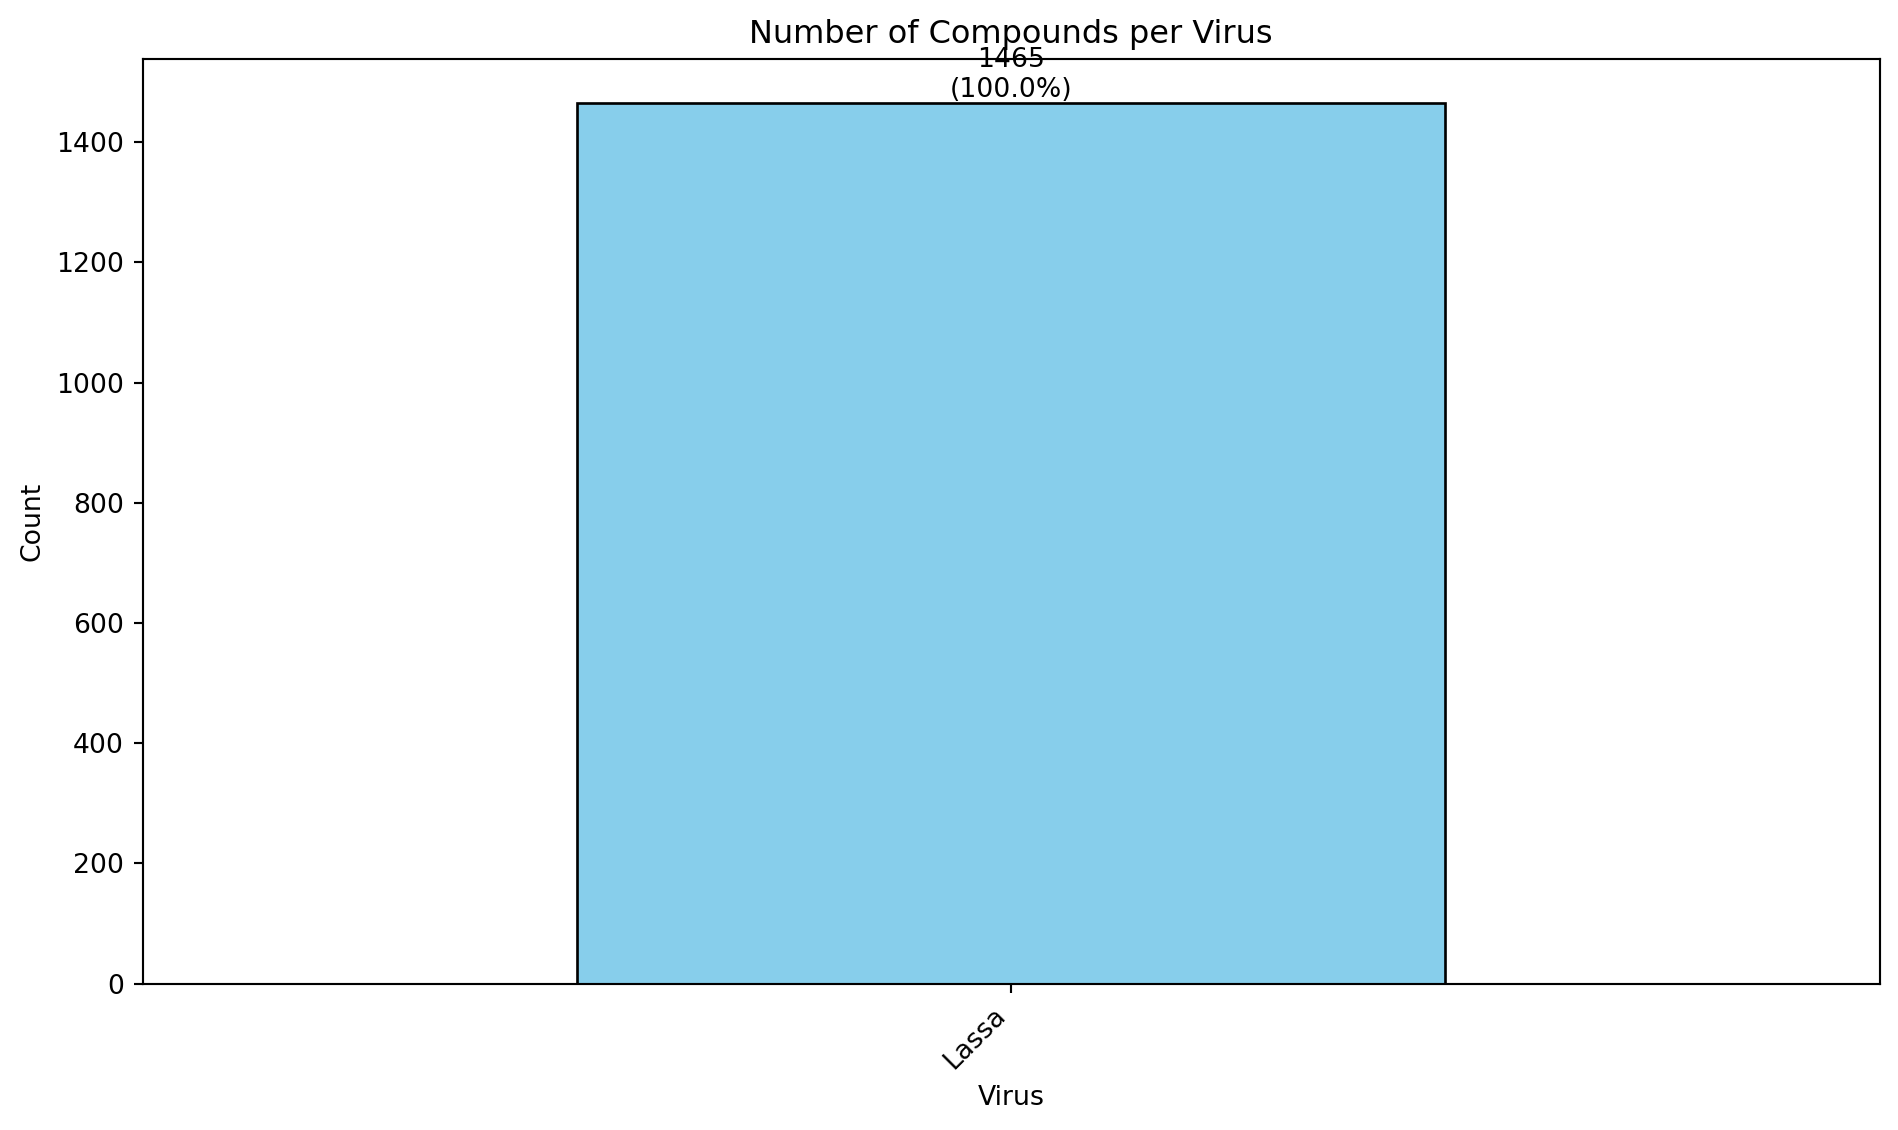

In [22]:
# Get counts and percentages
counts = LassaVirusData_allDB['VirusClassifier'].value_counts()
percentages = counts / counts.sum() * 100

# Create bar plot
plt.figure(figsize=(10, 6))
bars = counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Number of Compounds per Virus')
plt.xlabel('Virus')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Annotate each bar with count and %
for i, (count, pct) in enumerate(zip(counts, percentages)):
    plt.text(
        i, count + 1,                 # position (x, y)
        f'{count}\n({pct:.1f}%)',     # label: count + percentage
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

In [23]:
LassaVirusData_allDB.to_csv(os.path.join(modelBuildingDataDir, "LassaVirusData_allDB_MLready.csv"), index=False)

### pPotency value distribution across each Virus

In [24]:
LassaVirusData_allDB_ordered = LassaVirusData_allDB.sort_values(by='VirusClassifier')
LassaVirusData_allDB_ordered.head()

,ID,compound_id,Smiles,pPotency,VirusClassifier,pPotency_category
0,1,2259,O=C(O)C1=CC(=C(c2ccc(O)c(C(=O)O)c2)c2ccc(O)c(C...,4.000000,Lassa,3-10
980,981,122600622,COc1ccc2[nH]c(C(=O)N3CC(=O)N(Cc4ccccc4)[C@@H](...,7.250264,Lassa,3-10
979,980,122600756,O=C(c1cc2cc(C3CC3)ccc2[nH]1)N1CC(=O)N(Cc2cccc(...,6.563996,Lassa,3-10
978,979,122600441,O=C(c1cc2cc(C3CC3)ccc2[nH]1)N1CC(=O)N(Cc2ccc3c...,6.741123,Lassa,3-10
977,978,122600763,Cc1cccc(CN2C(=O)CN(C(=O)c3cc4cc(C5CC5)ccc4[nH]...,6.448550,Lassa,3-10


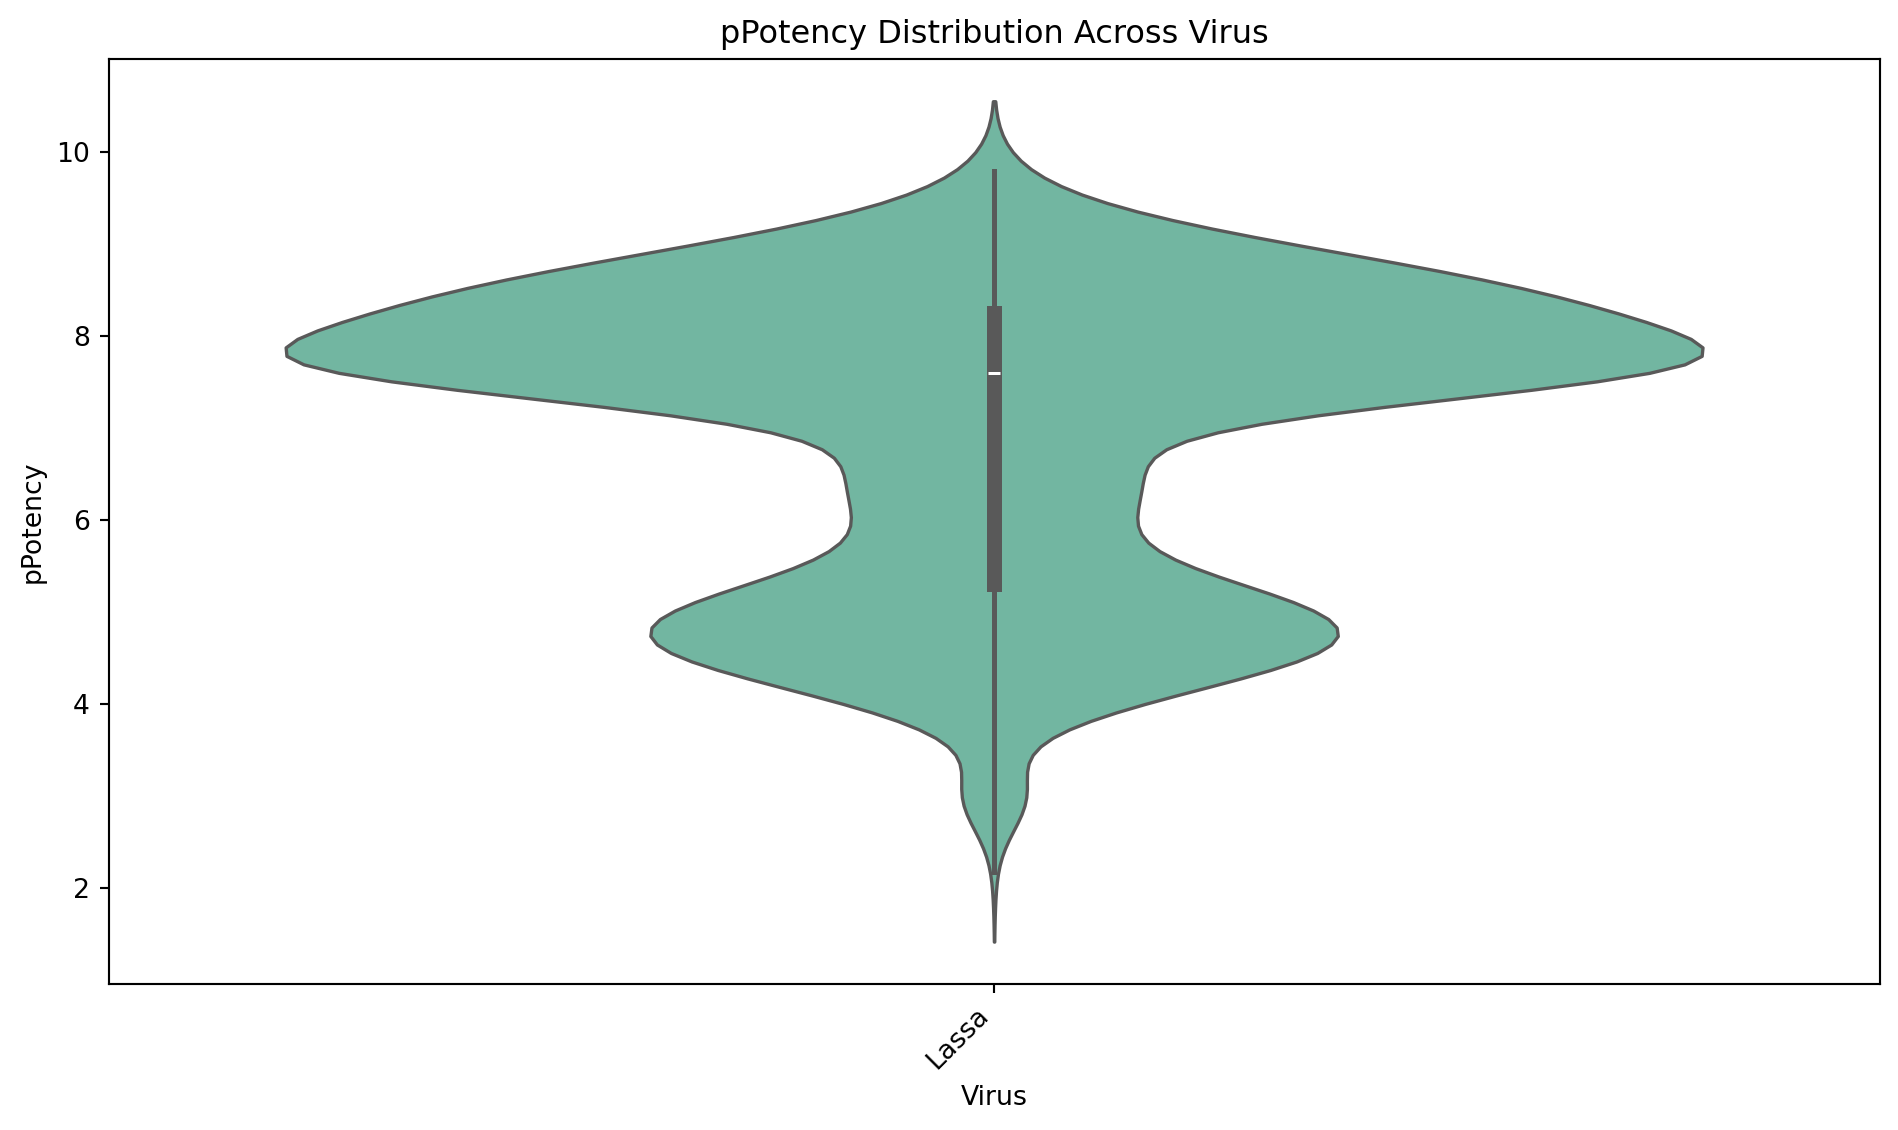

In [25]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=LassaVirusData_allDB_ordered,
    x='VirusClassifier',
    y='pPotency',
    palette='Set2',
    inner='box'
)

plt.xticks(rotation=45, ha='right')
plt.title('pPotency Distribution Across Virus')
plt.xlabel('Virus')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

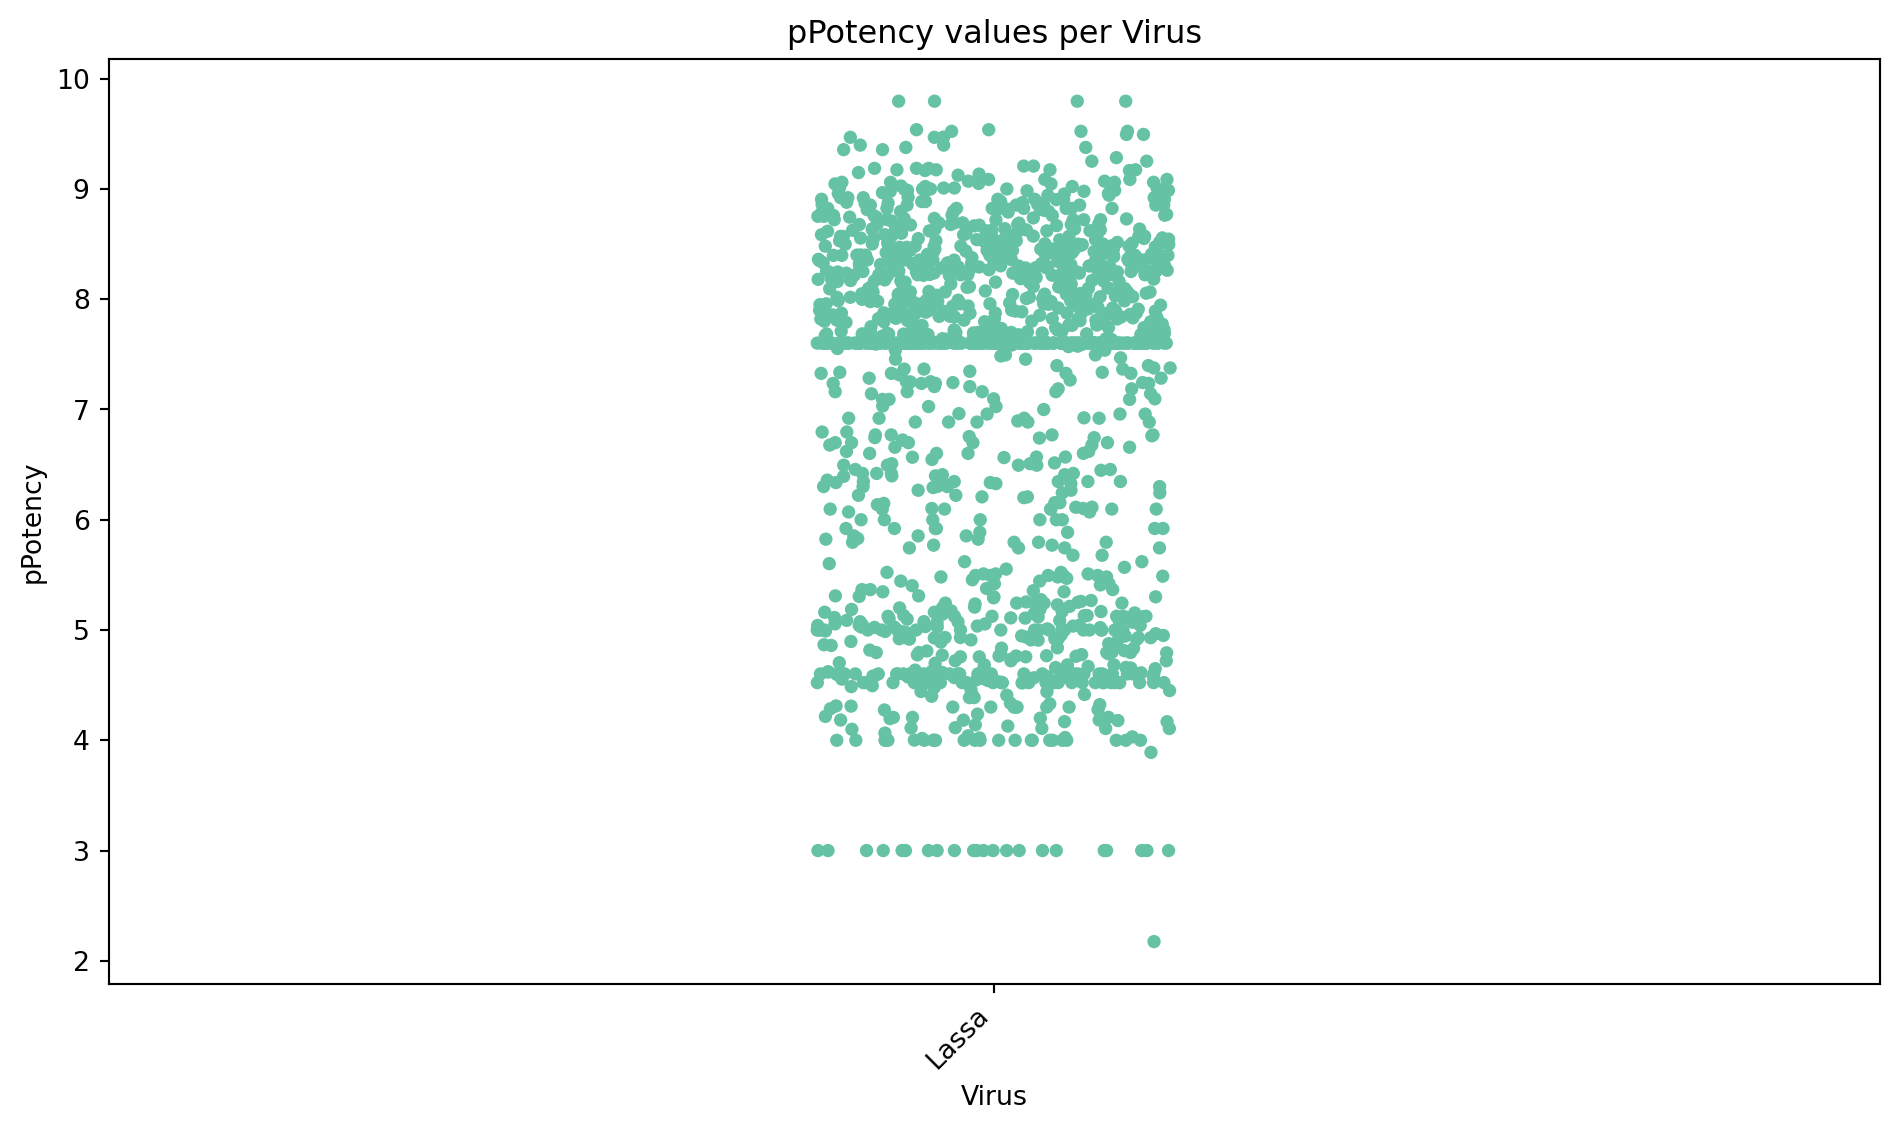

In [26]:
plt.figure(figsize=(10, 6))
sns.stripplot(
    data=LassaVirusData_allDB_ordered,
    x='VirusClassifier',
    y='pPotency',
    jitter=True,          # spreads the dots to avoid overlap
    palette='Set2',
    alpha=1
)
plt.xticks(rotation=45, ha='right')
plt.title('pPotency values per Virus')
plt.xlabel('Virus')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

### Clip first 1000 rows from the data set for fast testing

### Removing some outliers

### Train ML Model

In [27]:
# df = LassaVirusData_allDB
Y = LassaVirusData_allDB.pPotency
smiles = LassaVirusData_allDB.Smiles

#Y = LassaVirusData_allDB_woOutlier.pPotency
#smiles = LassaVirusData_allDB_woOutlier.Smiles

In [28]:
print(len(smiles))

1465


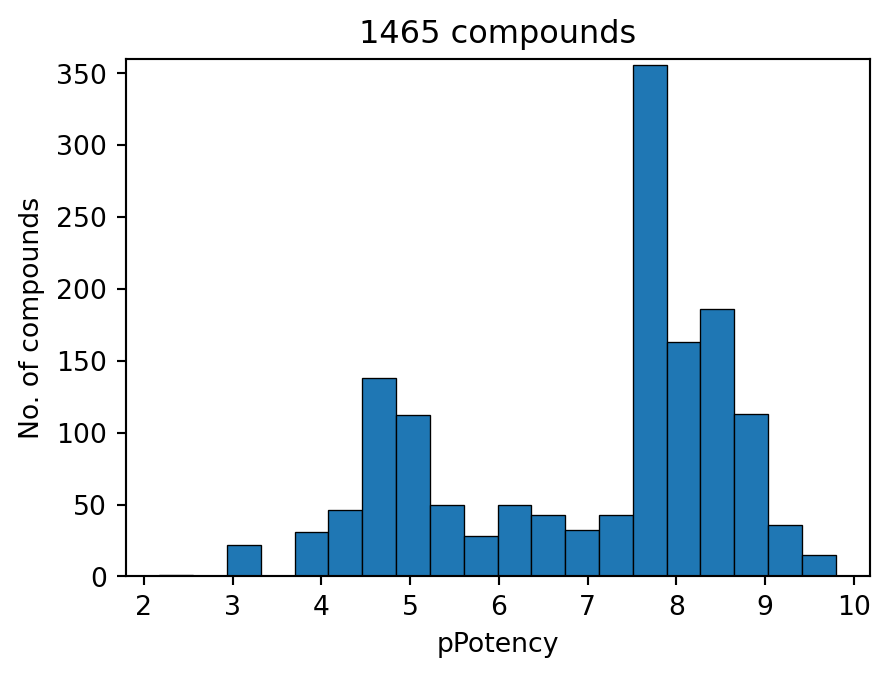

In [29]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [30]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for random forest:

In [31]:
param_grid = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500], 
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

### Find best `MACAW` parameters

In [ ]:
import numpy as np
import pandas as pd
from copy import deepcopy
from joblib import Parallel, delayed
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def processFold(
    foldId, trainIndex, testIndex,
    smiles, Y, baseMacaw, paramGrid, numFolds
):
    print(f"Fold {foldId}/{numFolds}")

    smiTrain = smiles.iloc[trainIndex]
    smiTest  = smiles.iloc[testIndex]
    yTrain   = Y.iloc[trainIndex].values
    yTest    = Y.iloc[testIndex].values

    macawFold = deepcopy(baseMacaw)
    macawFold.fit(smiTrain, yTrain)

    XTrain = macawFold.transform(smiTrain)
    XTest  = macawFold.transform(smiTest)

    grid = GridSearchCV(SVR(), paramGrid, cv=5, refit=True)
    grid.fit(XTrain, yTrain)

    yPredTrain = grid.predict(XTrain)
    yPredTest  = grid.predict(XTest)

    return {
        "yObsTrain": yTrain,
        "yPredTrain": yPredTrain,
        "yObsTest": yTest,
        "yPredTest": yPredTest,
        "bestSvrParams": grid.best_params_,
    }


# ---- manual MACAW sweep ----
nComponentsList = [15, 30, 45, 60, 90]      # set your limits
nLandmarksList  = [500, 750, 1000, 1250] # set your limits

numFolds = kf.get_n_splits(smiles)

macawResultsList = []

for nComponents in nComponentsList:
    for nLandmarks in nLandmarksList:

        baseMacaw = MACAW(
            type_fp="atompairs",
            metric="sokal",
            n_components=nComponents,
            n_landmarks=nLandmarks,
            random_state=42
        )

        foldResults = Parallel(n_jobs=4, verbose=10)(
            delayed(processFold)(
                foldId=i + 1,
                trainIndex=trainIdx,
                testIndex=testIdx,
                smiles=smiles,
                Y=Y,
                baseMacaw=baseMacaw,
                paramGrid=param_grid,
                numFolds=numFolds,
            )
            for i, (trainIdx, testIdx) in enumerate(kf.split(smiles))
        )

        yObsTrainAll  = np.concatenate([r["yObsTrain"] for r in foldResults])
        yPredTrainAll = np.concatenate([r["yPredTrain"] for r in foldResults])
        yObsTestAll   = np.concatenate([r["yObsTest"] for r in foldResults])
        yPredTestAll  = np.concatenate([r["yPredTest"] for r in foldResults])

        trainR2 = r2_score(yObsTrainAll, yPredTrainAll)
        testR2  = r2_score(yObsTestAll, yPredTestAll)
        gapR2   = trainR2 - testR2  # simple overfit indicator

        macawResultsList.append({
            "n_components": nComponents,
            "n_landmarks": nLandmarks,
            "trainR2": trainR2,
            "testR2": testR2,
            "gapR2": gapR2,
            "testMAE": mean_absolute_error(yObsTestAll, yPredTestAll),
            "testRMSE": np.sqrt(mean_squared_error(yObsTestAll, yPredTestAll)),
        })

        print(
            f"MACAW(n_components={nComponents}, n_landmarks={nLandmarks}) "
            f"=> Test R²={testR2:.3f}, Train R²={trainR2:.3f}, Gap={gapR2:.3f}"
        )

macawResultsDF = pd.DataFrame(macawResultsList)

# ---- Choose best generalization: max test R² ----
bestGeneralizationRow = macawResultsDF.sort_values("testR2", ascending=False).iloc[0]
print("\nBest MACAW by generalization (highest CV Test R²):")
print(bestGeneralizationRow)

# If you want to penalize overfitting, sort by (testR2 - alpha*gapR2)
alpha = 0.5
macawResultsDF["generalizationScore"] = macawResultsDF["testR2"] - alpha * macawResultsDF["gapR2"]
bestPenalizedRow = macawResultsDF.sort_values("generalizationScore", ascending=False).iloc[0]
print("\nBest MACAW by penalized generalization score:")
print(bestPenalizedRow)

macawResultsDF.sort_values("testR2", ascending=False)

MACAW(n_components=15, n_landmarks=500) => Test R²=-0.135, Train R²=-0.134, Gap=0.001


### Run cross validation with best `MACAW` parameters

In [ ]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=1000, 
    random_state=42
)


After cleaning NaN values, reset the indices

In [ ]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True)            

print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

### ML predictions with Train + Test results

In [ ]:
%%time
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor             # <-- changed
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import Parallel, delayed
from copy import deepcopy

# <-- changed
param_grid = {
    "n_estimators":      [100, 300, 500],
    "max_depth":         [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "max_features":      ["sqrt", "log2"],
}

def process_fold(fold_id, train_index, test_index, smiles, Y, mcw, param_grid, num_partitions):
    """Process a single CV fold"""
    print(f"Partition {fold_id}/{num_partitions}")

    # Split data
    smi_train = smiles.iloc[train_index]
    smi_test  = smiles.iloc[test_index]
    y_train   = Y[train_index]
    y_test    = Y[test_index]

    # Compute MACAW embeddings (clone to avoid conflicts)
    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)

    X_train = mcw_fold.transform(smi_train)
    X_test  = mcw_fold.transform(smi_test)

    # Optimize hyperparameters
    grid = GridSearchCV(
        RandomForestRegressor(random_state=42),               # <-- changed
        param_grid,
        cv=5,
        refit=True,
        n_jobs=-1                                             # parallelize inner CV
    )
    grid.fit(X_train, y_train)

    best_params = grid.best_params_

    # Predict on both train and test
    y_cv_pred_train = grid.predict(X_train)
    y_cv_pred_test  = grid.predict(X_test)

    # Calculate fold metrics
    train_mae = mean_absolute_error(y_train, y_cv_pred_train)
    test_mae  = mean_absolute_error(y_test,  y_cv_pred_test)
    print(f"  Fold {fold_id} - Train MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")

    return {
        'train_pred':  y_cv_pred_train,
        'train_obs':   y_train,
        'test_pred':   y_cv_pred_test,
        'test_obs':    y_test,
        'best_params': best_params
    }

# Parallel execution
results = Parallel(n_jobs=4, verbose=10)(
    delayed(process_fold)(
        fold_id=i+1,
        train_index=train_idx,
        test_index=test_idx,
        smiles=smiles,
        Y=Y,
        mcw=mcw,
        param_grid=param_grid,
        num_partitions=num_of_partitions
    )
    for i, (train_idx, test_idx) in enumerate(kf.split(smiles))
)

# Combine results
Y_cv_pred_train    = []
Y_obs_train        = []
Y_cv_pred_test     = []
Y_obs_test         = []
best_params_per_fold = []

for fold_result in results:
    Y_cv_pred_train.extend(fold_result['train_pred'])
    Y_obs_train.extend(fold_result['train_obs'])
    Y_cv_pred_test.extend(fold_result['test_pred'])
    Y_obs_test.extend(fold_result['test_obs'])
    best_params_per_fold.append(fold_result['best_params'])

# Convert to numpy arrays
Y_cv_pred_train = np.array(Y_cv_pred_train)
Y_obs_train     = np.array(Y_obs_train)
Y_cv_pred_test  = np.array(Y_cv_pred_test)
Y_obs_test      = np.array(Y_obs_test)

# ===== OVERALL METRICS =====
print("\n" + "-"*40)
print("Cross Validation Metrics")
print("-"*40)

train_mae  = mean_absolute_error(Y_obs_train, Y_cv_pred_train)
train_rmse = np.sqrt(mean_squared_error(Y_obs_train, Y_cv_pred_train))
train_r2   = r2_score(Y_obs_train, Y_cv_pred_train)

print(f"Train Set:")
print(f"  MAE:  {train_mae:.2f}")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  R²:   {train_r2:.2f}")

test_mae  = mean_absolute_error(Y_obs_test, Y_cv_pred_test)
test_rmse = np.sqrt(mean_squared_error(Y_obs_test, Y_cv_pred_test))
test_r2   = r2_score(Y_obs_test, Y_cv_pred_test)

print(f"Test Set:")
print(f"  MAE:  {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  R²:   {test_r2:.2f}")

print(f"\nBest params (sample): {best_params_per_fold[:3]}")

In [ ]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=saveDir + 'LassaVirus_CV_TrTs.svg',
            save_formats=['svg', 'png'])

### Create MACAW embeedings to run ART

In [ ]:
# ---------------------------
# 1. FIT MACAW AND GENERATE EMBEDDINGS
# ---------------------------
# Initialize MACAW
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=45, 
    n_landmarks=1250, 
    random_state=42
)

# Fit MACAW on SMILES and pPotency
mcw.fit(LassaVirusData_allDB['Smiles'], LassaVirusData_allDB['pPotency'])

# Save MACAW transformer
macaw_save_path = os.path.join(modelBuildingDataDir, "LassaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_save_path, 'wb') as f:
    pickle.dump(mcw, f)
print(f"MACAW transformer saved to: {macaw_save_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(LassaVirusData_allDB['Smiles'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# ---------------------------
# 2. CREATE DATAFRAME WITH EMBEDDINGS
# ---------------------------
# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=LassaVirusData_allDB.index)

# ---------------------------
# 3. CONCATENATE WITH ORIGINAL DATAFRAME
# ---------------------------
LassaVirusData_allDB_wMACAW = pd.concat([LassaVirusData_allDB, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {LassaVirusData_allDB.shape}")
print(f"New dataframe shape: {LassaVirusData_allDB_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
LassaVirusData_allDB_wMACAW

In [ ]:
LassaVirusData_allDB_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "LassaVirusData_allDB_wMACAW.csv"), index=False)

### Use ART to get predictions

## 2.1 Create a list of data frames of buyable antivirals: `Enamine, ChemDiv, LifeChemicals`

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [ ]:
EnamineAntiviralsData = pd.read_csv(dataDir + "Enamine/Enamine_Antiviral_Library_plated_3200cmpds_20251019.csv",
                                    sep=",", comment=None, skipinitialspace=True, engine="python", encoding="utf-8",          
                                    skiprows=1, skip_blank_lines=True)
print(f"Original Enamine data shape: {EnamineAntiviralsData.shape}")

smiles_train = LassaVirusData_allDB_wMACAW.Smiles

# Function to canonicalize SMILES using RDKit
def canonicalize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            return Chem.MolToSmiles(mol, canonical=True)
        else:
            return None
    except:
        return None

# Canonicalize training SMILES and create a set for fast lookup
canonical_train = set()
for smi in smiles_train:
    canonical_smi = canonicalize_smiles(smi)
    if canonical_smi is not None:
        canonical_train.add(canonical_smi)

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to Enamine data
EnamineAntiviralsData['Canonical_SMILES'] = EnamineAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~EnamineAntiviralsData['Canonical_SMILES'].isin(canonical_train)
EnamineAntiviralsData_filtered = EnamineAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
EnamineAntiviralsData = EnamineAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered Enamine data shape for validation: {EnamineAntiviralsData.shape}")
print(f"Removed {EnamineAntiviralsData.shape[0] - EnamineAntiviralsData_filtered.shape[0]} duplicate compounds from Enamine data set")

# Now use the filtered data
smi_lib_EnamineDataset = EnamineAntiviralsData.SMILES
EnamineAntiviralsData['source_DataBase'] = 'Enamine_Antivirals'
needed_cols = ['SMILES', 'source_DataBase']
EnamineAntiviralsData = EnamineAntiviralsData[needed_cols]

print(f"Total compounds to screen: {len(smi_lib_EnamineDataset)}")
EnamineAntiviralsData.head()

In [ ]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "LifeChemicals/LC_Merged_Antiviral_Screening_Superset.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

LCAntiviralsData_superset = pd.DataFrame(records)
print(f"Original LifeChemicals data shape: {LCAntiviralsData_superset.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to LifeChemicals data (reusing canonical_train from code-1)
LCAntiviralsData_superset['Canonical_SMILES'] = LCAntiviralsData_superset['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~LCAntiviralsData_superset['Canonical_SMILES'].isin(canonical_train)
LCAntiviralsData_superset_filtered = LCAntiviralsData_superset[mask].copy()

# Remove the helper column if you don't need it
LCAntiviralsData_superset = LCAntiviralsData_superset_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered LifeChemicals data shape for validation: {LCAntiviralsData_superset.shape}")
print(f"Removed {LCAntiviralsData_superset_filtered.shape[0] - LCAntiviralsData_superset.shape[0]} duplicate compounds from LifeChemicals data set")

# Now use the filtered data
smi_lib_LCAntiviralsData = LCAntiviralsData_superset.SMILES
LCAntiviralsData_superset['source_DataBase'] = 'LifeChemicals_Antivirals'
needed_cols = ['SMILES', 'source_DataBase']
LCAntiviralsData_superset = LCAntiviralsData_superset[needed_cols]

print(f"Total compounds to screen: {len(smi_lib_LCAntiviralsData)}")
LCAntiviralsData_superset.head()

In [ ]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "ChemDiv/ChemDiv_Antiviral-Library-64958.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

ChemDivAntiviralsData = pd.DataFrame(records)
print(f"Original ChemDiv data shape: {ChemDivAntiviralsData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to ChemDiv data (reusing canonical_train from previous code)
ChemDivAntiviralsData['Canonical_SMILES'] = ChemDivAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~ChemDivAntiviralsData['Canonical_SMILES'].isin(canonical_train)
ChemDivAntiviralsData_filtered = ChemDivAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
ChemDivAntiviralsData = ChemDivAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered ChemDiv data shape for validation: {ChemDivAntiviralsData.shape}")
print(f"Removed {ChemDivAntiviralsData_filtered.shape[0] - ChemDivAntiviralsData.shape[0]} duplicate compounds from ChemDiv data set")

# Now use the filtered data
smi_lib_ChemDivAntiviralsData = ChemDivAntiviralsData.SMILES
ChemDivAntiviralsData['source_DataBase'] = 'ChemDiv_Antivirals'
needed_cols = ['SMILES', 'source_DataBase']
ChemDivAntiviralsData = ChemDivAntiviralsData[needed_cols]

print(f"Total compounds to screen: {len(smi_lib_ChemDivAntiviralsData)}")
ChemDivAntiviralsData

In [ ]:
%%time

# Concatenate in chunks and free memory 
DF_list = [
    EnamineAntiviralsData,
    LCAntiviralsData_superset,
    ChemDivAntiviralsData,
]

Lassa_all_Buyable_AntiVirals = pd.concat(DF_list, ignore_index=True)

# Free memory from individual dataframes
del EnamineAntiviralsData
del LCAntiviralsData_superset
del ChemDivAntiviralsData
gc.collect()

print(f"Total molecules before deduplication: {len(Lassa_all_Buyable_AntiVirals)}")

# Batch canonicalize SMILES using vectorized approach
def canonicalize_smiles_batch(smiles_series, batch_size=50000):
    results = []
    for i in range(0, len(smiles_series), batch_size):
        batch = smiles_series.iloc[i:i + batch_size]
        canonical = []
        for smi in batch:
            try:
                mol = Chem.MolFromSmiles(smi)
                if mol is not None:
                    canonical.append(Chem.MolToSmiles(mol))
                else:
                    canonical.append(None)
            except:
                canonical.append(None)
        results.extend(canonical)
        print(f"  Processed {min(i + batch_size, len(smiles_series))}/{len(smiles_series)} SMILES...")
        gc.collect()
    return results

print("Canonicalizing SMILES...")
Lassa_all_Buyable_AntiVirals['SMILES'] = canonicalize_smiles_batch(Lassa_all_Buyable_AntiVirals['SMILES'])

# Drop invalid and duplicate SMILES
Lassa_all_Buyable_AntiVirals = Lassa_all_Buyable_AntiVirals.dropna(subset=['SMILES'])
Lassa_all_Buyable_AntiVirals = Lassa_all_Buyable_AntiVirals.drop_duplicates(subset='SMILES', keep='first')
Lassa_all_Buyable_AntiVirals = Lassa_all_Buyable_AntiVirals.reset_index(drop=True)
gc.collect()

print(f"Total molecules after deduplication: {len(Lassa_all_Buyable_AntiVirals)}")

# save to a file path string
output_path = saveDir + "Lassa_all_Buyable_AntiVirals.csv"
Lassa_all_Buyable_AntiVirals.to_csv(output_path, index=False, encoding="utf-8")
print(f"Saved to {output_path}")

Lassa_all_Buyable_AntiVirals

### Generate `MACAW` embeedings for all buyable molecules --> to run external validation with `ART`

In [ ]:
# ---------------------------
# 1. LOAD MACAW TRANSFORMER AND GENERATE EMBEDDINGS
# ---------------------------
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(modelBuildingDataDir, "LassaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(Lassa_all_Buyable_AntiVirals['SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# ---------------------------
# 2. CREATE DATAFRAME WITH EMBEDDINGS
# ---------------------------
# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=Lassa_all_Buyable_AntiVirals.index)

# ---------------------------
# 3. CONCATENATE WITH ORIGINAL DATAFRAME
# ---------------------------
Lassa_all_Buyable_AntiVirals_wMACAW = pd.concat([Lassa_all_Buyable_AntiVirals, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {Lassa_all_Buyable_AntiVirals.shape}")
print(f"New dataframe shape: {Lassa_all_Buyable_AntiVirals_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
Lassa_all_Buyable_AntiVirals_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "Lassa_all_Buyable_AntiVirals_wMACAW.csv"), index=False)
Lassa_all_Buyable_AntiVirals_wMACAW.head()

### Read results (`SMILES` & `Ppotency`) from `ART` post predictions with uncertentity

In [ ]:
Lassa_all_Buyable_AntiVirals_wARTprediction = pd.read_csv(ARTresultsDir + 'LassaVirus_wART_EnamineDataset_predicted_all.csv')
max_val = Lassa_all_Buyable_AntiVirals_wARTprediction['pPotency_prediction'].max()
min_val = Lassa_all_Buyable_AntiVirals_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

Lassa_all_Buyable_AntiVirals_wARTprediction

### Extract `pPotency` predictions

In [ ]:
predicted_pPotency = Lassa_all_Buyable_AntiVirals_wARTprediction['pPotency_prediction'].values

### Filter out `top 20` compounds with higher `pPotency`

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]  # Last (20th) value
highest_pPotency = predicted_pPotency[top_20_idx[0]]   # First (1st) value

# Convert to IC50 in µM
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} (IC50: {cutoff_IC50_uM:.4f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} (IC50: {best_IC50_uM:.4f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} - {highest_pPotency:.2f}; IC50 --> {cutoff_IC50_uM:.3f} - {best_IC50_uM:.4f} µM")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

# Create dataframe with top 20
Lassa_all_Buyable_AntiVirals_wARTprediction_top20 = Lassa_all_Buyable_AntiVirals_wARTprediction.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
Lassa_all_Buyable_AntiVirals_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)

# Add IC50 column in micromolar (µM)
# IC50 (µM) = 10^(-pPotency) * 1e6
Lassa_all_Buyable_AntiVirals_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6

# Add rank column at the beginning
Lassa_all_Buyable_AntiVirals_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = predicted_pPotency[top_20_idx[0]]   # Highest (best)
pPotency_min = predicted_pPotency[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min_uM = 10**(-pPotency_max) * 1e6            # Lowest IC50 (most potent)
IC50_max_uM = 10**(-pPotency_min) * 1e6            # Highest IC50 (least potent in top 20)

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max_uM:.4f} µM")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min_uM:.4f} µM")

print("\nRange for Top 20 Compounds:")
print(f"pPotency Range:   {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"IC50 Range (µM):  {IC50_max_uM:.4f} - {IC50_min_uM:.4f}")

# Set pandas display options
pd.options.display.float_format = lambda x: f'{x:.4f}'

# Display the dataframe
Lassa_all_Buyable_AntiVirals_wARTprediction_top20 = Lassa_all_Buyable_AntiVirals_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
Lassa_all_Buyable_AntiVirals_wARTprediction_top20

In [ ]:
Lassa_all_Buyable_AntiVirals_wARTprediction_top20.to_csv(os.path.join(saveDir + "Lassa_all_Buyable_AntiVirals_wARTprediction_top20.csv"), index=False)
Lassa_all_Buyable_AntiVirals_wARTprediction_top20[['SMILES']].to_csv(os.path.join(saveDir + "Lassa_all_Buyable_AntiVirals_wARTprediction_top20_SMILESonly.csv"), index=False)

In [ ]:
# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in Lassa_all_Buyable_AntiVirals_wARTprediction_top20.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in Lassa_all_Buyable_AntiVirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'Lassa_all_Buyable_AntiVirals_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'Lassa_all_Buyable_AntiVirals_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)

### Save molecules as .gif

In [ ]:
# Get molecules and legends
molecules = [Chem.MolFromSmiles(smi) for smi in Lassa_all_Buyable_AntiVirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Lassa_all_Buyable_AntiVirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

# Split molecules into chunks of 4 for each frame
mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]
    
    # Generate grid image: 1 column (vertical layout), 4 rows
    frame_img = Draw.MolsToGridImage(
        chunk_mols,
        subImgSize=(400, 300),
        molsPerRow=1,  # 1 per row = vertical arrangement
        useSVG=False,
        legends=chunk_legends,
        returnPNG=False
    )
    
    # Convert to RGB if necessary (GIF requires consistent mode)
    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')
    
    frames.append(frame_img)

# Save as GIF
output_gif = saveDir + 'Lassa_all_Buyable_AntiVirals_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif,
    save_all=True,
    append_images=frames[1:],
    duration=3000,  # 3 seconds per frame
    loop=0,         # 0 = infinite loop
    optimize=True
)
print(f"Saved GIF: {output_gif}")

# Display in notebook
from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

### Add back `source_DataBase` column to keep track of the data base information for the compound

In [ ]:
# Keep only the lookup columns (and drop duplicate SMILES to avoid row explosion)
lookupDF = (
    Lassa_all_Buyable_AntiVirals[["SMILES", "source_DataBase"]]
    .dropna(subset=["SMILES"])
    .drop_duplicates(subset=["SMILES"], keep="first")
)

# Left-merge so every prediction row is preserved; source_DataBase is appended as the last column
Lassa_all_Buyable_AntiVirals_wARTprediction_top20 = Lassa_all_Buyable_AntiVirals_wARTprediction_top20.merge(
    lookupDF,
    how="left",
    on="SMILES",
    validate="many_to_one"  # many predictions can map to one SMILES in lookup
)

Lassa_all_Buyable_AntiVirals_wARTprediction_top20

# <span style="color: #1e88e5;">Load <code>DORANET</code> generated molecules data</span>

### Import all compounds generated by `DORAnet` from `Inosine` only (gen=3) --> Possible `Antivirals`

In [ ]:
InosineOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "InosineDORAnetGeneratedMolecules_gen3.csv", dtype=str)
print(f"Loaded {len(InosineOnly_DORAnetGenerated)} molecules")
InosineOnly_DORAnetGenerated

### Import all compounds generated by `DORAnet` from `Adenosine` only (gen=3) --> Possible `Antivirals`

In [ ]:
AdenosineOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "AdenosineDORAnetGeneratedMolecules_gen3.csv", dtype=str)
print(f"Loaded {len(AdenosineOnly_DORAnetGenerated)} molecules")
AdenosineOnly_DORAnetGenerated['SourceDirectories'] = 'AdenosineOnly_gen3'
AdenosineOnly_DORAnetGenerated

### Import all compounds generated by `DORAnet` from `Guanosine` only (gen=3) --> Possible `Antivirals`

In [ ]:
GuanosineOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "GuanosineDORAnetGeneratedMolecules_gen3.csv", dtype=str)
print(f"Loaded {len(GuanosineOnly_DORAnetGenerated)} molecules")
GuanosineOnly_DORAnetGenerated

### Import all compounds generated by `DORAnet` from `Xanthosine` only (gen=3) --> Possible `Antivirals`

In [ ]:
XanthosineOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "XanthosineDORAnetGeneratedMolecules_gen3.csv", dtype=str)
print(f"Loaded {len(XanthosineOnly_DORAnetGenerated)} molecules")
XanthosineOnly_DORAnetGenerated

### Marge the data for all `DORAnet` generated `Antivirals` for different starter molecule

In [ ]:
%%time

# Concatenate in chunks and free memory ---
DF_list = [
    InosineOnly_DORAnetGenerated,
    AdenosineOnly_DORAnetGenerated,
    GuanosineOnly_DORAnetGenerated,
    XanthosineOnly_DORAnetGenerated,
]

Lassa_allDORAnetGenerated_Antivirals = pd.concat(DF_list, ignore_index=True)

# Free memory from individual dataframes
del InosineOnly_DORAnetGenerated
del AdenosineOnly_DORAnetGenerated
del GuanosineOnly_DORAnetGenerated
del XanthosineOnly_DORAnetGenerated
gc.collect()

print(f"Total molecules before deduplication: {len(Lassa_allDORAnetGenerated_Antivirals)}")

# --- 2. Only keep needed columns early ---
#needed_cols = ['SMILES', 'Is_Starter', 'SourceDirectories', 'source_DataBase']
#Lassa_allDORAnetGenerated_Antivirals = Lassa_allDORAnetGenerated_Antivirals[needed_cols]

# --- 3. Batch canonicalize SMILES using vectorized approach ---
def canonicalize_smiles_batch(smiles_series, batch_size=50000):
    results = []
    for i in range(0, len(smiles_series), batch_size):
        batch = smiles_series.iloc[i:i + batch_size]
        canonical = []
        for smi in batch:
            try:
                mol = Chem.MolFromSmiles(smi)
                if mol is not None:
                    canonical.append(Chem.MolToSmiles(mol))
                else:
                    canonical.append(None)
            except:
                canonical.append(None)
        results.extend(canonical)
        print(f"  Processed {min(i + batch_size, len(smiles_series))}/{len(smiles_series)} SMILES...")
        gc.collect()
    return results

print("Canonicalizing SMILES...")
Lassa_allDORAnetGenerated_Antivirals['SMILES'] = canonicalize_smiles_batch(Lassa_allDORAnetGenerated_Antivirals['SMILES'])

# --- 4. Drop invalid and duplicate SMILES ---
Lassa_allDORAnetGenerated_Antivirals = Lassa_allDORAnetGenerated_Antivirals.dropna(subset=['SMILES'])
Lassa_allDORAnetGenerated_Antivirals = Lassa_allDORAnetGenerated_Antivirals.drop_duplicates(subset='SMILES', keep='first')
Lassa_allDORAnetGenerated_Antivirals = Lassa_allDORAnetGenerated_Antivirals.reset_index(drop=True)
gc.collect()

print(f"Total molecules after deduplication: {len(Lassa_allDORAnetGenerated_Antivirals)}")

# --- 5. Fix: save to a file path string, not the dataframe variable ---
output_path = DORANETmoleculesDataDir + "Lassa_allDORAnetGenerated_Antivirals.csv"
Lassa_allDORAnetGenerated_Antivirals.to_csv(output_path, index=False, encoding="utf-8")
print(f"Saved to {output_path}")

Lassa_allDORAnetGenerated_Antivirals

### Generate `MACAW` embeedings for `DORAnet` generated molecules --> to run external validation with `ART`

In [ ]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(modelBuildingDataDir, "LassaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(Lassa_allDORAnetGenerated_Antivirals['SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=Lassa_allDORAnetGenerated_Antivirals.index)
Lassa_allDORAnetGenerated_Antivirals_wMACAW = pd.concat([Lassa_allDORAnetGenerated_Antivirals, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {Lassa_allDORAnetGenerated_Antivirals.shape}")
print(f"New dataframe shape: {Lassa_allDORAnetGenerated_Antivirals_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
Lassa_allDORAnetGenerated_Antivirals_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "Lassa_allDORAnetGenerated_Antivirals_wMACAW.csv"), index=False)
Lassa_allDORAnetGenerated_Antivirals_wMACAW.head()

## Read results (`SMILES` & `pPotency`) from `ART` post predictions with uncertentity

In [ ]:
Lassa_allDORAnetGenerated_Antivirals_wARTprediction = pd.read_csv(ARTresultsDir + 'Lassa_allDORAnetGenerated_Antivirals_ARTprediction.csv')
max_val = Lassa_allDORAnetGenerated_Antivirals_wARTprediction['pPotency_prediction'].max()
min_val = Lassa_allDORAnetGenerated_Antivirals_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

Lassa_allDORAnetGenerated_Antivirals_wARTprediction

In [ ]:
def get_top20_range(df, group_name):
    top20 = df.nlargest(20, 'pPotency_prediction')
    best = top20.iloc[0]
    cutoff = top20.iloc[-1]
    return {
        'SourceDirectories': group_name,
        'Total Molecules': len(df),
        'pPotency Range': f"{cutoff['pPotency_prediction']:.3f} ± {cutoff['pPotency_std']:.3f} – {best['pPotency_prediction']:.3f} ± {best['pPotency_std']:.3f}",
        'IC50 (µM)': f"{best['IC50(M)_prediction'] * 1e6:.4f} – {cutoff['IC50(M)_prediction'] * 1e6:.4f}",
    }

rows = [get_top20_range(Lassa_allDORAnetGenerated_Antivirals_wARTprediction, "all Molecules")]

for source in sorted(Lassa_allDORAnetGenerated_Antivirals_wARTprediction['SourceDirectories'].unique()):
    subset = Lassa_allDORAnetGenerated_Antivirals_wARTprediction[
        Lassa_allDORAnetGenerated_Antivirals_wARTprediction['SourceDirectories'] == source
    ]
    rows.append(get_top20_range(subset, source))

Lassa_allDORAnetGenerated_Antivirals_wARTprediction_summary = pd.DataFrame(rows)
Lassa_allDORAnetGenerated_Antivirals_wARTprediction_summary

### Filter out `top 20` compounds with higher `pPotency` from all `DORAnet` generated molecules

In [ ]:
predicted_pPotency = Lassa_allDORAnetGenerated_Antivirals_wARTprediction['pPotency_prediction'].values
predicted_pPotency_std = Lassa_allDORAnetGenerated_Antivirals_wARTprediction['pPotency_std'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]
highest_pPotency = predicted_pPotency[top_20_idx[0]]
cutoff_std = predicted_pPotency_std[top_20_idx[-1]]
highest_std = predicted_pPotency_std[top_20_idx[0]]
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} ± {cutoff_std:.2f} (IC50: {cutoff_IC50_uM:.4f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} ± {highest_std:.2f} (IC50: {best_IC50_uM:.4f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} ± {cutoff_std:.2f} - {highest_pPotency:.2f} ± {highest_std:.2f}; IC50 --> {cutoff_IC50_uM:.4f} - {best_IC50_uM:.4f} µM")

In [ ]:
Lassa_allDORAnetGenerated_Antivirals_wARTprediction_top20 = Lassa_allDORAnetGenerated_Antivirals_wARTprediction.iloc[top_20_idx].copy()
Lassa_allDORAnetGenerated_Antivirals_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)
Lassa_allDORAnetGenerated_Antivirals_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6
Lassa_allDORAnetGenerated_Antivirals_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

pd.options.display.float_format = lambda x: f'{x:.4f}'

Lassa_allDORAnetGenerated_Antivirals_wARTprediction_top20 = Lassa_allDORAnetGenerated_Antivirals_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
Lassa_allDORAnetGenerated_Antivirals_wARTprediction_top20

output_csv = os.path.join(saveDir, "Lassa_allDORAnetGenerated_Antivirals_wARTprediction_top20.csv")
output_smiles_csv = os.path.join(saveDir, "Lassa_allDORAnetGenerated_Antivirals_wARTprediction_top20_SMILESonly.csv")
Lassa_allDORAnetGenerated_Antivirals_wARTprediction_top20.to_csv(output_csv, index=False)
Lassa_allDORAnetGenerated_Antivirals_wARTprediction_top20[['SMILES']].to_csv(output_smiles_csv, index=False)
print(f" Saved results: {output_csv}")
print(f" Saved SMILES:  {output_smiles_csv}")

Lassa_allDORAnetGenerated_Antivirals_wARTprediction_top20

### Display molecules

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in Lassa_allDORAnetGenerated_Antivirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Lassa_allDORAnetGenerated_Antivirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} ± {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

img = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=False, legends=legends, returnPNG=False
)

output_png = saveDir + 'Lassa_allDORAnetGenerated_Antivirals_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

svg = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=True, legends=legends
)

output_svg = saveDir + 'Lassa_allDORAnetGenerated_Antivirals_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")

display(img)

### Display molecules in `.gif`

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in Lassa_allDORAnetGenerated_Antivirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Lassa_allDORAnetGenerated_Antivirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]

    frame_img = Draw.MolsToGridImage(
        chunk_mols, subImgSize=(400, 300), molsPerRow=1,
        useSVG=False, legends=chunk_legends, returnPNG=False
    )

    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')

    frames.append(frame_img)

output_gif = saveDir + 'Lassa_allDORAnetGenerated_Antivirals_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif, save_all=True, append_images=frames[1:],
    duration=3000, loop=2, optimize=True
)
print(f"Saved GIF: {output_gif}")

from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

## Top20 potent compound generated from `Inosine` only `DORAnet` run

In [ ]:
Lassa_allDORAnetGenerated_Antivirals_wARTprediction = pd.read_csv(ARTresultsDir + 'Lassa_allDORAnetGenerated_Antivirals_ARTprediction.csv')

Lassa_InosineOnly_Antivirals_wARTprediction = Lassa_allDORAnetGenerated_Antivirals_wARTprediction[
    Lassa_allDORAnetGenerated_Antivirals_wARTprediction['SourceDirectories'] == 'InosineOnly_gen3'].reset_index(drop=True)

print(f"Total molecules: {len(Lassa_allDORAnetGenerated_Antivirals_wARTprediction)}")
print(f"DORAnet molecules generated by Inosine only: {len(Lassa_InosineOnly_Antivirals_wARTprediction)}")

max_val = Lassa_InosineOnly_Antivirals_wARTprediction['pPotency_prediction'].max()
min_val = Lassa_InosineOnly_Antivirals_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

Lassa_InosineOnly_Antivirals_wARTprediction

### Filter out `top 20` compounds with higher `pPotency`

In [ ]:
predicted_pPotency = Lassa_InosineOnly_Antivirals_wARTprediction['pPotency_prediction'].values
predicted_pPotency_std = Lassa_InosineOnly_Antivirals_wARTprediction['pPotency_std'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]
highest_pPotency = predicted_pPotency[top_20_idx[0]]
cutoff_std = predicted_pPotency_std[top_20_idx[-1]]
highest_std = predicted_pPotency_std[top_20_idx[0]]
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} ± {cutoff_std:.2f} (IC50: {cutoff_IC50_uM:.4f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} ± {highest_std:.2f} (IC50: {best_IC50_uM:.4f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} ± {cutoff_std:.2f} - {highest_pPotency:.2f} ± {highest_std:.2f}; IC50 --> {cutoff_IC50_uM:.4f} - {best_IC50_uM:.4f} µM")

In [ ]:
Lassa_InosineOnly_Antivirals_wARTprediction_top20 = Lassa_InosineOnly_Antivirals_wARTprediction.iloc[top_20_idx].copy()
Lassa_InosineOnly_Antivirals_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)
Lassa_InosineOnly_Antivirals_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6
Lassa_InosineOnly_Antivirals_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

pd.options.display.float_format = lambda x: f'{x:.4f}'

Lassa_InosineOnly_Antivirals_wARTprediction_top20 = Lassa_InosineOnly_Antivirals_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
Lassa_InosineOnly_Antivirals_wARTprediction_top20

output_csv = os.path.join(saveDir, "Lassa_InosineOnly_Antivirals_wARTprediction_top20.csv")
output_smiles_csv = os.path.join(saveDir, "Lassa_InosineOnly_Antivirals_wARTprediction_top20_SMILESonly.csv")
Lassa_InosineOnly_Antivirals_wARTprediction_top20.to_csv(output_csv, index=False)
Lassa_InosineOnly_Antivirals_wARTprediction_top20[['SMILES']].to_csv(output_smiles_csv, index=False)
print(f" Saved results: {output_csv}")
print(f" Saved SMILES:  {output_smiles_csv}")

Lassa_InosineOnly_Antivirals_wARTprediction_top20

### Display molecules

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in Lassa_InosineOnly_Antivirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Lassa_InosineOnly_Antivirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} ± {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

img = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=False, legends=legends, returnPNG=False
)

output_png = saveDir + 'Lassa_InosineOnly_Antivirals_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

svg = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=True, legends=legends
)

output_svg = saveDir + 'Lassa_InosineOnly_Antivirals_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")

display(img)

### Display molecules in `.gif`

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in Lassa_InosineOnly_Antivirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Lassa_InosineOnly_Antivirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]

    frame_img = Draw.MolsToGridImage(
        chunk_mols, subImgSize=(400, 300), molsPerRow=1,
        useSVG=False, legends=chunk_legends, returnPNG=False
    )

    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')

    frames.append(frame_img)

output_gif = saveDir + 'Lassa_InosineOnly_Antivirals_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif, save_all=True, append_images=frames[1:],
    duration=3000, loop=2, optimize=True
)
print(f"Saved GIF: {output_gif}")

from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

## Top20 potent compound generated from `Adenosine` only `DORAnet` run

In [ ]:
Lassa_allDORAnetGenerated_Antivirals_wARTprediction = pd.read_csv(ARTresultsDir + 'Lassa_allDORAnetGenerated_Antivirals_ARTprediction.csv')

Lassa_AdenosineOnly_Antivirals_wARTprediction = Lassa_allDORAnetGenerated_Antivirals_wARTprediction[
    Lassa_allDORAnetGenerated_Antivirals_wARTprediction['SourceDirectories'] == 'AdenosineOnly_gen3'].reset_index(drop=True)

print(f"Total molecules: {len(Lassa_allDORAnetGenerated_Antivirals_wARTprediction)}")
print(f"DORAnet molecules generated by Adenosine only: {len(Lassa_AdenosineOnly_Antivirals_wARTprediction)}")

max_val = Lassa_AdenosineOnly_Antivirals_wARTprediction['pPotency_prediction'].max()
min_val = Lassa_AdenosineOnly_Antivirals_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

Lassa_AdenosineOnly_Antivirals_wARTprediction

### Filter out `top 20` compounds with higher `pPotency`

In [ ]:
predicted_pPotency = Lassa_AdenosineOnly_Antivirals_wARTprediction['pPotency_prediction'].values
predicted_pPotency_std = Lassa_AdenosineOnly_Antivirals_wARTprediction['pPotency_std'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]
highest_pPotency = predicted_pPotency[top_20_idx[0]]
cutoff_std = predicted_pPotency_std[top_20_idx[-1]]
highest_std = predicted_pPotency_std[top_20_idx[0]]
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} ± {cutoff_std:.2f} (IC50: {cutoff_IC50_uM:.4f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} ± {highest_std:.2f} (IC50: {best_IC50_uM:.4f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} ± {cutoff_std:.2f} - {highest_pPotency:.2f} ± {highest_std:.2f}; IC50 --> {cutoff_IC50_uM:.4f} - {best_IC50_uM:.4f} µM")

In [ ]:
Lassa_AdenosineOnly_Antivirals_wARTprediction_top20 = Lassa_AdenosineOnly_Antivirals_wARTprediction.iloc[top_20_idx].copy()
Lassa_AdenosineOnly_Antivirals_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)
Lassa_AdenosineOnly_Antivirals_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6
Lassa_AdenosineOnly_Antivirals_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

pd.options.display.float_format = lambda x: f'{x:.4f}'

Lassa_AdenosineOnly_Antivirals_wARTprediction_top20 = Lassa_AdenosineOnly_Antivirals_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
Lassa_AdenosineOnly_Antivirals_wARTprediction_top20

output_csv = os.path.join(saveDir, "Lassa_AdenosineOnly_Antivirals_wARTprediction_top20.csv")
output_smiles_csv = os.path.join(saveDir, "Lassa_AdenosineOnly_Antivirals_wARTprediction_top20_SMILESonly.csv")
Lassa_AdenosineOnly_Antivirals_wARTprediction_top20.to_csv(output_csv, index=False)
Lassa_AdenosineOnly_Antivirals_wARTprediction_top20[['SMILES']].to_csv(output_smiles_csv, index=False)
print(f" Saved results: {output_csv}")
print(f" Saved SMILES:  {output_smiles_csv}")

Lassa_AdenosineOnly_Antivirals_wARTprediction_top20

### Display molecules

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in Lassa_AdenosineOnly_Antivirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Lassa_AdenosineOnly_Antivirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} ± {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

img = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=False, legends=legends, returnPNG=False
)

output_png = saveDir + 'Lassa_AdenosineOnly_Antivirals_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

svg = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=True, legends=legends
)

output_svg = saveDir + 'Lassa_AdenosineOnly_Antivirals_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")

display(img)

### Display molecules in `.gif`

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in Lassa_AdenosineOnly_Antivirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Lassa_AdenosineOnly_Antivirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]

    frame_img = Draw.MolsToGridImage(
        chunk_mols, subImgSize=(400, 300), molsPerRow=1,
        useSVG=False, legends=chunk_legends, returnPNG=False
    )

    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')

    frames.append(frame_img)

output_gif = saveDir + 'Lassa_AdenosineOnly_Antivirals_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif, save_all=True, append_images=frames[1:],
    duration=3000, loop=2, optimize=True
)
print(f"Saved GIF: {output_gif}")

from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

## Top20 potent compound generated from `Guanosine` only `DORAnet` run

In [ ]:
Lassa_allDORAnetGenerated_Antivirals_wARTprediction = pd.read_csv(ARTresultsDir + 'Lassa_allDORAnetGenerated_Antivirals_ARTprediction.csv')

Lassa_GuanosineOnly_Antivirals_wARTprediction = Lassa_allDORAnetGenerated_Antivirals_wARTprediction[
    Lassa_allDORAnetGenerated_Antivirals_wARTprediction['SourceDirectories'] == 'GuanosineOnly_gen3'].reset_index(drop=True)

print(f"Total molecules: {len(Lassa_allDORAnetGenerated_Antivirals_wARTprediction)}")
print(f"DORAnet molecules generated by Guanosine only: {len(Lassa_GuanosineOnly_Antivirals_wARTprediction)}")

max_val = Lassa_GuanosineOnly_Antivirals_wARTprediction['pPotency_prediction'].max()
min_val = Lassa_GuanosineOnly_Antivirals_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

Lassa_GuanosineOnly_Antivirals_wARTprediction

### Filter out `top 20` compounds with higher `pPotency`

In [ ]:
predicted_pPotency = Lassa_GuanosineOnly_Antivirals_wARTprediction['pPotency_prediction'].values
predicted_pPotency_std = Lassa_GuanosineOnly_Antivirals_wARTprediction['pPotency_std'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]
highest_pPotency = predicted_pPotency[top_20_idx[0]]
cutoff_std = predicted_pPotency_std[top_20_idx[-1]]
highest_std = predicted_pPotency_std[top_20_idx[0]]
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} ± {cutoff_std:.2f} (IC50: {cutoff_IC50_uM:.4f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} ± {highest_std:.2f} (IC50: {best_IC50_uM:.4f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} ± {cutoff_std:.2f} - {highest_pPotency:.2f} ± {highest_std:.2f}; IC50 --> {cutoff_IC50_uM:.4f} - {best_IC50_uM:.4f} µM")

In [ ]:
Lassa_GuanosineOnly_Antivirals_wARTprediction_top20 = Lassa_GuanosineOnly_Antivirals_wARTprediction.iloc[top_20_idx].copy()
Lassa_GuanosineOnly_Antivirals_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)
Lassa_GuanosineOnly_Antivirals_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6
Lassa_GuanosineOnly_Antivirals_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

pd.options.display.float_format = lambda x: f'{x:.4f}'

Lassa_GuanosineOnly_Antivirals_wARTprediction_top20 = Lassa_GuanosineOnly_Antivirals_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
Lassa_GuanosineOnly_Antivirals_wARTprediction_top20

output_csv = os.path.join(saveDir, "Lassa_GuanosineOnly_Antivirals_wARTprediction_top20.csv")
output_smiles_csv = os.path.join(saveDir, "Lassa_GuanosineOnly_Antivirals_wARTprediction_top20_SMILESonly.csv")
Lassa_GuanosineOnly_Antivirals_wARTprediction_top20.to_csv(output_csv, index=False)
Lassa_GuanosineOnly_Antivirals_wARTprediction_top20[['SMILES']].to_csv(output_smiles_csv, index=False)
print(f" Saved results: {output_csv}")
print(f" Saved SMILES:  {output_smiles_csv}")

Lassa_GuanosineOnly_Antivirals_wARTprediction_top20

### Display molecules

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in Lassa_GuanosineOnly_Antivirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Lassa_GuanosineOnly_Antivirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} ± {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

img = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=False, legends=legends, returnPNG=False
)

output_png = saveDir + 'Lassa_GuanosineOnly_Antivirals_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

svg = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=True, legends=legends
)

output_svg = saveDir + 'Lassa_GuanosineOnly_Antivirals_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")

display(img)

### Display molecules in `.gif`

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in Lassa_GuanosineOnly_Antivirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Lassa_GuanosineOnly_Antivirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]

    frame_img = Draw.MolsToGridImage(
        chunk_mols, subImgSize=(400, 300), molsPerRow=1,
        useSVG=False, legends=chunk_legends, returnPNG=False
    )

    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')

    frames.append(frame_img)

output_gif = saveDir + 'Lassa_GuanosineOnly_Antivirals_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif, save_all=True, append_images=frames[1:],
    duration=3000, loop=2, optimize=True
)
print(f"Saved GIF: {output_gif}")

from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

## Top20 potent compound generated from `Xanthosine` only `DORAnet` run

In [ ]:
Lassa_allDORAnetGenerated_Antivirals_wARTprediction = pd.read_csv(ARTresultsDir + 'Lassa_allDORAnetGenerated_Antivirals_ARTprediction.csv')

Lassa_XanthosineOnly_Antivirals_wARTprediction = Lassa_allDORAnetGenerated_Antivirals_wARTprediction[
    Lassa_allDORAnetGenerated_Antivirals_wARTprediction['SourceDirectories'] == 'XanthosineOnly_gen3'].reset_index(drop=True)

print(f"Total molecules: {len(Lassa_allDORAnetGenerated_Antivirals_wARTprediction)}")
print(f"DORAnet molecules generated by Xanthosine only: {len(Lassa_XanthosineOnly_Antivirals_wARTprediction)}")

max_val = Lassa_XanthosineOnly_Antivirals_wARTprediction['pPotency_prediction'].max()
min_val = Lassa_XanthosineOnly_Antivirals_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

Lassa_XanthosineOnly_Antivirals_wARTprediction

### Filter out `top 20` compounds with higher `pPotency`

In [ ]:
predicted_pPotency = Lassa_XanthosineOnly_Antivirals_wARTprediction['pPotency_prediction'].values
predicted_pPotency_std = Lassa_XanthosineOnly_Antivirals_wARTprediction['pPotency_std'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]
highest_pPotency = predicted_pPotency[top_20_idx[0]]
cutoff_std = predicted_pPotency_std[top_20_idx[-1]]
highest_std = predicted_pPotency_std[top_20_idx[0]]
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} ± {cutoff_std:.2f} (IC50: {cutoff_IC50_uM:.4f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} ± {highest_std:.2f} (IC50: {best_IC50_uM:.4f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} ± {cutoff_std:.2f} - {highest_pPotency:.2f} ± {highest_std:.2f}; IC50 --> {cutoff_IC50_uM:.4f} - {best_IC50_uM:.4f} µM")

In [ ]:
Lassa_XanthosineOnly_Antivirals_wARTprediction_top20 = Lassa_XanthosineOnly_Antivirals_wARTprediction.iloc[top_20_idx].copy()
Lassa_XanthosineOnly_Antivirals_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)
Lassa_XanthosineOnly_Antivirals_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6
Lassa_XanthosineOnly_Antivirals_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

pd.options.display.float_format = lambda x: f'{x:.4f}'

Lassa_XanthosineOnly_Antivirals_wARTprediction_top20 = Lassa_XanthosineOnly_Antivirals_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
Lassa_XanthosineOnly_Antivirals_wARTprediction_top20

output_csv = os.path.join(saveDir, "Lassa_XanthosineOnly_Antivirals_wARTprediction_top20.csv")
output_smiles_csv = os.path.join(saveDir, "Lassa_XanthosineOnly_Antivirals_wARTprediction_top20_SMILESonly.csv")
Lassa_XanthosineOnly_Antivirals_wARTprediction_top20.to_csv(output_csv, index=False)
Lassa_XanthosineOnly_Antivirals_wARTprediction_top20[['SMILES']].to_csv(output_smiles_csv, index=False)
print(f" Saved results: {output_csv}")
print(f" Saved SMILES:  {output_smiles_csv}")

Lassa_XanthosineOnly_Antivirals_wARTprediction_top20

### Display molecules

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in Lassa_XanthosineOnly_Antivirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Lassa_XanthosineOnly_Antivirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} ± {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

img = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=False, legends=legends, returnPNG=False
)

output_png = saveDir + 'Lassa_XanthosineOnly_Antivirals_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

svg = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=True, legends=legends
)

output_svg = saveDir + 'Lassa_XanthosineOnly_Antivirals_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")

display(img)

### Display molecules in `.gif`

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in Lassa_XanthosineOnly_Antivirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Lassa_XanthosineOnly_Antivirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]

    frame_img = Draw.MolsToGridImage(
        chunk_mols, subImgSize=(400, 300), molsPerRow=1,
        useSVG=False, legends=chunk_legends, returnPNG=False
    )

    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')

    frames.append(frame_img)

output_gif = saveDir + 'Lassa_XanthosineOnly_Antivirals_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif, save_all=True, append_images=frames[1:],
    duration=3000, loop=2, optimize=True
)
print(f"Saved GIF: {output_gif}")

from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

## Import all `Inosine Substructures` compounds generated by `DORAnet` --> Possible `Antivirals`

In [ ]:
InosineSubstructures_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "InosineSubstructures_DORAnetGeneratedMolecules.csv", dtype=str)
print(f"Loaded {len(InosineSubstructures_DORAnetGenerated)} molecules")
InosineSubstructures_DORAnetGenerated['source_DataBase'] = 'Inosine_Substructures'
InosineSubstructures_DORAnetGenerated

### Generate `MACAW` embeedings for `DORAnet` generated molecules --> to run external validation with `ART`

In [ ]:
# ---------------------------
# 1. LOAD MACAW TRANSFORMER AND GENERATE EMBEDDINGS
# ---------------------------
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(modelBuildingDataDir, "LassaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(InosineSubstructures_DORAnetGenerated['SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# ---------------------------
# 2. CREATE DATAFRAME WITH EMBEDDINGS
# ---------------------------
# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=InosineSubstructures_DORAnetGenerated.index)

# ---------------------------
# 3. CONCATENATE WITH ORIGINAL DATAFRAME
# ---------------------------
InosineSubstructures_DORAnetGenerated_wMACAW = pd.concat([InosineSubstructures_DORAnetGenerated, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {InosineSubstructures_DORAnetGenerated.shape}")
print(f"New dataframe shape: {InosineSubstructures_DORAnetGenerated_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
InosineSubstructures_DORAnetGenerated_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "LassaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW.csv"), index=False)
InosineSubstructures_DORAnetGenerated_wMACAW.head()

### Import all `basidalin precursor` compounds generated by `DORAnet` --> Possible `Antibiotic`

In [ ]:
basidalinPrecursor_DORAnetGeneratedMolecules = pd.read_csv(DORANETmoleculesDataDir + "basidalinPrecursor_DORAnetGeneratedMolecules.csv", dtype=str)
print(f"Loaded {len(basidalinPrecursor_DORAnetGeneratedMolecules)} molecules")
basidalinPrecursor_DORAnetGeneratedMolecules['source_DataBase'] = 'basidalin_Precursor'
basidalinPrecursor_DORAnetGeneratedMolecules

### Generate `MACAW` embeedings for `DORAnet` generated molecules --> to run external validation with `ART`

In [ ]:
# ---------------------------
# 1. LOAD MACAW TRANSFORMER AND GENERATE EMBEDDINGS
# ---------------------------
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(modelBuildingDataDir, "LassaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(basidalinPrecursor_DORAnetGeneratedMolecules['SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# ---------------------------
# 2. CREATE DATAFRAME WITH EMBEDDINGS
# ---------------------------
# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=basidalinPrecursor_DORAnetGeneratedMolecules.index)

# ---------------------------
# 3. CONCATENATE WITH ORIGINAL DATAFRAME
# ---------------------------
basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW = pd.concat([basidalinPrecursor_DORAnetGeneratedMolecules, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {basidalinPrecursor_DORAnetGeneratedMolecules.shape}")
print(f"New dataframe shape: {basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "LassaVirusData_basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW.csv"), index=False)
basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW.head()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("UMAP not installed. Install with: pip install umap-learn")


# ************************************************************
# 1. Prepare embedding matrix
# ************************************************************

embedding_columns = [col for col in basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW.columns if col.startswith('MACAW_')]
X_embeddings = basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW[embedding_columns].values

# Standardize before dimensionality reduction
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_embeddings)

print(f"Embedding matrix shape: {X_scaled.shape}")


# ************************************************************
# 2. t-SNE projection
# ************************************************************

tsne = TSNE(
    n_components=2,
    perplexity=min(30, X_scaled.shape[0] - 1),  # handle small datasets
    random_state=42,
    max_iter=1000,
    learning_rate='auto',
    init='pca'
)
X_tsne = tsne.fit_transform(X_scaled)

basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW['tSNE_1'] = X_tsne[:, 0]
basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW['tSNE_2'] = X_tsne[:, 1]

print(f"t-SNE complete. KL divergence: {tsne.kl_divergence_:.4f}")


# ************************************************************
# 3. UMAP projection (if available)
# ************************************************************

if HAS_UMAP:
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=min(15, X_scaled.shape[0] - 1),
        min_dist=0.1,
        metric='euclidean',
        random_state=42
    )
    X_umap = reducer.fit_transform(X_scaled)

    basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW['UMAP_1'] = X_umap[:, 0]
    basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW['UMAP_2'] = X_umap[:, 1]

    print("UMAP complete.")


# ************************************************************
# 4. Choose a property to color by (if available)
# ************************************************************

# Try to find a meaningful numeric column for coloring
color_col = None
for candidate in ['pIC50', 'IC50', 'MolWt', 'AtomicEconomy', 'NumPathways']:
    if candidate in basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW.columns:
        color_col = candidate
        break

if color_col is None:
    # Fall back: use molecular weight from RDKit
    from rdkit import Chem
    from rdkit.Chem import Descriptors
    mw_values = []
    for smi in basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW['SMILES']:
        mol = Chem.MolFromSmiles(smi)
        mw_values.append(Descriptors.MolWt(mol) if mol else np.nan)
    basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW['MolWt'] = mw_values
    color_col = 'MolWt'

print(f"Coloring by: {color_col}")


# ************************************************************
# 5. Plot t-SNE
# ************************************************************

fig, axes = plt.subplots(1, 2 if HAS_UMAP else 1, figsize=(20 if HAS_UMAP else 10, 8))

if not HAS_UMAP:
    axes = [axes]

color_values = basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW[color_col].values

# t-SNE plot
ax = axes[0]
scatter = ax.scatter(
    basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW['tSNE_1'],
    basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW['tSNE_2'],
    c=color_values,
    cmap='viridis',
    s=30,
    alpha=0.7,
    edgecolors='white',
    linewidths=0.3
)
cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
cbar.set_label(color_col, fontsize=12)
ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title('MACAW Embedding Space (t-SNE)', fontsize=14)
ax.grid(True, alpha=0.3)

# UMAP plot
if HAS_UMAP:
    ax = axes[1]
    scatter = ax.scatter(
        basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW['UMAP_1'],
        basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW['UMAP_2'],
        c=color_values,
        cmap='viridis',
        s=30,
        alpha=0.7,
        edgecolors='white',
        linewidths=0.3
    )
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
    cbar.set_label(color_col, fontsize=12)
    ax.set_xlabel('UMAP 1', fontsize=12)
    ax.set_ylabel('UMAP 2', fontsize=12)
    ax.set_title('MACAW Embedding Space (UMAP)', fontsize=14)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig(os.path.join(modelBuildingDataDir, 'MACAW_embedding_space_2D.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTotal molecules plotted: {len(X_scaled)}")


# ************************************************************
# 6. Optional: KMeans clustering overlay
# ************************************************************

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Find optimal number of clusters using silhouette score
best_k = 2
best_score = -1
max_k = min(15, X_scaled.shape[0] // 2)

for k in range(2, max_k + 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    if score > best_score:
        best_score = score
        best_k = k

print(f"Optimal clusters: {best_k} (silhouette score: {best_score:.3f})")

# Fit with optimal k
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW['Cluster'] = cluster_labels

# Plot with cluster coloring
fig, axes = plt.subplots(1, 2 if HAS_UMAP else 1, figsize=(20 if HAS_UMAP else 10, 8))

if not HAS_UMAP:
    axes = [axes]

cmap_discrete = plt.cm.get_cmap('tab10', best_k)

# t-SNE with clusters
ax = axes[0]
for cl in range(best_k):
    mask = cluster_labels == cl
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=[cmap_discrete(cl)],
        label=f'Cluster {cl} (n={mask.sum()})',
        s=30, alpha=0.7,
        edgecolors='white', linewidths=0.3
    )
ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title(f'MACAW Embedding Clusters (t-SNE, k={best_k})', fontsize=14)
ax.legend(fontsize=9, frameon=False, loc='best')
ax.grid(True, alpha=0.3)

# UMAP with clusters
if HAS_UMAP:
    ax = axes[1]
    for cl in range(best_k):
        mask = cluster_labels == cl
        ax.scatter(
            X_umap[mask, 0], X_umap[mask, 1],
            c=[cmap_discrete(cl)],
            label=f'Cluster {cl} (n={mask.sum()})',
            s=30, alpha=0.7,
            edgecolors='white', linewidths=0.3
        )
    ax.set_xlabel('UMAP 1', fontsize=12)
    ax.set_ylabel('UMAP 2', fontsize=12)
    ax.set_title(f'MACAW Embedding Clusters (UMAP, k={best_k})', fontsize=14)
    ax.legend(fontsize=9, frameon=False, loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig(os.path.join(modelBuildingDataDir, 'MACAW_embedding_clusters_2D.png'), dpi=300, bbox_inches='tight')
plt.show()

# Cluster summary
print("\nCluster summary:")
clusterSummary = basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW.groupby('Cluster').agg(
    Count=('SMILES', 'count'),
    **({f'Mean_{color_col}': (color_col, 'mean')} if color_col in basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW.columns else {})
).reset_index()
print(clusterSummary.to_string(index=False))

### Read results (`SMILES` & `Ppotency`) from `ART` post predictions with uncertentity

In [ ]:
InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction = pd.read_csv(ARTresultsDir + 'LassaVirusData_InosineSubstructures_DORAnetGenerated_ARTprediction.csv')
max_val = InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction['pPotency_prediction'].max()
min_val = InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction

### Extract `pPotency` predictions

In [ ]:
predicted_pPotency = InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction['pPotency_prediction'].values

### Filter out `top 20` compounds with higher `pPotency`

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]  # Last (20th) value
highest_pPotency = predicted_pPotency[top_20_idx[0]]   # First (1st) value

# Convert to IC50 in µM
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} (IC50: {cutoff_IC50_uM:.4f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} (IC50: {best_IC50_uM:.4f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} - {highest_pPotency:.2f}; IC50 --> {cutoff_IC50_uM:.4f} - {best_IC50_uM:.4f} µM")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

# Create dataframe with top 20
InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20 = InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)

# Add IC50 column in micromolar (µM)
# IC50 (µM) = 10^(-pPotency) * 1e6
InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6

# Add rank column at the beginning
InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = predicted_pPotency[top_20_idx[0]]   # Highest (best)
pPotency_min = predicted_pPotency[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min_uM = 10**(-pPotency_max) * 1e6            # Lowest IC50 (most potent)
IC50_max_uM = 10**(-pPotency_min) * 1e6            # Highest IC50 (least potent in top 20)

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max_uM:.4f} µM")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min_uM:.4f} µM")

print("\nRange for Top 20 Compounds:")
print(f"pPotency Range:   {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"IC50 Range (µM):  {IC50_max_uM:.4f} - {IC50_min_uM:.4f}")

# Set pandas display options
pd.options.display.float_format = lambda x: f'{x:.4f}'

# Display the dataframe
InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20 = InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20

In [ ]:
InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20.to_csv(os.path.join(saveDir + "InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20.csv"), index=False)
InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20[['SMILES']].to_csv(os.path.join(saveDir + "InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20_SMILESonly.csv"), index=False)

In [ ]:
# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)

### Save molecules as .gif

In [ ]:
# Get molecules and legends
molecules = [Chem.MolFromSmiles(smi) for smi in InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

# Split molecules into chunks of 4 for each frame
mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]
    
    # Generate grid image: 1 column (vertical layout), 4 rows
    frame_img = Draw.MolsToGridImage(
        chunk_mols,
        subImgSize=(400, 300),
        molsPerRow=1,  # 1 per row = vertical arrangement
        useSVG=False,
        legends=chunk_legends,
        returnPNG=False
    )
    
    # Convert to RGB if necessary (GIF requires consistent mode)
    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')
    
    frames.append(frame_img)

# Save as GIF
output_gif = saveDir + 'InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif,
    save_all=True,
    append_images=frames[1:],
    duration=3000,  # 3 seconds per frame
    loop=2,         # 0 = infinite loop
    optimize=True
)
print(f"Saved GIF: {output_gif}")

# Display in notebook
from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

### Checking drug likeliness of `Remdesivir` and `Molnupiravir`

In [ ]:
Remdesivir_SMILES_file = os.path.join(dataDir + "/target_SMILES/Remdesivir_structure.mol")
Molnupiravir_SMILES_file = os.path.join(dataDir + "/target_SMILES/Molnupiravir_structure.mol")

In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import pandas as pd

# SMILES strings
Remdesivir_SMILES = 'CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1'
Molnupiravir_SMILES = 'CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=C\C(NC1=O)=N\O'

# Dictionary of drugs and their SMILES
drugs = {
    'Remdesivir': Remdesivir_SMILES,
    'Molnupiravir': Molnupiravir_SMILES
}

# List to store results
smiles_data = []

# Process each drug
for drug_name, smiles in drugs.items():
    # Convert SMILES to molecule object
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is not None:
        smiles_data.append({
            'Drug_Name': drug_name,
            'SMILES': smiles,
            'Molecular_Formula': rdMolDescriptors.CalcMolFormula(mol),
            'Molecular_Weight': round(Descriptors.MolWt(mol), 2)
        })
        print(f" {drug_name}")
        print(f"  Formula: {rdMolDescriptors.CalcMolFormula(mol)}")
        print(f"  MW: {round(Descriptors.MolWt(mol), 2)} g/mol")
    else:
        print(f" Failed to parse SMILES for {drug_name}")

# Create DataFrame
DTRA_target_SMILES = pd.DataFrame(smiles_data)
smi_lib_DTRA_targets = DTRA_target_SMILES.SMILES
print(f"Total DTRA target compounds to screen: {len(smi_lib_DTRA_targets)}")
DTRA_target_SMILES

Generate predictions

In [ ]:
smi_lib = smi_lib_DTRA_targets.copy()
smi_lib_DTRA_targets_wMACAW = mcw.transform(smi_lib_DTRA_targets)

# Create column names
num_features = smi_lib_DTRA_targets_wMACAW.shape[1]
column_names = [f'MACAW_{i+1}' for i in range(num_features)]

# Create DataFrame with same index as smi_lib
smi_lib_DTRA_targets = pd.DataFrame(smi_lib_DTRA_targets_wMACAW, columns=column_names, index=smi_lib.index)
# Then add SMILES as first column
smi_lib_DTRA_targets.insert(0, 'SMILES', smi_lib)
# Save to CSV
smi_lib_DTRA_targets.to_csv(os.path.join(saveDir + "LassaVirus_DTRA_smiles_wMACAW.csv"), index=False)
smi_lib_DTRA_targets

### Import ART predictions

In [ ]:
DTRA_target_SMILES_predicted = pd.read_csv(saveDir + 'LassaVirus_wART_DTRA_target_antivirals_predicted_all.csv')
max_val = DTRA_target_SMILES_predicted['pPotency_prediction'].max()
min_val = DTRA_target_SMILES_predicted['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

def canonical(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

DTRA_target_SMILES['can_smiles'] = DTRA_target_SMILES['SMILES'].apply(canonical)
DTRA_target_SMILES_predicted['can_smiles'] = DTRA_target_SMILES_predicted['SMILES'].apply(canonical)

DTRA_target_SMILES_predicted = DTRA_target_SMILES_predicted.merge(
    DTRA_target_SMILES[['can_smiles', 'Drug_Name']],
    on='can_smiles',
    how='left')

cols = ['Drug_Name'] + [c for c in DTRA_target_SMILES_predicted.columns if c != 'Drug_Name']
DTRA_target_SMILES_predicted = DTRA_target_SMILES_predicted[cols]
DTRA_target_SMILES_predicted = DTRA_target_SMILES_predicted.drop(columns=['can_smiles'])
DTRA_target_SMILES_predicted

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image


# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in DTRA_target_SMILES_predicted.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in DTRA_target_SMILES_predicted[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50(M)_prediction']:.2e} M"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50(M)_prediction']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'LassaVirus_DTRA_target_antivirals_wART.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'LassaVirus_DTRA_target_antivirals_wART.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  